In [6]:
!pip install numpy pandas scipy scikit-learn tensorflow matplotlib

In [7]:
# ============================================================
# SETUP & REPRODUCIBILITY
# ============================================================

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    pairwise_distances
)

import tensorflow as tf

from google.colab import files


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(SEED)


# ============================================================
# ENVIRONMENT INFO
# ============================================================

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


In [8]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

WINDOW_SIZE = 128
NUM_CHANNELS = 6
SAMPLE_RATE = 100

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]

CLASS_FILES = {
    "circle": "Circle.csv",
    "left_right": "Left-right.csv",
    "rest": "Rest.csv",
    "up_down": "Up-down.csv"
}

In [9]:
# ============================================================
# DATASET LOADER
# Load CSV files and create non-overlapping IMU windows
# ============================================================

def load_windows_from_csv(
    filepath,
    window_size=WINDOW_SIZE
):

    # --------------------------------------------------------
    # Load CSV
    # --------------------------------------------------------

    df = pd.read_csv(filepath)


    # --------------------------------------------------------
    # Handle CSV stored as a single comma-separated column
    # --------------------------------------------------------

    if len(df.columns) == 1:

        col = df.columns[0]

        df = df[col].str.split(
            ",",
            expand=True
        )


    # --------------------------------------------------------
    # Validate number of IMU channels
    # --------------------------------------------------------

    if df.shape[1] != NUM_CHANNELS:

        raise ValueError(
            f"{filepath}: expected {NUM_CHANNELS} columns, "
            f"got {df.shape[1]}"
        )


    # --------------------------------------------------------
    # Set channel names
    # --------------------------------------------------------

    df.columns = [
        "aX",
        "aY",
        "aZ",
        "gX",
        "gY",
        "gZ"
    ]


    # --------------------------------------------------------
    # Convert values to numeric
    # --------------------------------------------------------

    df = df.apply(
        pd.to_numeric,
        errors="coerce"
    )


    # Remove invalid rows
    df = (
        df
        .dropna()
        .reset_index(drop=True)
    )


    values = df.to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Create complete non-overlapping windows
    # --------------------------------------------------------

    num_windows = (
        len(values) // window_size
    )


    if num_windows == 0:

        raise ValueError(
            f"{filepath}: not enough samples "
            f"for one window of size {window_size}"
        )


    usable_samples = (
        num_windows * window_size
    )

    dropped_samples = (
        len(values) - usable_samples
    )


    values = values[
        :usable_samples
    ]


    # --------------------------------------------------------
    # Reshape:
    #
    # (num_windows, 128, 6)
    # --------------------------------------------------------

    windows = values.reshape(
        num_windows,
        window_size,
        NUM_CHANNELS
    )


    print(
        f"{filepath}: "
        f"{usable_samples} usable samples, "
        f"{num_windows} windows, "
        f"{dropped_samples} samples dropped"
    )


    return windows

In [10]:
# ============================================================
# LOAD ALL GESTURE CLASSES
# ============================================================

all_data = {}


for label in CLASS_NAMES:

    # --------------------------------------------------------
    # Resolve CSV file for this class
    # --------------------------------------------------------

    if label not in CLASS_FILES:

        raise ValueError(
            f"No CSV file configured for class: {label}"
        )


    filepath = CLASS_FILES[label]


    # --------------------------------------------------------
    # Load non-overlapping IMU windows
    # --------------------------------------------------------

    windows = load_windows_from_csv(
        filepath=filepath,
        window_size=WINDOW_SIZE
    )


    # --------------------------------------------------------
    # Validate loaded data
    # --------------------------------------------------------

    if windows.ndim != 3:

        raise ValueError(
            f"{label}: expected 3D window tensor, "
            f"got shape {windows.shape}"
        )


    if windows.shape[1:] != (
        WINDOW_SIZE,
        NUM_CHANNELS
    ):

        raise ValueError(
            f"{label}: expected window shape "
            f"({WINDOW_SIZE}, {NUM_CHANNELS}), "
            f"got {windows.shape[1:]}"
        )


    if len(windows) == 0:

        raise ValueError(
            f"{label}: no valid windows were loaded"
        )


    if not np.isfinite(
        windows
    ).all():

        raise ValueError(
            f"{label}: dataset contains NaN or infinite values"
        )


    # --------------------------------------------------------
    # Store class data
    # --------------------------------------------------------

    all_data[label] = windows


    print(
        f"{label:12s} -> "
        f"{windows.shape}"
    )


# ============================================================
# FINAL CLASS VALIDATION
# ============================================================

if list(
    all_data.keys()
) != CLASS_NAMES:

    raise ValueError(
        "Loaded class order does not match CLASS_NAMES"
    )


for label in CLASS_NAMES:

    if label not in all_data:

        raise ValueError(
            f"Missing gesture class: {label}"
        )


print(
    "\nAll gesture classes loaded successfully."
)

Circle.csv: 10240 usable samples, 80 windows, 0 samples dropped
circle       -> (80, 128, 6)
Left-right.csv: 10240 usable samples, 80 windows, 0 samples dropped
left_right   -> (80, 128, 6)
Rest.csv: 10240 usable samples, 80 windows, 0 samples dropped
rest         -> (80, 128, 6)
Up-down.csv: 10240 usable samples, 80 windows, 0 samples dropped
up_down      -> (80, 128, 6)

All gesture classes loaded successfully.


In [11]:
# ============================================================
# FEATURE EXTRACTION
#
# Study 2 representations:
#
# RMS:
#   1 feature per IMU channel
#   6 total features
#
# FFT:
#   First 8 non-DC magnitude bins per channel
#   48 total features
#
# Spectral:
#   Dominant frequency + peak PSD per channel
#   12 total features
# ============================================================

def extract_features(
    window,
    mode,
    fs=SAMPLE_RATE,
    fft_bins=8
):

    # ========================================================
    # INPUT CONVERSION
    # ========================================================

    window = np.asarray(
        window,
        dtype=np.float32
    )


    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if window.shape != (
        WINDOW_SIZE,
        NUM_CHANNELS
    ):

        raise ValueError(
            f"Expected window shape "
            f"({WINDOW_SIZE}, {NUM_CHANNELS}), "
            f"got {window.shape}"
        )


    if not np.isfinite(
        window
    ).all():

        raise ValueError(
            "Window contains NaN or infinite values"
        )


    valid_modes = {
        "rms",
        "fft",
        "spectral"
    }


    if mode not in valid_modes:

        raise ValueError(
            "mode must be one of: "
            "'rms', 'fft', 'spectral'"
        )


    if fs <= 0:

        raise ValueError(
            "Sampling frequency fs must be positive"
        )


    if (
        not isinstance(fft_bins, int)
        or fft_bins <= 0
    ):

        raise ValueError(
            "fft_bins must be a positive integer"
        )


    features = []


    # ========================================================
    # PROCESS EACH IMU CHANNEL
    # ========================================================

    for axis in range(
        NUM_CHANNELS
    ):

        signal = window[
            :,
            axis
        ]


        # ----------------------------------------------------
        # RMS
        # ----------------------------------------------------

        if mode == "rms":

            rms_value = np.sqrt(
                np.mean(
                    signal ** 2
                )
            )


            axis_features = [
                rms_value
            ]


        # ----------------------------------------------------
        # FFT MAGNITUDE FEATURES
        #
        # First fft_bins non-DC positive-frequency bins
        # ----------------------------------------------------

        elif mode == "fft":

            fft_values = np.fft.rfft(
                signal
            )


            fft_magnitude = (
                np.abs(
                    fft_values
                )
                /
                len(signal)
            )


            # Remove DC component
            fft_magnitude = (
                fft_magnitude[
                    1:
                ]
            )


            if (
                len(fft_magnitude)
                < fft_bins
            ):

                raise ValueError(
                    "Not enough FFT bins for "
                    f"fft_bins={fft_bins}"
                )


            axis_features = (
                fft_magnitude[
                    :fft_bins
                ]
            )


        # ----------------------------------------------------
        # SPECTRAL FEATURES
        #
        # 1. Dominant frequency
        # 2. Peak power spectral density
        # ----------------------------------------------------

        elif mode == "spectral":

            freqs, psd = welch(
                signal,
                fs=fs,
                nperseg=min(
                    len(signal),
                    64
                )
            )


            dominant_index = int(
                np.argmax(
                    psd
                )
            )


            dominant_frequency = (
                freqs[
                    dominant_index
                ]
            )


            peak_psd = (
                psd[
                    dominant_index
                ]
            )


            axis_features = [
                dominant_frequency,
                peak_psd
            ]


        # ----------------------------------------------------
        # Append channel features
        # ----------------------------------------------------

        features.extend(
            axis_features
        )


    # ========================================================
    # CREATE FINAL FEATURE VECTOR
    # ========================================================

    feature_vector = np.asarray(
        features,
        dtype=np.float32
    )


    # ========================================================
    # OUTPUT VALIDATION
    # ========================================================

    expected_sizes = {
        "rms":
            NUM_CHANNELS,

        "fft":
            NUM_CHANNELS
            * fft_bins,

        "spectral":
            NUM_CHANNELS
            * 2
    }


    expected_size = (
        expected_sizes[
            mode
        ]
    )


    if feature_vector.shape != (
        expected_size,
    ):

        raise ValueError(
            f"{mode}: expected "
            f"{expected_size} features, "
            f"got {feature_vector.shape}"
        )


    if not np.isfinite(
        feature_vector
    ).all():

        raise ValueError(
            f"{mode}: extracted features "
            "contain NaN or infinite values"
        )


    # ========================================================
    # RETURN FEATURE VECTOR
    # ========================================================

    return feature_vector

In [12]:
# ============================================================
# FEATURE EXTRACTION SANITY CHECK
# ============================================================

sample_window = all_data[
    "circle"
][0]


# ============================================================
# EXPECTED OUTPUT SHAPES
# ============================================================

FFT_BINS = 8

expected_shapes = {

    "rms":
        (
            NUM_CHANNELS,
        ),

    "fft":
        (
            NUM_CHANNELS
            * FFT_BINS,
        ),

    "spectral":
        (
            NUM_CHANNELS
            * 2,
        )
}


# ============================================================
# RUN SANITY CHECK
# ============================================================

for mode, expected_shape in expected_shapes.items():

    features = extract_features(
        sample_window,
        mode=mode,
        fft_bins=FFT_BINS
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    assert (
        features.shape
        == expected_shape
    ), (
        f"{mode}: expected shape "
        f"{expected_shape}, "
        f"got {features.shape}"
    )


    assert (
        features.dtype
        == np.float32
    ), (
        f"{mode}: expected float32, "
        f"got {features.dtype}"
    )


    assert np.isfinite(
        features
    ).all(), (
        f"{mode}: output contains "
        "NaN or infinite values"
    )


    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print(
        f"{mode.upper():10s} -> "
        f"shape={features.shape}, "
        f"dtype={features.dtype}"
    )


print(
    "\nFeature extraction sanity check: PASS"
)

RMS        -> shape=(6,), dtype=float32
FFT        -> shape=(48,), dtype=float32
SPECTRAL   -> shape=(12,), dtype=float32

Feature extraction sanity check: PASS


In [13]:
# ============================================================
# BUILD STUDY 2 REPRESENTATIONS
#
# Controlled comparison:
# Raw vs RMS vs FFT vs Spectral
# ============================================================

REPRESENTATION_MODES = [
    "raw",
    "rms",
    "fft",
    "spectral"
]


REPRESENTATION_NAMES = {
    "raw": "Raw Signal",
    "rms": "RMS",
    "fft": "FFT",
    "spectral": "Spectral"
}


datasets = {}


# ============================================================
# BUILD EACH REPRESENTATION
# ============================================================

for mode in REPRESENTATION_MODES:

    X_list = []
    y_list = []


    for label_idx, label in enumerate(
        CLASS_NAMES
    ):

        for window in all_data[label]:

            # ------------------------------------------------
            # RAW REPRESENTATION
            #
            # 128 × 6 -> 768 values
            # ------------------------------------------------

            if mode == "raw":

                features = (
                    window
                    .reshape(-1)
                    .astype(np.float32)
                )


            # ------------------------------------------------
            # FEATURE-BASED REPRESENTATIONS
            # ------------------------------------------------

            else:

                features = extract_features(
                    window=window,
                    mode=mode,
                    fs=SAMPLE_RATE,
                    fft_bins=FFT_BINS
                )


            X_list.append(
                features
            )

            y_list.append(
                label_idx
            )


    # --------------------------------------------------------
    # Convert to NumPy arrays
    # --------------------------------------------------------

    X = np.asarray(
        X_list,
        dtype=np.float32
    )


    y = np.asarray(
        y_list,
        dtype=np.int32
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    datasets[mode] = {
        "X": X,
        "y": y
    }


# ============================================================
# EXPECTED DIMENSIONS
# ============================================================

expected_num_samples = sum(
    len(
        all_data[label]
    )
    for label in CLASS_NAMES
)


expected_features = {

    "raw":
        WINDOW_SIZE
        * NUM_CHANNELS,

    "rms":
        NUM_CHANNELS,

    "fft":
        NUM_CHANNELS
        * FFT_BINS,

    "spectral":
        NUM_CHANNELS
        * 2
}


# ============================================================
# VALIDATION
# ============================================================

reference_labels = (
    datasets["raw"]["y"]
)


for mode in REPRESENTATION_MODES:

    X = datasets[mode]["X"]
    y = datasets[mode]["y"]


    # --------------------------------------------------------
    # Shape validation
    # --------------------------------------------------------

    assert X.shape == (
        expected_num_samples,
        expected_features[mode]
    ), (
        f"{mode}: unexpected X shape "
        f"{X.shape}"
    )


    assert y.shape == (
        expected_num_samples,
    ), (
        f"{mode}: unexpected y shape "
        f"{y.shape}"
    )


    # --------------------------------------------------------
    # Numerical validation
    # --------------------------------------------------------

    assert np.isfinite(
        X
    ).all(), (
        f"{mode}: X contains "
        "NaN or infinite values"
    )


    # --------------------------------------------------------
    # Label consistency
    # --------------------------------------------------------

    assert np.array_equal(
        y,
        reference_labels
    ), (
        f"{mode}: label ordering "
        "does not match Raw representation"
    )


# ============================================================
# CLEAN DATASET SUMMARY TABLE
# ============================================================

representation_summary = pd.DataFrame({

    "Representation": [
        REPRESENTATION_NAMES[mode]
        for mode in REPRESENTATION_MODES
    ],

    "Samples": [
        datasets[mode]["X"].shape[0]
        for mode in REPRESENTATION_MODES
    ],

    "Input Features": [
        datasets[mode]["X"].shape[1]
        for mode in REPRESENTATION_MODES
    ],

    "Matrix Shape": [
        str(
            datasets[mode]["X"].shape
        )
        for mode in REPRESENTATION_MODES
    ]
})


display(
    representation_summary.style
    .hide(axis="index")
)


print(
    "\nStudy 2 representations built successfully."
)

Representation,Samples,Input Features,Matrix Shape
Raw Signal,320,768,"(320, 768)"
RMS,320,6,"(320, 6)"
FFT,320,48,"(320, 48)"
Spectral,320,12,"(320, 12)"



Study 2 representations built successfully.


In [14]:
# ============================================================
# SHARED TRAIN / VALIDATION / TEST SPLIT
#
# The SAME sample indices are used for ALL representations.
#
# Final split:
#   Train      = 80%
#   Validation = 10%
#   Test       = 10%
# ============================================================


# ============================================================
# REFERENCE LABEL VECTOR
# ============================================================

y = datasets["raw"]["y"]

indices = np.arange(
    len(y)
)


# ============================================================
# VERIFY IDENTICAL LABEL ORDER ACROSS REPRESENTATIONS
# ============================================================

for mode in REPRESENTATION_MODES:

    assert np.array_equal(
        datasets[mode]["y"],
        y
    ), (
        f"Label mismatch detected "
        f"for representation: {mode}"
    )


# ============================================================
# STEP 1
#
# 80% Train
# 20% Temporary
# ============================================================

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)


# ============================================================
# STEP 2
#
# Split temporary set equally:
#
# 10% Validation
# 10% Test
# ============================================================

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=y[temp_idx]
)


# ============================================================
# SPLIT SIZE VALIDATION
# ============================================================

assert len(train_idx) == 256
assert len(val_idx) == 32
assert len(test_idx) == 32


# ============================================================
# NO-OVERLAP VALIDATION
# ============================================================

assert len(
    np.intersect1d(
        train_idx,
        val_idx
    )
) == 0


assert len(
    np.intersect1d(
        train_idx,
        test_idx
    )
) == 0


assert len(
    np.intersect1d(
        val_idx,
        test_idx
    )
) == 0


# ============================================================
# FULL DATASET COVERAGE VALIDATION
# ============================================================

all_split_indices = np.concatenate([
    train_idx,
    val_idx,
    test_idx
])


assert len(
    np.unique(
        all_split_indices
    )
) == len(indices)


assert set(
    all_split_indices.tolist()
) == set(
    indices.tolist()
)


# ============================================================
# CLEAN SPLIT SUMMARY TABLE
# ============================================================

split_summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Samples": [
        len(train_idx),
        len(val_idx),
        len(test_idx)
    ],

    "Percentage": [
        100.0
        * len(train_idx)
        / len(indices),

        100.0
        * len(val_idx)
        / len(indices),

        100.0
        * len(test_idx)
        / len(indices)
    ]
})


display(
    split_summary.style
    .format({
        "Samples": "{:,}",
        "Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)


# ============================================================
# CLASS DISTRIBUTION PER SPLIT
# ============================================================

split_class_rows = []


for class_idx, class_name in enumerate(
    CLASS_NAMES
):

    split_class_rows.append({

        "Class":
            class_name,

        "Train":
            int(
                np.sum(
                    y[train_idx]
                    == class_idx
                )
            ),

        "Validation":
            int(
                np.sum(
                    y[val_idx]
                    == class_idx
                )
            ),

        "Test":
            int(
                np.sum(
                    y[test_idx]
                    == class_idx
                )
            )
    })


split_class_distribution = pd.DataFrame(
    split_class_rows
)


# ============================================================
# STRATIFICATION VALIDATION
# ============================================================

assert np.all(
    split_class_distribution[
        "Train"
    ].to_numpy()
    == 64
)


assert np.all(
    split_class_distribution[
        "Validation"
    ].to_numpy()
    == 8
)


assert np.all(
    split_class_distribution[
        "Test"
    ].to_numpy()
    == 8
)


display(
    split_class_distribution.style
    .hide(axis="index")
)


print(
    "\nShared 80/10/10 split created successfully."
)

Split,Samples,Percentage
Train,256,80.0%
Validation,32,10.0%
Test,32,10.0%


Class,Train,Validation,Test
circle,64,8,8
left_right,64,8,8
rest,64,8,8
up_down,64,8,8



Shared 80/10/10 split created successfully.


In [15]:
# ============================================================
# PREPARE SCALED TRAIN / VALIDATION / TEST DATA
#
# Important:
#   - The SAME split indices are used for all representations.
#   - StandardScaler is fitted ONLY on the training data.
#   - Validation and test data are transformed using the
#     training scaler to prevent data leakage.
# ============================================================

prepared_data = {}
scalers = {}


# ============================================================
# PREPARE EACH REPRESENTATION
# ============================================================

for mode in REPRESENTATION_MODES:

    X = datasets[mode]["X"]
    y_mode = datasets[mode]["y"]


    # ========================================================
    # APPLY SHARED SPLIT INDICES
    # ========================================================

    X_train = X[train_idx]
    y_train = y_mode[train_idx]

    X_val = X[val_idx]
    y_val = y_mode[val_idx]

    X_test = X[test_idx]
    y_test = y_mode[test_idx]


    # ========================================================
    # STANDARDIZATION
    #
    # Fit ONLY on training data
    # ========================================================

    scaler = StandardScaler()


    X_train_scaled = scaler.fit_transform(
        X_train
    )


    X_val_scaled = scaler.transform(
        X_val
    )


    X_test_scaled = scaler.transform(
        X_test
    )


    # ========================================================
    # CONVERT TO FINAL DTYPES
    # ========================================================

    X_train_scaled = np.asarray(
        X_train_scaled,
        dtype=np.float32
    )

    X_val_scaled = np.asarray(
        X_val_scaled,
        dtype=np.float32
    )

    X_test_scaled = np.asarray(
        X_test_scaled,
        dtype=np.float32
    )


    y_train = np.asarray(
        y_train,
        dtype=np.int32
    )

    y_val = np.asarray(
        y_val,
        dtype=np.int32
    )

    y_test = np.asarray(
        y_test,
        dtype=np.int32
    )


    # ========================================================
    # STORE SCALER
    # ========================================================

    scalers[mode] = scaler


    # ========================================================
    # STORE PREPARED DATA
    # ========================================================

    prepared_data[mode] = {

        "X_train":
            X_train_scaled,

        "y_train":
            y_train,

        "X_val":
            X_val_scaled,

        "y_val":
            y_val,

        "X_test":
            X_test_scaled,

        "y_test":
            y_test
    }


# ============================================================
# VALIDATION
# ============================================================

reference_train_labels = y[train_idx]
reference_val_labels = y[val_idx]
reference_test_labels = y[test_idx]


for mode in REPRESENTATION_MODES:

    data = prepared_data[mode]


    # --------------------------------------------------------
    # Shape validation
    # --------------------------------------------------------

    assert data["X_train"].shape == (
        len(train_idx),
        expected_features[mode]
    )


    assert data["X_val"].shape == (
        len(val_idx),
        expected_features[mode]
    )


    assert data["X_test"].shape == (
        len(test_idx),
        expected_features[mode]
    )


    assert data["y_train"].shape == (
        len(train_idx),
    )


    assert data["y_val"].shape == (
        len(val_idx),
    )


    assert data["y_test"].shape == (
        len(test_idx),
    )


    # --------------------------------------------------------
    # Numerical validation
    # --------------------------------------------------------

    assert np.isfinite(
        data["X_train"]
    ).all()


    assert np.isfinite(
        data["X_val"]
    ).all()


    assert np.isfinite(
        data["X_test"]
    ).all()


    # --------------------------------------------------------
    # Label consistency
    # --------------------------------------------------------

    assert np.array_equal(
        data["y_train"],
        reference_train_labels
    )


    assert np.array_equal(
        data["y_val"],
        reference_val_labels
    )


    assert np.array_equal(
        data["y_test"],
        reference_test_labels
    )


    # --------------------------------------------------------
    # Training normalization sanity check
    #
    # StandardScaler should produce approximately:
    #   mean = 0
    #   std  = 1
    #
    # for non-constant training features.
    # --------------------------------------------------------

    train_mean = np.mean(
        data["X_train"],
        axis=0
    )


    train_std = np.std(
        data["X_train"],
        axis=0
    )


    assert np.allclose(
        train_mean,
        0.0,
        atol=1e-5
    )


    non_constant_features = (
        scalers[mode].var_
        > 1e-12
    )


    assert np.allclose(
        train_std[
            non_constant_features
        ],
        1.0,
        atol=1e-5
    )


# ============================================================
# CLEAN PREPROCESSING SUMMARY TABLE
# ============================================================

preprocessing_summary = pd.DataFrame({

    "Representation": [
        REPRESENTATION_NAMES[mode]
        for mode in REPRESENTATION_MODES
    ],

    "Features": [
        prepared_data[mode][
            "X_train"
        ].shape[1]
        for mode in REPRESENTATION_MODES
    ],

    "Train Shape": [
        str(
            prepared_data[mode][
                "X_train"
            ].shape
        )
        for mode in REPRESENTATION_MODES
    ],

    "Validation Shape": [
        str(
            prepared_data[mode][
                "X_val"
            ].shape
        )
        for mode in REPRESENTATION_MODES
    ],

    "Test Shape": [
        str(
            prepared_data[mode][
                "X_test"
            ].shape
        )
        for mode in REPRESENTATION_MODES
    ],

    "Scaling": [
        "Train-only StandardScaler"
        for _ in REPRESENTATION_MODES
    ]
})


display(
    preprocessing_summary.style
    .hide(axis="index")
)


print(
    "\nAll representations scaled successfully "
    "using training data only."
)

Representation,Features,Train Shape,Validation Shape,Test Shape,Scaling
Raw Signal,768,"(256, 768)","(32, 768)","(32, 768)",Train-only StandardScaler
RMS,6,"(256, 6)","(32, 6)","(32, 6)",Train-only StandardScaler
FFT,48,"(256, 48)","(32, 48)","(32, 48)",Train-only StandardScaler
Spectral,12,"(256, 12)","(32, 12)","(32, 12)",Train-only StandardScaler



All representations scaled successfully using training data only.


In [16]:
# ============================================================
# CONTROLLED DENSE CLASSIFIER
#
# Used for Study 2:
#   Raw vs RMS vs FFT vs Spectral
#
# Architecture:
#   Input -> Dense(64) -> Dense(32) -> Output(4)
#
# IMPORTANT:
#   The SAME classifier architecture is used for every
#   representation so that the comparison isolates the
#   effect of the input representation.
# ============================================================


def build_dense_model(
    input_dim,
    num_classes=len(CLASS_NAMES)
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if (
        not isinstance(
            input_dim,
            (int, np.integer)
        )
        or input_dim <= 0
    ):

        raise ValueError(
            "input_dim must be a positive integer"
        )


    if (
        not isinstance(
            num_classes,
            (int, np.integer)
        )
        or num_classes <= 1
    ):

        raise ValueError(
            "num_classes must be an integer greater than 1"
        )


    # ========================================================
    # REPRODUCIBLE INITIALIZATION
    # ========================================================

    tf.keras.utils.set_random_seed(
        SEED
    )


    # ========================================================
    # MODEL DEFINITION
    # ========================================================

    model = tf.keras.Sequential([

        tf.keras.Input(
            shape=(
                int(input_dim),
            )
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            int(num_classes),
            activation="softmax"
        )
    ])


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=
            tf.keras.optimizers.Adam(),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model

In [17]:
# ============================================================
# STUDY 2 — CONTROLLED REPRESENTATION COMPARISON
#
# Train the SAME Dense classifier on:
#   1. Raw Signal
#   2. RMS
#   3. FFT
#   4. Spectral
#
# All models use:
#   - The same train / validation / test indices
#   - Train-only standardization
#   - The same Dense classifier architecture
#   - The same training configuration
#
# This controlled experiment isolates the effect of the
# input representation.
# ============================================================


models = {}
histories = {}
test_results = {}
predictions = {}
confusion_matrices = {}


# ============================================================
# EXPECTED PARAMETER COUNTS
#
# Architecture:
#   Input -> Dense(64) -> Dense(32) -> Dense(4)
#
# Parameter count changes only because input dimensionality
# changes between representations.
# ============================================================

expected_dense_parameters = {

    "raw":
        51428,

    "rms":
        2660,

    "fft":
        5348,

    "spectral":
        3044
}


# ============================================================
# TRAIN EACH REPRESENTATION
# ============================================================

for mode in REPRESENTATION_MODES:

    print(
        f"Training "
        f"{REPRESENTATION_NAMES[mode]} representation..."
    )


    # ========================================================
    # DATA
    # ========================================================

    data = prepared_data[
        mode
    ]


    # ========================================================
    # BUILD MODEL
    #
    # build_dense_model() resets the TensorFlow random seed
    # before model creation.
    # ========================================================

    model = build_dense_model(

        input_dim=
            data["X_train"].shape[1],

        num_classes=
            len(CLASS_NAMES)
    )


    # ========================================================
    # MODEL VALIDATION
    # ========================================================

    parameter_count = int(
        model.count_params()
    )


    assert (
        parameter_count
        == expected_dense_parameters[mode]
    ), (
        f"{mode}: expected "
        f"{expected_dense_parameters[mode]:,} parameters, "
        f"got {parameter_count:,}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stop = tf.keras.callbacks.EarlyStopping(

        monitor=
            "val_loss",

        patience=
            15,

        restore_best_weights=
            True
    )


    # ========================================================
    # TRAIN
    # ========================================================

    history = model.fit(

        data["X_train"],
        data["y_train"],

        validation_data=(
            data["X_val"],
            data["y_val"]
        ),

        epochs=
            150,

        batch_size=
            16,

        shuffle=
            True,

        callbacks=[
            early_stop
        ],

        verbose=
            0
    )


    # ========================================================
    # TEST EVALUATION
    # ========================================================

    test_loss, test_accuracy = model.evaluate(

        data["X_test"],
        data["y_test"],

        verbose=0
    )


    # ========================================================
    # TEST PREDICTIONS
    # ========================================================

    probabilities = model.predict(

        data["X_test"],

        verbose=0
    )


    y_pred = np.argmax(

        probabilities,

        axis=1

    ).astype(
        np.int32
    )


    # ========================================================
    # MACRO F1
    # ========================================================

    macro_f1 = f1_score(

        data["y_test"],
        y_pred,

        average="macro"
    )


    # ========================================================
    # MEAN PREDICTION CONFIDENCE
    # ========================================================

    mean_confidence = float(
        np.mean(
            np.max(
                probabilities,
                axis=1
            )
        )
    )


    # ========================================================
    # CONFUSION MATRIX
    #
    # Explicit labels guarantee a fixed 4 × 4 matrix.
    # ========================================================

    cm = confusion_matrix(

        data["y_test"],
        y_pred,

        labels=np.arange(
            len(CLASS_NAMES)
        )
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    assert probabilities.shape == (
        len(test_idx),
        len(CLASS_NAMES)
    )


    assert y_pred.shape == (
        len(test_idx),
    )


    assert cm.shape == (
        len(CLASS_NAMES),
        len(CLASS_NAMES)
    )


    assert np.isfinite(
        probabilities
    ).all()


    # ========================================================
    # STORE MODELS / OUTPUTS
    # ========================================================

    models[
        mode
    ] = model


    histories[
        mode
    ] = history


    predictions[
        mode
    ] = y_pred


    confusion_matrices[
        mode
    ] = cm


    # ========================================================
    # STORE STANDARDIZED RESULTS
    # ========================================================

    test_results[
        mode
    ] = {

        "input_features":
            int(
                data["X_train"].shape[1]
            ),

        "parameters":
            parameter_count,

        "epochs":
            int(
                len(
                    history.history[
                        "loss"
                    ]
                )
            ),

        "test_loss":
            float(
                test_loss
            ),

        "test_accuracy":
            float(
                test_accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "mean_confidence":
            mean_confidence
    }


    print(
        f"  Accuracy: "
        f"{100.0 * test_accuracy:.3f}%"
    )

    print(
        f"  Macro F1: "
        f"{macro_f1:.4f}"
    )

    print(
        f"  Parameters: "
        f"{parameter_count:,}"
    )

    print()


# ============================================================
# CLEAN STUDY 2 RESULTS TABLE
# ============================================================

study2_results = pd.DataFrame([

    {

        "Representation":
            REPRESENTATION_NAMES[
                mode
            ],

        "Input Features":
            test_results[
                mode
            ][
                "input_features"
            ],

        "Parameters":
            test_results[
                mode
            ][
                "parameters"
            ],

        "Epochs":
            test_results[
                mode
            ][
                "epochs"
            ],

        "Test Loss":
            test_results[
                mode
            ][
                "test_loss"
            ],

        "Test Accuracy (%)":
            100.0
            * test_results[
                mode
            ][
                "test_accuracy"
            ],

        "Macro F1":
            test_results[
                mode
            ][
                "macro_f1"
            ],

        "Mean Confidence":
            test_results[
                mode
            ][
                "mean_confidence"
            ]
    }

    for mode in REPRESENTATION_MODES
])


# ============================================================
# FORMATTED DISPLAY
# ============================================================

display(

    study2_results.style

    .format({

        "Input Features":
            "{:,}",

        "Parameters":
            "{:,}",

        "Epochs":
            "{:,}",

        "Test Loss":
            "{:.6f}",

        "Test Accuracy (%)":
            "{:.3f}",

        "Macro F1":
            "{:.4f}",

        "Mean Confidence":
            "{:.4f}"
    })

    .hide(
        axis="index"
    )
)


print(
    "\nStudy 2 controlled representation training completed."
)

Training Raw Signal representation...
  Accuracy: 100.000%
  Macro F1: 1.0000
  Parameters: 51,428

Training RMS representation...
  Accuracy: 100.000%
  Macro F1: 1.0000
  Parameters: 2,660

Training FFT representation...
  Accuracy: 100.000%
  Macro F1: 1.0000
  Parameters: 5,348

Training Spectral representation...
  Accuracy: 96.875%
  Macro F1: 0.9686
  Parameters: 3,044



Representation,Input Features,Parameters,Epochs,Test Loss,Test Accuracy (%),Macro F1,Mean Confidence
Raw Signal,768,"51,428",150,0.000007,100.000,1.0000,1.0000
RMS,6,"2,660",150,0.000092,100.000,1.0000,0.9999
FFT,48,"5,348",150,0.000107,100.000,1.0000,0.9999
Spectral,12,"3,044",150,0.053039,96.875,0.9686,0.9893



Study 2 controlled representation training completed.


In [18]:
# ============================================================
# RMS REPRESENTATIVE DATASET
#
# Used for full INT8 quantization of the RMS Tiny model.
#
# IMPORTANT:
#   Calibration samples are taken ONLY from the
#   training split after train-only standardization.
# ============================================================


def rms_representative_dataset(
    num_samples=100
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if (
        not isinstance(
            num_samples,
            (int, np.integer)
        )
        or num_samples <= 0
    ):

        raise ValueError(
            "num_samples must be a positive integer"
        )


    # ========================================================
    # CALIBRATION DATA
    #
    # RMS training data:
    #   shape = (256, 6)
    # ========================================================

    X_calibration = prepared_data[
        "rms"
    ][
        "X_train"
    ]


    # ========================================================
    # DATA VALIDATION
    # ========================================================

    assert X_calibration.ndim == 2

    assert X_calibration.shape[1] == (
        NUM_CHANNELS
    )

    assert np.isfinite(
        X_calibration
    ).all()


    # ========================================================
    # REPRODUCIBLE SAMPLE SELECTION
    # ========================================================

    rng = np.random.default_rng(
        SEED
    )


    sample_count = min(
        int(num_samples),
        len(X_calibration)
    )


    selected_indices = rng.choice(
        len(X_calibration),
        size=sample_count,
        replace=False
    )


    # ========================================================
    # YIELD REPRESENTATIVE SAMPLES
    #
    # Expected TFLite input shape:
    #   (1, 6)
    # ========================================================

    for idx in selected_indices:

        sample = np.asarray(
            X_calibration[
                idx:idx + 1
            ],
            dtype=np.float32
        )


        assert sample.shape == (
            1,
            NUM_CHANNELS
        )


        yield [
            sample
        ]

In [19]:
# ============================================================
# GENERIC INT8 TFLITE EVALUATION
#
# Evaluates a fully quantized INT8 TensorFlow Lite model.
#
# Works with:
#   - Standard CNN INT8     -> input (1, 128, 6)
#   - Depthwise CNN INT8    -> input (1, 128, 6)
#   - RMS Tiny INT8         -> input (1, 6)
#
# Returns:
#   - Accuracy
#   - Macro F1
#   - Predictions
#   - Confidence values
#   - Mean confidence
#   - Input/output tensor shapes
#   - Input/output dtypes
#   - Quantization parameters
# ============================================================


def evaluate_int8_tflite(
    model_content,
    X_test,
    y_test
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if not isinstance(
        model_content,
        (bytes, bytearray)
    ):

        raise TypeError(
            "model_content must contain TFLite model bytes."
        )


    if len(model_content) == 0:

        raise ValueError(
            "model_content is empty."
        )


    X_test = np.asarray(
        X_test,
        dtype=np.float32
    )


    y_test = np.asarray(
        y_test,
        dtype=np.int32
    )


    if len(X_test) != len(y_test):

        raise ValueError(
            "X_test and y_test must contain "
            "the same number of samples."
        )


    if len(X_test) == 0:

        raise ValueError(
            "Test set is empty."
        )


    if not np.isfinite(
        X_test
    ).all():

        raise ValueError(
            "X_test contains NaN or infinite values."
        )


    # ========================================================
    # LOAD TFLITE MODEL
    # ========================================================

    interpreter = tf.lite.Interpreter(
        model_content=model_content
    )

    interpreter.allocate_tensors()


    # ========================================================
    # INPUT / OUTPUT INFORMATION
    # ========================================================

    input_details = (
        interpreter.get_input_details()[0]
    )

    output_details = (
        interpreter.get_output_details()[0]
    )


    input_shape = tuple(
        int(x)
        for x in input_details["shape"]
    )


    output_shape = tuple(
        int(x)
        for x in output_details["shape"]
    )


    input_scale, input_zero_point = (
        input_details["quantization"]
    )

    output_scale, output_zero_point = (
        output_details["quantization"]
    )


    # ========================================================
    # VALIDATE FULL INT8 MODEL
    # ========================================================

    if input_details["dtype"] != np.int8:

        raise ValueError(
            "Expected INT8 input tensor, "
            f"got {input_details['dtype']}."
        )


    if output_details["dtype"] != np.int8:

        raise ValueError(
            "Expected INT8 output tensor, "
            f"got {output_details['dtype']}."
        )


    if input_scale <= 0:

        raise ValueError(
            "Invalid input quantization scale."
        )


    if output_scale <= 0:

        raise ValueError(
            "Invalid output quantization scale."
        )


    # ========================================================
    # EXPECTED SINGLE-SAMPLE SHAPE
    #
    # Examples:
    #
    # CNN:
    #   model input  = (1, 128, 6)
    #   sample shape = (128, 6)
    #
    # RMS Tiny:
    #   model input  = (1, 6)
    #   sample shape = (6,)
    # ========================================================

    expected_sample_shape = (
        input_shape[1:]
    )


    if tuple(
        X_test.shape[1:]
    ) != expected_sample_shape:

        raise ValueError(
            "Test sample shape does not match "
            "TFLite model input shape.\n"
            f"Expected sample shape: "
            f"{expected_sample_shape}\n"
            f"Received sample shape: "
            f"{tuple(X_test.shape[1:])}"
        )


    # ========================================================
    # INFERENCE
    # ========================================================

    predictions = []
    confidences = []


    for sample in X_test:

        # ----------------------------------------------------
        # ADD BATCH DIMENSION
        #
        # IMPORTANT:
        # Do NOT flatten the sample.
        # ----------------------------------------------------

        sample = np.asarray(
            sample,
            dtype=np.float32
        )[np.newaxis, ...]


        # ----------------------------------------------------
        # FLOAT32 -> INT8
        #
        # q = round(x / scale + zero_point)
        # ----------------------------------------------------

        sample_quantized = np.round(
            sample / input_scale
            + input_zero_point
        )


        sample_quantized = np.clip(
            sample_quantized,
            -128,
            127
        ).astype(
            np.int8
        )


        # ----------------------------------------------------
        # SET INPUT
        # ----------------------------------------------------

        interpreter.set_tensor(
            input_details["index"],
            sample_quantized
        )


        # ----------------------------------------------------
        # RUN INFERENCE
        # ----------------------------------------------------

        interpreter.invoke()


        # ----------------------------------------------------
        # READ INT8 OUTPUT
        # ----------------------------------------------------

        output_quantized = (
            interpreter.get_tensor(
                output_details["index"]
            )
        )


        # ----------------------------------------------------
        # INT8 -> FLOAT32
        #
        # x = (q - zero_point) * scale
        # ----------------------------------------------------

        output_float = (
            (
                output_quantized.astype(
                    np.float32
                )
                - output_zero_point
            )
            * output_scale
        )


        # ----------------------------------------------------
        # PREDICTION
        # ----------------------------------------------------

        predicted_class = int(
            np.argmax(
                output_float[0]
            )
        )


        confidence = float(
            np.max(
                output_float[0]
            )
        )


        predictions.append(
            predicted_class
        )

        confidences.append(
            confidence
        )


    # ========================================================
    # CONVERT OUTPUTS
    # ========================================================

    predictions = np.asarray(
        predictions,
        dtype=np.int32
    )


    confidences = np.asarray(
        confidences,
        dtype=np.float32
    )


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        predictions
    )


    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )


    mean_confidence = float(
        np.mean(
            confidences
        )
    )


    # ========================================================
    # RESULTS
    # ========================================================

    results = {

        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "mean_confidence":
            mean_confidence,

        "predictions":
            predictions,

        "confidences":
            confidences,

        "input_shape":
            input_shape,

        "output_shape":
            output_shape,

        "input_dtype":
            input_details[
                "dtype"
            ],

        "output_dtype":
            output_details[
                "dtype"
            ],

        "input_scale":
            float(
                input_scale
            ),

        "input_zero_point":
            int(
                input_zero_point
            ),

        "output_scale":
            float(
                output_scale
            ),

        "output_zero_point":
            int(
                output_zero_point
            )
    }


    return results

In [20]:
# ============================================================
# BUILD RAW IMU DATASET FOR CNN MODELS
#
# Used in Study 1:
#   - Standard CNN
#   - Depthwise CNN
#
# Shape:
#   (samples, 128, 6)
# ============================================================


# ============================================================
# BUILD RAW 3D INPUT TENSOR
# ============================================================

X_raw = np.concatenate(
    [
        all_data[label]
        for label in CLASS_NAMES
    ],
    axis=0
).astype(
    np.float32
)


# ============================================================
# BUILD LABEL VECTOR
# ============================================================

y_raw = np.concatenate(
    [
        np.full(
            len(
                all_data[label]
            ),
            class_idx,
            dtype=np.int32
        )

        for class_idx, label
        in enumerate(
            CLASS_NAMES
        )
    ]
)


# ============================================================
# EXPECTED NUMBER OF SAMPLES
# ============================================================

expected_raw_samples = sum(
    len(
        all_data[label]
    )
    for label in CLASS_NAMES
)


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert X_raw.shape == (
    expected_raw_samples,
    WINDOW_SIZE,
    NUM_CHANNELS
), (
    f"Unexpected X_raw shape: "
    f"{X_raw.shape}"
)


assert y_raw.shape == (
    expected_raw_samples,
), (
    f"Unexpected y_raw shape: "
    f"{y_raw.shape}"
)


# ============================================================
# NUMERICAL VALIDATION
# ============================================================

assert np.isfinite(
    X_raw
).all(), (
    "X_raw contains NaN or infinite values"
)


assert X_raw.dtype == np.float32

assert y_raw.dtype == np.int32


# ============================================================
# LABEL CONSISTENCY WITH STUDY 2 RAW REPRESENTATION
# ============================================================

assert np.array_equal(
    y_raw,
    datasets["raw"]["y"]
), (
    "Raw CNN labels do not match "
    "Study 2 Raw representation labels"
)


# ============================================================
# DATA CONSISTENCY WITH STUDY 2 RAW REPRESENTATION
#
# Study 2 Raw:
#   (samples, 768)
#
# Study 1 Raw CNN:
#   (samples, 128, 6)
#
# They must contain exactly the same values.
# ============================================================

X_raw_flattened = X_raw.reshape(
    expected_raw_samples,
    WINDOW_SIZE * NUM_CHANNELS
)


assert np.array_equal(
    X_raw_flattened,
    datasets["raw"]["X"]
), (
    "Raw CNN samples do not match "
    "Study 2 Raw representation"
)


# ============================================================
# CLEAN DATASET SUMMARY
# ============================================================

raw_dataset_summary = pd.DataFrame({

    "Samples": [
        X_raw.shape[0]
    ],

    "Window Size": [
        X_raw.shape[1]
    ],

    "IMU Channels": [
        X_raw.shape[2]
    ],

    "Values per Window": [
        WINDOW_SIZE
        * NUM_CHANNELS
    ],

    "Tensor Shape": [
        str(
            X_raw.shape
        )
    ]
})


display(
    raw_dataset_summary.style
    .format({
        "Samples": "{:,}",
        "Values per Window": "{:,}"
    })
    .hide(axis="index")
)


print(
    "\nRaw IMU dataset for CNN models "
    "built successfully."
)

Samples,Window Size,IMU Channels,Values per Window,Tensor Shape
320,128,6,768,"(320, 128, 6)"



Raw IMU dataset for CNN models built successfully.


In [21]:
# ============================================================
# APPLY SHARED SPLIT TO RAW CNN DATA
#
# The SAME indices used in Study 2 are applied here so that
# all models are evaluated on exactly the same samples.
# ============================================================


# ============================================================
# APPLY SHARED INDICES
# ============================================================

X_raw_train = X_raw[
    train_idx
]

y_raw_train = y_raw[
    train_idx
]


X_raw_val = X_raw[
    val_idx
]

y_raw_val = y_raw[
    val_idx
]


X_raw_test = X_raw[
    test_idx
]

y_raw_test = y_raw[
    test_idx
]


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert X_raw_train.shape == (
    len(train_idx),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_raw_val.shape == (
    len(val_idx),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_raw_test.shape == (
    len(test_idx),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert y_raw_train.shape == (
    len(train_idx),
)


assert y_raw_val.shape == (
    len(val_idx),
)


assert y_raw_test.shape == (
    len(test_idx),
)


# ============================================================
# NUMERICAL VALIDATION
# ============================================================

assert np.isfinite(
    X_raw_train
).all()


assert np.isfinite(
    X_raw_val
).all()


assert np.isfinite(
    X_raw_test
).all()


# ============================================================
# LABEL CONSISTENCY WITH STUDY 2
# ============================================================

assert np.array_equal(
    y_raw_train,
    prepared_data[
        "raw"
    ][
        "y_train"
    ]
)


assert np.array_equal(
    y_raw_val,
    prepared_data[
        "raw"
    ][
        "y_val"
    ]
)


assert np.array_equal(
    y_raw_test,
    prepared_data[
        "raw"
    ][
        "y_test"
    ]
)


# ============================================================
# DATA CONSISTENCY WITH SHARED INDICES
# ============================================================

assert np.array_equal(
    X_raw_train,
    X_raw[
        train_idx
    ]
)


assert np.array_equal(
    X_raw_val,
    X_raw[
        val_idx
    ]
)


assert np.array_equal(
    X_raw_test,
    X_raw[
        test_idx
    ]
)


# ============================================================
# CLEAN SPLIT SUMMARY
# ============================================================

raw_split_summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Samples": [
        len(
            X_raw_train
        ),

        len(
            X_raw_val
        ),

        len(
            X_raw_test
        )
    ],

    "X Shape": [
        str(
            X_raw_train.shape
        ),

        str(
            X_raw_val.shape
        ),

        str(
            X_raw_test.shape
        )
    ],

    "y Shape": [
        str(
            y_raw_train.shape
        ),

        str(
            y_raw_val.shape
        ),

        str(
            y_raw_test.shape
        )
    ]
})


display(
    raw_split_summary.style
    .hide(axis="index")
)


print(
    "\nShared split applied to raw CNN data successfully."
)

Split,Samples,X Shape,y Shape
Train,256,"(256, 128, 6)","(256,)"
Validation,32,"(32, 128, 6)","(32,)"
Test,32,"(32, 128, 6)","(32,)"



Shared split applied to raw CNN data successfully.


In [22]:
# ============================================================
# NORMALIZE RAW IMU DATA
#
# Channel-wise normalization for CNN models.
#
# IMPORTANT:
#   - Mean and standard deviation are computed ONLY from
#     the training set.
#   - Validation and test sets use the training statistics.
#   - These exact statistics are later exported for Arduino.
#
# Channel order:
#   aX, aY, aZ, gX, gY, gZ
# ============================================================


# ============================================================
# TRAIN-ONLY CHANNEL STATISTICS
# ============================================================

raw_mean = np.asarray(
    X_raw_train.mean(
        axis=(0, 1),
        keepdims=True
    ),
    dtype=np.float32
)


raw_std = np.asarray(
    X_raw_train.std(
        axis=(0, 1),
        keepdims=True
    ),
    dtype=np.float32
)


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert raw_mean.shape == (
    1,
    1,
    NUM_CHANNELS
)


assert raw_std.shape == (
    1,
    1,
    NUM_CHANNELS
)


# ============================================================
# NUMERICAL SAFETY
#
# Prevent division by zero for any constant channel.
# ============================================================

raw_std = np.where(
    raw_std < 1e-8,
    1.0,
    raw_std
).astype(
    np.float32
)


assert np.isfinite(
    raw_mean
).all()


assert np.isfinite(
    raw_std
).all()


assert np.all(
    raw_std > 0
)


# ============================================================
# APPLY TRAIN-DERIVED NORMALIZATION
# ============================================================

X_raw_train_scaled = (
    (
        X_raw_train
        - raw_mean
    )
    / raw_std
).astype(
    np.float32
)


X_raw_val_scaled = (
    (
        X_raw_val
        - raw_mean
    )
    / raw_std
).astype(
    np.float32
)


X_raw_test_scaled = (
    (
        X_raw_test
        - raw_mean
    )
    / raw_std
).astype(
    np.float32
)


# ============================================================
# NORMALIZATION SANITY CHECK
# ============================================================

train_scaled_mean = (
    X_raw_train_scaled.mean(
        axis=(0, 1)
    )
)


train_scaled_std = (
    X_raw_train_scaled.std(
        axis=(0, 1)
    )
)


# ============================================================
# VALIDATION
# ============================================================

assert X_raw_train_scaled.shape == (
    len(train_idx),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_raw_val_scaled.shape == (
    len(val_idx),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_raw_test_scaled.shape == (
    len(test_idx),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert np.isfinite(
    X_raw_train_scaled
).all()


assert np.isfinite(
    X_raw_val_scaled
).all()


assert np.isfinite(
    X_raw_test_scaled
).all()


assert np.allclose(
    train_scaled_mean,
    0.0,
    atol=1e-5
)


assert np.allclose(
    train_scaled_std,
    1.0,
    atol=1e-5
)


# ============================================================
# NORMALIZATION STATISTICS TABLE
# ============================================================

imu_channels = [
    "aX",
    "aY",
    "aZ",
    "gX",
    "gY",
    "gZ"
]


normalization_summary = pd.DataFrame({

    "Channel":
        imu_channels,

    "Training Mean":
        raw_mean.reshape(-1),

    "Training Std":
        raw_std.reshape(-1),

    "Normalized Train Mean":
        train_scaled_mean,

    "Normalized Train Std":
        train_scaled_std
})


display(
    normalization_summary.style
    .format({
        "Training Mean": "{:.8f}",
        "Training Std": "{:.8f}",
        "Normalized Train Mean": "{:.8f}",
        "Normalized Train Std": "{:.8f}"
    })
    .hide(axis="index")
)


print(
    "\nRaw IMU normalization completed "
    "using training data only."
)

Channel,Training Mean,Training Std,Normalized Train Mean,Normalized Train Std
aX,0.00112080,0.26098123,-0.00000000,0.99999982
aY,-0.08265268,0.60880870,-0.00000004,1.00000000
aZ,-0.12643255,0.74689877,-0.00000005,0.99999982
gX,-1.57340860,19.05392456,0.00000004,0.99999994
gY,0.15375391,17.84091949,-0.00000000,1.00000000
gZ,0.29320991,56.50803757,-0.00000000,0.99999970



Raw IMU normalization completed using training data only.


In [23]:
# ============================================================
# STUDY 1 — STANDARD 1D CNN
#
# Raw IMU input:
#   128 time samples × 6 IMU channels
#
# Architecture:
#   Conv1D(16, kernel=5)
#   MaxPooling1D(pool=2)
#   Conv1D(32, kernel=3)
#   GlobalAveragePooling1D
#   Dense(16)
#   Dense(4)
#
# This FP32 architecture will later also be converted to INT8.
# ============================================================


def build_standard_cnn(
    num_classes=len(CLASS_NAMES)
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if (
        not isinstance(
            num_classes,
            (int, np.integer)
        )
        or num_classes <= 1
    ):

        raise ValueError(
            "num_classes must be an integer greater than 1"
        )


    # ========================================================
    # REPRODUCIBLE INITIALIZATION
    # ========================================================

    tf.keras.utils.set_random_seed(
        SEED
    )


    # ========================================================
    # MODEL DEFINITION
    # ========================================================

    model = tf.keras.Sequential([

        tf.keras.Input(
            shape=(
                WINDOW_SIZE,
                NUM_CHANNELS
            )
        ),


        # ----------------------------------------------------
        # CONVOLUTION BLOCK 1
        # ----------------------------------------------------

        tf.keras.layers.Conv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu"
        ),


        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),


        # ----------------------------------------------------
        # CONVOLUTION BLOCK 2
        # ----------------------------------------------------

        tf.keras.layers.Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),


        # ----------------------------------------------------
        # GLOBAL FEATURE AGGREGATION
        # ----------------------------------------------------

        tf.keras.layers.GlobalAveragePooling1D(),


        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        tf.keras.layers.Dense(
            16,
            activation="relu"
        ),


        tf.keras.layers.Dense(
            int(num_classes),
            activation="softmax"
        )
    ])


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=
            tf.keras.optimizers.Adam(),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model


# ============================================================
# BUILD FP32 MODEL
# ============================================================

standard_cnn_fp32 = build_standard_cnn(
    num_classes=len(CLASS_NAMES)
)


# ============================================================
# MODEL VALIDATION
# ============================================================

assert standard_cnn_fp32.input_shape == (
    None,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert standard_cnn_fp32.output_shape == (
    None,
    len(CLASS_NAMES)
)


assert (
    standard_cnn_fp32.count_params()
    == 2660
), (
    "Unexpected Standard CNN parameter count: "
    f"{standard_cnn_fp32.count_params():,}"
)


# ============================================================
# MODEL SUMMARY
# ============================================================

standard_cnn_fp32.summary()


print(
    "\nStandard CNN FP32 built successfully."
)

print(
    "Parameters:",
    f"{standard_cnn_fp32.count_params():,}"
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)


Standard CNN FP32 built successfully.
Parameters: 2,660


In [24]:
# ============================================================
# STUDY 1 — TRAIN STANDARD CNN FP32
#
# Training configuration:
#   - Train-only normalized raw IMU input
#   - 150 maximum epochs
#   - Batch size = 16
#   - Early stopping on validation loss
#   - Best validation-loss weights restored
# ============================================================


# ============================================================
# REPRODUCIBILITY
# ============================================================

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# EARLY STOPPING
# ============================================================

standard_cnn_early_stop = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
)


# ============================================================
# TRAIN MODEL
# ============================================================

standard_cnn_history = standard_cnn_fp32.fit(

    X_raw_train_scaled,
    y_raw_train,

    validation_data=(
        X_raw_val_scaled,
        y_raw_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        standard_cnn_early_stop
    ],

    verbose=0
)


# ============================================================
# TRAINING INFORMATION
# ============================================================

standard_cnn_epochs_trained = int(
    len(
        standard_cnn_history.history[
            "loss"
        ]
    )
)


standard_cnn_best_epoch = int(
    np.argmin(
        standard_cnn_history.history[
            "val_loss"
        ]
    )
    + 1
)


standard_cnn_best_val_loss = float(
    np.min(
        standard_cnn_history.history[
            "val_loss"
        ]
    )
)


# ============================================================
# TEST EVALUATION
# ============================================================

(
    standard_cnn_test_loss,
    standard_cnn_test_accuracy
) = standard_cnn_fp32.evaluate(

    X_raw_test_scaled,
    y_raw_test,

    verbose=0
)


# ============================================================
# TEST PREDICTIONS
# ============================================================

standard_cnn_probabilities = (
    standard_cnn_fp32.predict(
        X_raw_test_scaled,
        verbose=0
    )
)


standard_cnn_predictions = np.argmax(
    standard_cnn_probabilities,
    axis=1
).astype(
    np.int32
)


# ============================================================
# VALIDATE PREDICTION OUTPUT
# ============================================================

assert standard_cnn_probabilities.shape == (
    len(test_idx),
    len(CLASS_NAMES)
)


assert standard_cnn_predictions.shape == (
    len(test_idx),
)


assert np.isfinite(
    standard_cnn_probabilities
).all()


# ============================================================
# MACRO F1
# ============================================================

standard_cnn_macro_f1 = float(
    f1_score(
        y_raw_test,
        standard_cnn_predictions,
        average="macro",
        zero_division=0
    )
)


# ============================================================
# MEAN CONFIDENCE
# ============================================================

standard_cnn_mean_confidence = float(
    np.mean(
        np.max(
            standard_cnn_probabilities,
            axis=1
        )
    )
)


# ============================================================
# STORE RESULTS
# ============================================================

standard_cnn_fp32_results = {

    "parameters":
        int(
            standard_cnn_fp32.count_params()
        ),

    "epochs":
        standard_cnn_epochs_trained,

    "best_epoch":
        standard_cnn_best_epoch,

    "best_val_loss":
        standard_cnn_best_val_loss,

    "test_loss":
        float(
            standard_cnn_test_loss
        ),

    "test_accuracy":
        float(
            standard_cnn_test_accuracy
        ),

    "macro_f1":
        standard_cnn_macro_f1,

    "mean_confidence":
        standard_cnn_mean_confidence
}


# ============================================================
# RESULT VALIDATION
# ============================================================

assert (
    standard_cnn_fp32_results[
        "parameters"
    ]
    == 2660
)


# ============================================================
# CLEAN RESULT TABLE
# ============================================================

standard_cnn_summary = pd.DataFrame([{

    "Model":
        "Standard CNN FP32",

    "Parameters":
        standard_cnn_fp32_results[
            "parameters"
        ],

    "Epochs Trained":
        standard_cnn_fp32_results[
            "epochs"
        ],

    "Best Epoch":
        standard_cnn_fp32_results[
            "best_epoch"
        ],

    "Test Loss":
        standard_cnn_fp32_results[
            "test_loss"
        ],

    "Test Accuracy (%)":
        100.0
        * standard_cnn_fp32_results[
            "test_accuracy"
        ],

    "Macro F1":
        standard_cnn_fp32_results[
            "macro_f1"
        ],

    "Mean Confidence":
        standard_cnn_fp32_results[
            "mean_confidence"
        ]
}])


display(
    standard_cnn_summary.style
    .format({
        "Parameters": "{:,}",
        "Epochs Trained": "{:,}",
        "Best Epoch": "{:,}",
        "Test Loss": "{:.6f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}"
    })
    .hide(axis="index")
)


print(
    "\nStandard CNN FP32 training and "
    "test evaluation completed."
)

Model,Parameters,Epochs Trained,Best Epoch,Test Loss,Test Accuracy (%),Macro F1,Mean Confidence
Standard CNN FP32,"2,660",150,150,0.000010,100.000,1.0000,1.0000



Standard CNN FP32 training and test evaluation completed.


In [25]:
# ============================================================
# STUDY 1 — STANDARD CNN FP32 DETAILED EVALUATION
#
# Detailed class-level evaluation using the predictions
# already computed in the previous training/evaluation cell.
#
# NOTE:
#   A confusion-matrix figure is intentionally not saved
#   because this model achieved perfect test classification.
#   The matrix is retained as a table for reproducibility.
# ============================================================


# ============================================================
# CONFUSION MATRIX
# ============================================================

standard_cnn_cm = confusion_matrix(
    y_raw_test,
    standard_cnn_predictions,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


# ============================================================
# VALIDATION
# ============================================================

assert standard_cnn_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert standard_cnn_cm.sum() == len(
    y_raw_test
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

standard_cnn_report = classification_report(
    y_raw_test,
    standard_cnn_predictions,
    labels=np.arange(
        len(CLASS_NAMES)
    ),
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)


standard_cnn_report_df = pd.DataFrame(
    standard_cnn_report
).T


# ============================================================
# CLEAN CLASSIFICATION REPORT
#
# Remove sklearn's standalone "accuracy" row because its
# structure differs from the class / aggregate metric rows.
# ============================================================

standard_cnn_report_display_df = (
    standard_cnn_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    standard_cnn_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# CLEAN CONFUSION MATRIX TABLE
# ============================================================

standard_cnn_cm_df = pd.DataFrame(
    standard_cnn_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


standard_cnn_cm_df.index.name = (
    "True Class"
)

standard_cnn_cm_df.columns.name = (
    "Predicted Class"
)


display(
    standard_cnn_cm_df
)


print(
    "\nStandard CNN FP32 detailed evaluation completed."
)

,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,8
left_right,1.0000,1.0000,1.0000,8
rest,1.0000,1.0000,1.0000,8
up_down,1.0000,1.0000,1.0000,8
macro avg,1.0000,1.0000,1.0000,32
weighted avg,1.0000,1.0000,1.0000,32


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,8,0,0,0
left_right,0,8,0,0
rest,0,0,8,0
up_down,0,0,0,8



Standard CNN FP32 detailed evaluation completed.


In [26]:
# ============================================================
# STUDY 1 — STANDARD CNN FP32 TFLITE CONVERSION
#
# Convert the trained Standard CNN FP32 model to
# TensorFlow Lite and measure the resulting model size.
# ============================================================


# ============================================================
# CREATE TFLITE CONVERTER
# ============================================================

standard_cnn_fp32_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        standard_cnn_fp32
    )
)


# ============================================================
# CONVERT TO TFLITE
# ============================================================

standard_cnn_fp32_tflite = (
    standard_cnn_fp32_converter.convert()
)


# ============================================================
# VALIDATE TFLITE OUTPUT
# ============================================================

assert isinstance(
    standard_cnn_fp32_tflite,
    (bytes, bytearray)
)


assert len(
    standard_cnn_fp32_tflite
) > 0


# TFLite FlatBuffer files contain the TFL3 identifier
assert (
    standard_cnn_fp32_tflite[4:8]
    == b"TFL3"
), (
    "Converted model does not appear "
    "to be a valid TFLite FlatBuffer."
)


# ============================================================
# SAVE MODEL
# ============================================================

standard_cnn_fp32_filename = (
    "standard_cnn_fp32.tflite"
)


with open(
    standard_cnn_fp32_filename,
    "wb"
) as f:

    f.write(
        standard_cnn_fp32_tflite
    )


# ============================================================
# MODEL SIZE
# ============================================================

standard_cnn_fp32_size_bytes = int(
    len(
        standard_cnn_fp32_tflite
    )
)


standard_cnn_fp32_size_kb = (
    standard_cnn_fp32_size_bytes
    / 1024.0
)


# ============================================================
# STORE RESULTS
# ============================================================

standard_cnn_fp32_results.update({

    "tflite_size_bytes":
        standard_cnn_fp32_size_bytes,

    "tflite_size_kb":
        float(
            standard_cnn_fp32_size_kb
        )
})


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

standard_cnn_fp32_tflite_summary = pd.DataFrame([{

    "Model":
        "Standard CNN FP32",

    "Parameters":
        standard_cnn_fp32_results[
            "parameters"
        ],

    "TFLite Size (Bytes)":
        standard_cnn_fp32_results[
            "tflite_size_bytes"
        ],

    "TFLite Size (KB)":
        standard_cnn_fp32_results[
            "tflite_size_kb"
        ]
}])


display(
    standard_cnn_fp32_tflite_summary.style
    .format({
        "Parameters": "{:,}",
        "TFLite Size (Bytes)": "{:,}",
        "TFLite Size (KB)": "{:.3f}"
    })
    .hide(axis="index")
)


print(
    f"\nSaved: {standard_cnn_fp32_filename}"
)

print(
    "Standard CNN FP32 TFLite conversion completed."
)

Saved artifact at '/tmp/tmpopf4tg5i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137929971511952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047844368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971511184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971510032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971509840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971505616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971509648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971506192: TensorSpec(shape=(), dtype=tf.resource, name=None)


Model,Parameters,TFLite Size (Bytes),TFLite Size (KB)
Standard CNN FP32,"2,660","15,432",15.070



Saved: standard_cnn_fp32.tflite
Standard CNN FP32 TFLite conversion completed.


In [27]:
# ============================================================
# STUDY 1 — STANDARD CNN FULL INT8 QUANTIZATION
#
# Post-training full INT8 quantization using representative
# samples taken ONLY from the normalized training set.
#
# The representative dataset function is shared later with
# the Depthwise CNN because both raw-signal CNNs use the same
# input representation and train-only normalization.
# ============================================================


# ============================================================
# SHARED RAW IMU REPRESENTATIVE DATASET
#
# Calibration source:
#   X_raw_train_scaled
#
# Shape:
#   (samples, 128, 6)
# ============================================================

def raw_imu_representative_dataset(
    num_samples=100
):

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if (
        not isinstance(
            num_samples,
            (int, np.integer)
        )
        or num_samples <= 0
    ):

        raise ValueError(
            "num_samples must be a positive integer"
        )


    X_calibration = X_raw_train_scaled


    assert X_calibration.ndim == 3

    assert X_calibration.shape[1:] == (
        WINDOW_SIZE,
        NUM_CHANNELS
    )

    assert np.isfinite(
        X_calibration
    ).all()


    # --------------------------------------------------------
    # Reproducible sample selection
    # --------------------------------------------------------

    rng = np.random.default_rng(
        SEED
    )


    sample_count = min(
        int(num_samples),
        len(X_calibration)
    )


    selected_indices = rng.choice(
        len(X_calibration),
        size=sample_count,
        replace=False
    )


    # --------------------------------------------------------
    # Yield calibration samples
    #
    # Expected shape:
    #   (1, 128, 6)
    # --------------------------------------------------------

    for idx in selected_indices:

        sample = np.asarray(
            X_calibration[
                idx:idx + 1
            ],
            dtype=np.float32
        )


        assert sample.shape == (
            1,
            WINDOW_SIZE,
            NUM_CHANNELS
        )


        yield [
            sample
        ]


# ============================================================
# CREATE TFLITE CONVERTER
# ============================================================

standard_cnn_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        standard_cnn_fp32
    )
)


# ============================================================
# ENABLE POST-TRAINING QUANTIZATION
# ============================================================

standard_cnn_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]


standard_cnn_int8_converter.representative_dataset = (
    raw_imu_representative_dataset
)


# ============================================================
# FORCE FULL INT8 OPERATORS
# ============================================================

standard_cnn_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]


# ============================================================
# FORCE INT8 INPUT / OUTPUT
# ============================================================

standard_cnn_int8_converter.inference_input_type = (
    tf.int8
)


standard_cnn_int8_converter.inference_output_type = (
    tf.int8
)


# ============================================================
# CONVERT MODEL
# ============================================================

standard_cnn_int8_tflite = (
    standard_cnn_int8_converter.convert()
)


# ============================================================
# BASIC TFLITE VALIDATION
# ============================================================

assert isinstance(
    standard_cnn_int8_tflite,
    (bytes, bytearray)
)


assert len(
    standard_cnn_int8_tflite
) > 0


assert (
    standard_cnn_int8_tflite[4:8]
    == b"TFL3"
), (
    "Converted model does not appear "
    "to be a valid TFLite FlatBuffer."
)


# ============================================================
# INSPECT INT8 INPUT / OUTPUT
# ============================================================

standard_cnn_int8_interpreter = tf.lite.Interpreter(
    model_content=standard_cnn_int8_tflite
)


standard_cnn_int8_interpreter.allocate_tensors()


standard_cnn_int8_input_details = (
    standard_cnn_int8_interpreter
    .get_input_details()[0]
)


standard_cnn_int8_output_details = (
    standard_cnn_int8_interpreter
    .get_output_details()[0]
)


# ============================================================
# VERIFY FULL INT8 MODEL
# ============================================================

assert (
    standard_cnn_int8_input_details[
        "dtype"
    ]
    == np.int8
), (
    "Standard CNN input tensor is not INT8."
)


assert (
    standard_cnn_int8_output_details[
        "dtype"
    ]
    == np.int8
), (
    "Standard CNN output tensor is not INT8."
)


assert tuple(
    standard_cnn_int8_input_details[
        "shape"
    ]
) == (
    1,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert tuple(
    standard_cnn_int8_output_details[
        "shape"
    ]
) == (
    1,
    len(CLASS_NAMES)
)


standard_cnn_input_scale, (
    standard_cnn_input_zero_point
) = standard_cnn_int8_input_details[
    "quantization"
]


standard_cnn_output_scale, (
    standard_cnn_output_zero_point
) = standard_cnn_int8_output_details[
    "quantization"
]


assert standard_cnn_input_scale > 0
assert standard_cnn_output_scale > 0


# ============================================================
# SAVE MODEL
# ============================================================

standard_cnn_int8_filename = (
    "standard_cnn_int8.tflite"
)


with open(
    standard_cnn_int8_filename,
    "wb"
) as f:

    f.write(
        standard_cnn_int8_tflite
    )


# ============================================================
# MODEL SIZE
# ============================================================

standard_cnn_int8_size_bytes = int(
    len(
        standard_cnn_int8_tflite
    )
)


standard_cnn_int8_size_kb = (
    standard_cnn_int8_size_bytes
    / 1024.0
)


# ============================================================
# SIZE REDUCTION VS FP32
# ============================================================

standard_cnn_size_reduction = (
    100.0
    * (
        1.0
        - (
            standard_cnn_int8_size_bytes
            / standard_cnn_fp32_size_bytes
        )
    )
)


# ============================================================
# STORE RESULTS
# ============================================================

standard_cnn_int8_results = {

    "parameters":
        int(
            standard_cnn_fp32.count_params()
        ),

    "tflite_size_bytes":
        standard_cnn_int8_size_bytes,

    "tflite_size_kb":
        float(
            standard_cnn_int8_size_kb
        ),

    "size_reduction_vs_fp32_percent":
        float(
            standard_cnn_size_reduction
        ),

    "input_shape":
        tuple(
            standard_cnn_int8_input_details[
                "shape"
            ]
        ),

    "output_shape":
        tuple(
            standard_cnn_int8_output_details[
                "shape"
            ]
        ),

    "input_dtype":
        standard_cnn_int8_input_details[
            "dtype"
        ],

    "output_dtype":
        standard_cnn_int8_output_details[
            "dtype"
        ],

    "input_scale":
        float(
            standard_cnn_input_scale
        ),

    "input_zero_point":
        int(
            standard_cnn_input_zero_point
        ),

    "output_scale":
        float(
            standard_cnn_output_scale
        ),

    "output_zero_point":
        int(
            standard_cnn_output_zero_point
        )
}


# ============================================================
# CLEAN QUANTIZATION SUMMARY
# ============================================================

standard_cnn_quantization_summary = pd.DataFrame({

    "Model": [
        "Standard CNN FP32",
        "Standard CNN INT8"
    ],

    "Precision": [
        "FP32",
        "INT8"
    ],

    "Parameters": [
        standard_cnn_fp32_results[
            "parameters"
        ],

        standard_cnn_int8_results[
            "parameters"
        ]
    ],

    "TFLite Size (Bytes)": [
        standard_cnn_fp32_results[
            "tflite_size_bytes"
        ],

        standard_cnn_int8_results[
            "tflite_size_bytes"
        ]
    ],

    "TFLite Size (KB)": [
        standard_cnn_fp32_results[
            "tflite_size_kb"
        ],

        standard_cnn_int8_results[
            "tflite_size_kb"
        ]
    ]
})


display(
    standard_cnn_quantization_summary.style
    .format({
        "Parameters": "{:,}",
        "TFLite Size (Bytes)": "{:,}",
        "TFLite Size (KB)": "{:.3f}"
    })
    .hide(axis="index")
)


# ============================================================
# QUANTIZATION DETAILS
# ============================================================

standard_cnn_quantization_details = pd.DataFrame({

    "Tensor": [
        "Input",
        "Output"
    ],

    "Shape": [
        str(
            standard_cnn_int8_results[
                "input_shape"
            ]
        ),

        str(
            standard_cnn_int8_results[
                "output_shape"
            ]
        )
    ],

    "Data Type": [
        np.dtype(
            standard_cnn_int8_results[
                "input_dtype"
            ]
        ).name,

        np.dtype(
            standard_cnn_int8_results[
                "output_dtype"
            ]
        ).name
    ],

    "Scale": [
        standard_cnn_int8_results[
            "input_scale"
        ],

        standard_cnn_int8_results[
            "output_scale"
        ]
    ],

    "Zero Point": [
        standard_cnn_int8_results[
            "input_zero_point"
        ],

        standard_cnn_int8_results[
            "output_zero_point"
        ]
    ]
})


display(
    standard_cnn_quantization_details.style
    .format({
        "Scale": "{:.10f}"
    })
    .hide(axis="index")
)


print(
    "\nModel-size reduction after INT8 quantization:",
    f"{standard_cnn_size_reduction:.2f}%"
)


print(
    f"Saved: {standard_cnn_int8_filename}"
)


print(
    "Standard CNN full INT8 quantization completed."
)

Saved artifact at '/tmp/tmpmuebepou'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137929971511952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047844368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971511184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971510032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971509840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971505616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971509648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929971506192: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Model,Precision,Parameters,TFLite Size (Bytes),TFLite Size (KB)
Standard CNN FP32,FP32,"2,660","15,432",15.070
Standard CNN INT8,INT8,"2,660","9,984",9.750


Tensor,Shape,Data Type,Scale,Zero Point
Input,"(np.int32(1), np.int32(128), np.int32(6))",int8,0.0400227122,10
Output,"(np.int32(1), np.int32(4))",int8,0.0039062500,-128



Model-size reduction after INT8 quantization: 35.30%
Saved: standard_cnn_int8.tflite
Standard CNN full INT8 quantization completed.


In [28]:
# ============================================================
# STUDY 1 — STANDARD CNN INT8 TEST EVALUATION
#
# Evaluate the fully quantized Standard CNN INT8 model
# on the same fixed 32-window test set used by FP32.
# ============================================================


# ============================================================
# RUN GENERIC INT8 EVALUATOR
# ============================================================

standard_cnn_int8_eval = evaluate_int8_tflite(
    model_content=standard_cnn_int8_tflite,
    X_test=X_raw_test_scaled,
    y_test=y_raw_test
)


# ============================================================
# STORE EVALUATION RESULTS
# ============================================================

standard_cnn_int8_results.update({

    "test_accuracy":
        standard_cnn_int8_eval[
            "accuracy"
        ],

    "macro_f1":
        standard_cnn_int8_eval[
            "macro_f1"
        ],

    "mean_confidence":
        standard_cnn_int8_eval[
            "mean_confidence"
        ],

    "predictions":
        standard_cnn_int8_eval[
            "predictions"
        ],

    "input_shape":
        standard_cnn_int8_eval[
            "input_shape"
        ],

    "output_shape":
        standard_cnn_int8_eval[
            "output_shape"
        ],

    "input_dtype":
        standard_cnn_int8_eval[
            "input_dtype"
        ],

    "output_dtype":
        standard_cnn_int8_eval[
            "output_dtype"
        ],

    "input_scale":
        standard_cnn_int8_eval[
            "input_scale"
        ],

    "input_zero_point":
        standard_cnn_int8_eval[
            "input_zero_point"
        ],

    "output_scale":
        standard_cnn_int8_eval[
            "output_scale"
        ],

    "output_zero_point":
        standard_cnn_int8_eval[
            "output_zero_point"
        ]
})


# ============================================================
# ACCURACY CHANGE VS FP32
# ============================================================

standard_cnn_accuracy_change_pp = (
    100.0
    * (
        standard_cnn_int8_results[
            "test_accuracy"
        ]
        - standard_cnn_fp32_results[
            "test_accuracy"
        ]
    )
)


standard_cnn_int8_results[
    "accuracy_change_vs_fp32_pp"
] = float(
    standard_cnn_accuracy_change_pp
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

standard_cnn_int8_cm = confusion_matrix(
    y_raw_test,
    standard_cnn_int8_results[
        "predictions"
    ],
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


standard_cnn_int8_results[
    "confusion_matrix"
] = standard_cnn_int8_cm


# ============================================================
# VALIDATION
# ============================================================

assert standard_cnn_int8_results[
    "parameters"
] == 2660


assert tuple(
    standard_cnn_int8_results[
        "input_shape"
    ]
) == (
    1,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert tuple(
    standard_cnn_int8_results[
        "output_shape"
    ]
) == (
    1,
    len(CLASS_NAMES)
)


assert np.dtype(
    standard_cnn_int8_results[
        "input_dtype"
    ]
) == np.dtype(
    np.int8
)


assert np.dtype(
    standard_cnn_int8_results[
        "output_dtype"
    ]
) == np.dtype(
    np.int8
)


assert standard_cnn_int8_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert standard_cnn_int8_cm.sum() == len(
    y_raw_test
)


# ============================================================
# CLEAN RESULT TABLE
# ============================================================

standard_cnn_int8_summary = pd.DataFrame([{

    "Model":
        "Standard CNN INT8",

    "Parameters":
        standard_cnn_int8_results[
            "parameters"
        ],

    "TFLite Size (KB)":
        standard_cnn_int8_results[
            "tflite_size_kb"
        ],

    "Test Accuracy (%)":
        100.0
        * standard_cnn_int8_results[
            "test_accuracy"
        ],

    "Macro F1":
        standard_cnn_int8_results[
            "macro_f1"
        ],

    "Mean Confidence":
        standard_cnn_int8_results[
            "mean_confidence"
        ],

    "Accuracy Change vs FP32 (pp)":
        standard_cnn_int8_results[
            "accuracy_change_vs_fp32_pp"
        ]
}])


display(
    standard_cnn_int8_summary.style
    .format({
        "Parameters": "{:,}",
        "TFLite Size (KB)": "{:.3f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}",
        "Accuracy Change vs FP32 (pp)": "{:+.3f}"
    })
    .hide(axis="index")
)


print(
    "\nStandard CNN INT8 test evaluation completed."
)

Model,Parameters,TFLite Size (KB),Test Accuracy (%),Macro F1,Mean Confidence,Accuracy Change vs FP32 (pp)
Standard CNN INT8,"2,660",9.750,100.000,1.0000,0.9961,+0.000



Standard CNN INT8 test evaluation completed.


In [29]:
# ============================================================
# STUDY 1 — DEPTHWISE-SEPARABLE 1D CNN
#
# Raw IMU input:
#   128 time samples × 6 IMU channels
#
# Architecture:
#   SeparableConv1D(16, kernel=5)
#   MaxPooling1D(pool=2)
#   SeparableConv1D(32, kernel=3)
#   GlobalAveragePooling1D
#   Dense(16)
#   Dense(4)
#
# This FP32 architecture will later also be converted to INT8.
# ============================================================


def build_depthwise_cnn(
    num_classes=len(CLASS_NAMES)
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if (
        not isinstance(
            num_classes,
            (int, np.integer)
        )
        or num_classes <= 1
    ):

        raise ValueError(
            "num_classes must be an integer greater than 1"
        )


    # ========================================================
    # REPRODUCIBLE INITIALIZATION
    # ========================================================

    tf.keras.utils.set_random_seed(
        SEED
    )


    # ========================================================
    # MODEL DEFINITION
    # ========================================================

    model = tf.keras.Sequential([

        tf.keras.Input(
            shape=(
                WINDOW_SIZE,
                NUM_CHANNELS
            )
        ),


        # ----------------------------------------------------
        # DEPTHWISE-SEPARABLE CONVOLUTION BLOCK 1
        # ----------------------------------------------------

        tf.keras.layers.SeparableConv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu"
        ),


        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),


        # ----------------------------------------------------
        # DEPTHWISE-SEPARABLE CONVOLUTION BLOCK 2
        # ----------------------------------------------------

        tf.keras.layers.SeparableConv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),


        # ----------------------------------------------------
        # GLOBAL FEATURE AGGREGATION
        # ----------------------------------------------------

        tf.keras.layers.GlobalAveragePooling1D(),


        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        tf.keras.layers.Dense(
            16,
            activation="relu"
        ),


        tf.keras.layers.Dense(
            int(num_classes),
            activation="softmax"
        )
    ])


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=
            tf.keras.optimizers.Adam(),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model


# ============================================================
# BUILD FP32 MODEL
# ============================================================

depthwise_cnn_fp32 = build_depthwise_cnn(
    num_classes=len(CLASS_NAMES)
)


# ============================================================
# MODEL VALIDATION
# ============================================================

assert depthwise_cnn_fp32.input_shape == (
    None,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert depthwise_cnn_fp32.output_shape == (
    None,
    len(CLASS_NAMES)
)


assert (
    depthwise_cnn_fp32.count_params()
    == 1330
), (
    "Unexpected Depthwise CNN parameter count: "
    f"{depthwise_cnn_fp32.count_params():,}"
)


# ============================================================
# MODEL SUMMARY
# ============================================================

depthwise_cnn_fp32.summary()


print(
    "\nDepthwise CNN FP32 built successfully."
)

print(
    "Parameters:",
    f"{depthwise_cnn_fp32.count_params():,}"
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Depthwise CNN FP32 built successfully.
Parameters: 1,330


In [30]:
# ============================================================
# STUDY 1 — TRAIN DEPTHWISE CNN FP32
#
# Training configuration:
#   - Train-only normalized raw IMU input
#   - 150 maximum epochs
#   - Batch size = 16
#   - Early stopping on validation loss
#   - Best validation-loss weights restored
# ============================================================


# ============================================================
# REPRODUCIBILITY
# ============================================================

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# EARLY STOPPING
# ============================================================

depthwise_cnn_early_stop = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
)


# ============================================================
# TRAIN MODEL
# ============================================================

depthwise_cnn_history = depthwise_cnn_fp32.fit(

    X_raw_train_scaled,
    y_raw_train,

    validation_data=(
        X_raw_val_scaled,
        y_raw_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        depthwise_cnn_early_stop
    ],

    verbose=0
)


# ============================================================
# TRAINING INFORMATION
# ============================================================

depthwise_cnn_epochs_trained = int(
    len(
        depthwise_cnn_history.history[
            "loss"
        ]
    )
)


depthwise_cnn_best_epoch = int(
    np.argmin(
        depthwise_cnn_history.history[
            "val_loss"
        ]
    )
    + 1
)


depthwise_cnn_best_val_loss = float(
    np.min(
        depthwise_cnn_history.history[
            "val_loss"
        ]
    )
)


# ============================================================
# TEST EVALUATION
# ============================================================

(
    depthwise_cnn_test_loss,
    depthwise_cnn_test_accuracy
) = depthwise_cnn_fp32.evaluate(

    X_raw_test_scaled,
    y_raw_test,

    verbose=0
)


# ============================================================
# TEST PREDICTIONS
# ============================================================

depthwise_cnn_probabilities = (
    depthwise_cnn_fp32.predict(
        X_raw_test_scaled,
        verbose=0
    )
)


depthwise_cnn_predictions = np.argmax(
    depthwise_cnn_probabilities,
    axis=1
).astype(
    np.int32
)


# ============================================================
# VALIDATE PREDICTION OUTPUT
# ============================================================

assert depthwise_cnn_probabilities.shape == (
    len(test_idx),
    len(CLASS_NAMES)
)


assert depthwise_cnn_predictions.shape == (
    len(test_idx),
)


assert np.isfinite(
    depthwise_cnn_probabilities
).all()


# ============================================================
# MACRO F1
# ============================================================

depthwise_cnn_macro_f1 = float(
    f1_score(
        y_raw_test,
        depthwise_cnn_predictions,
        average="macro",
        zero_division=0
    )
)


# ============================================================
# MEAN CONFIDENCE
# ============================================================

depthwise_cnn_mean_confidence = float(
    np.mean(
        np.max(
            depthwise_cnn_probabilities,
            axis=1
        )
    )
)


# ============================================================
# STORE RESULTS
# ============================================================

depthwise_cnn_fp32_results = {

    "parameters":
        int(
            depthwise_cnn_fp32.count_params()
        ),

    "epochs":
        depthwise_cnn_epochs_trained,

    "best_epoch":
        depthwise_cnn_best_epoch,

    "best_val_loss":
        depthwise_cnn_best_val_loss,

    "test_loss":
        float(
            depthwise_cnn_test_loss
        ),

    "test_accuracy":
        float(
            depthwise_cnn_test_accuracy
        ),

    "macro_f1":
        depthwise_cnn_macro_f1,

    "mean_confidence":
        depthwise_cnn_mean_confidence
}


# ============================================================
# RESULT VALIDATION
# ============================================================

assert (
    depthwise_cnn_fp32_results[
        "parameters"
    ]
    == 1330
)


# ============================================================
# CLEAN RESULT TABLE
# ============================================================

depthwise_cnn_training_summary = pd.DataFrame([{

    "Model":
        "Depthwise CNN FP32",

    "Parameters":
        depthwise_cnn_fp32_results[
            "parameters"
        ],

    "Epochs Trained":
        depthwise_cnn_fp32_results[
            "epochs"
        ],

    "Best Epoch":
        depthwise_cnn_fp32_results[
            "best_epoch"
        ],

    "Test Loss":
        depthwise_cnn_fp32_results[
            "test_loss"
        ],

    "Test Accuracy (%)":
        100.0
        * depthwise_cnn_fp32_results[
            "test_accuracy"
        ],

    "Macro F1":
        depthwise_cnn_fp32_results[
            "macro_f1"
        ],

    "Mean Confidence":
        depthwise_cnn_fp32_results[
            "mean_confidence"
        ]
}])


display(
    depthwise_cnn_training_summary.style
    .format({
        "Parameters": "{:,}",
        "Epochs Trained": "{:,}",
        "Best Epoch": "{:,}",
        "Test Loss": "{:.6f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}"
    })
    .hide(axis="index")
)


print(
    "\nDepthwise CNN FP32 training and "
    "test evaluation completed."
)

Model,Parameters,Epochs Trained,Best Epoch,Test Loss,Test Accuracy (%),Macro F1,Mean Confidence
Depthwise CNN FP32,"1,330",150,150,0.000025,100.000,1.0000,1.0000



Depthwise CNN FP32 training and test evaluation completed.


In [31]:
# ============================================================
# STUDY 1 — DEPTHWISE CNN FP32 DETAILED EVALUATION
#
# Detailed class-level evaluation using the predictions
# already computed in the previous training/evaluation cell.
#
# NOTE:
#   A confusion-matrix figure is intentionally not saved
#   because this model achieved perfect test classification.
#   The matrix is retained as a table for reproducibility.
# ============================================================


# ============================================================
# CONFUSION MATRIX
# ============================================================

depthwise_cnn_cm = confusion_matrix(
    y_raw_test,
    depthwise_cnn_predictions,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


# ============================================================
# VALIDATION
# ============================================================

assert depthwise_cnn_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert depthwise_cnn_cm.sum() == len(
    y_raw_test
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

depthwise_cnn_report = classification_report(
    y_raw_test,
    depthwise_cnn_predictions,

    labels=np.arange(
        len(CLASS_NAMES)
    ),

    target_names=CLASS_NAMES,

    zero_division=0,

    output_dict=True
)


depthwise_cnn_report_df = pd.DataFrame(
    depthwise_cnn_report
).T


# ============================================================
# CLEAN CLASSIFICATION REPORT
#
# Remove sklearn's standalone "accuracy" row because its
# structure differs from the class / aggregate metric rows.
# ============================================================

depthwise_cnn_report_display_df = (
    depthwise_cnn_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    depthwise_cnn_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# CLEAN CONFUSION MATRIX TABLE
# ============================================================

depthwise_cnn_cm_df = pd.DataFrame(
    depthwise_cnn_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


depthwise_cnn_cm_df.index.name = (
    "True Class"
)

depthwise_cnn_cm_df.columns.name = (
    "Predicted Class"
)


display(
    depthwise_cnn_cm_df
)


# ============================================================
# CLEAN SUMMARY
# ============================================================

depthwise_cnn_eval_summary = pd.DataFrame([{

    "Model":
        "Depthwise CNN FP32",

    "Test Accuracy (%)":
        100.0
        * depthwise_cnn_fp32_results[
            "test_accuracy"
        ],

    "Macro F1":
        depthwise_cnn_fp32_results[
            "macro_f1"
        ],

    "Mean Confidence":
        depthwise_cnn_fp32_results[
            "mean_confidence"
        ]
}])


display(
    depthwise_cnn_eval_summary.style
    .format({
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}"
    })
    .hide(axis="index")
)


print(
    "\nDepthwise CNN FP32 detailed evaluation completed."
)

,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,8
left_right,1.0000,1.0000,1.0000,8
rest,1.0000,1.0000,1.0000,8
up_down,1.0000,1.0000,1.0000,8
macro avg,1.0000,1.0000,1.0000,32
weighted avg,1.0000,1.0000,1.0000,32


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,8,0,0,0
left_right,0,8,0,0
rest,0,0,8,0
up_down,0,0,0,8


Model,Test Accuracy (%),Macro F1,Mean Confidence
Depthwise CNN FP32,100.000,1.0000,1.0000



Depthwise CNN FP32 detailed evaluation completed.


In [32]:
# ============================================================
# STUDY 1 — DEPTHWISE CNN FP32 TFLITE CONVERSION
#
# Convert the trained Depthwise CNN FP32 model to
# TensorFlow Lite and measure the resulting model size.
# ============================================================


# ============================================================
# CREATE TFLITE CONVERTER
# ============================================================

depthwise_cnn_fp32_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        depthwise_cnn_fp32
    )
)


# ============================================================
# CONVERT TO TFLITE
# ============================================================

depthwise_cnn_fp32_tflite = (
    depthwise_cnn_fp32_converter.convert()
)


# ============================================================
# VALIDATE TFLITE OUTPUT
# ============================================================

assert isinstance(
    depthwise_cnn_fp32_tflite,
    (bytes, bytearray)
)


assert len(
    depthwise_cnn_fp32_tflite
) > 0


# TFLite FlatBuffer identifier
assert (
    depthwise_cnn_fp32_tflite[4:8]
    == b"TFL3"
), (
    "Converted model does not appear "
    "to be a valid TFLite FlatBuffer."
)


# ============================================================
# SAVE MODEL
# ============================================================

depthwise_cnn_fp32_filename = (
    "depthwise_cnn_fp32.tflite"
)


with open(
    depthwise_cnn_fp32_filename,
    "wb"
) as f:

    f.write(
        depthwise_cnn_fp32_tflite
    )


# ============================================================
# MODEL SIZE
# ============================================================

depthwise_cnn_fp32_size_bytes = int(
    len(
        depthwise_cnn_fp32_tflite
    )
)


depthwise_cnn_fp32_size_kb = (
    depthwise_cnn_fp32_size_bytes
    / 1024.0
)


# ============================================================
# STORE RESULTS
# ============================================================

depthwise_cnn_fp32_results.update({

    "tflite_size_bytes":
        depthwise_cnn_fp32_size_bytes,

    "tflite_size_kb":
        float(
            depthwise_cnn_fp32_size_kb
        )
})


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

depthwise_cnn_fp32_tflite_summary = pd.DataFrame([{

    "Model":
        "Depthwise CNN FP32",

    "Parameters":
        depthwise_cnn_fp32_results[
            "parameters"
        ],

    "TFLite Size (Bytes)":
        depthwise_cnn_fp32_results[
            "tflite_size_bytes"
        ],

    "TFLite Size (KB)":
        depthwise_cnn_fp32_results[
            "tflite_size_kb"
        ]
}])


display(
    depthwise_cnn_fp32_tflite_summary.style
    .format({
        "Parameters": "{:,}",
        "TFLite Size (Bytes)": "{:,}",
        "TFLite Size (KB)": "{:.3f}"
    })
    .hide(axis="index")
)


print(
    f"\nSaved: {depthwise_cnn_fp32_filename}"
)

print(
    "Depthwise CNN FP32 TFLite conversion completed."
)

Saved artifact at '/tmp/tmpqzvimxpd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137929686071248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929686066448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929686066640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047857040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047859344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047856848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929686061456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929673149904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929673150096: TensorSpec(shape=(), dtype=tf.resource, name=None)


Model,Parameters,TFLite Size (Bytes),TFLite Size (KB)
Depthwise CNN FP32,"1,330","11,040",10.781



Saved: depthwise_cnn_fp32.tflite
Depthwise CNN FP32 TFLite conversion completed.


In [33]:
# ============================================================
# STUDY 1 — DEPTHWISE CNN FULL INT8 QUANTIZATION
#
# Full post-training INT8 quantization using representative
# samples selected ONLY from the normalized training set.
#
# The shared raw_imu_representative_dataset() function is used
# because Standard CNN and Depthwise CNN use the same raw IMU
# input representation and train-only normalization.
# ============================================================


# ============================================================
# CREATE TFLITE CONVERTER
# ============================================================

depthwise_cnn_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        depthwise_cnn_fp32
    )
)


# ============================================================
# ENABLE POST-TRAINING QUANTIZATION
# ============================================================

depthwise_cnn_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]


depthwise_cnn_int8_converter.representative_dataset = (
    raw_imu_representative_dataset
)


# ============================================================
# FORCE FULL INT8 OPERATORS
# ============================================================

depthwise_cnn_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]


# ============================================================
# FORCE INT8 INPUT / OUTPUT
# ============================================================

depthwise_cnn_int8_converter.inference_input_type = (
    tf.int8
)


depthwise_cnn_int8_converter.inference_output_type = (
    tf.int8
)


# ============================================================
# CONVERT MODEL
# ============================================================

depthwise_cnn_int8_tflite = (
    depthwise_cnn_int8_converter.convert()
)


# ============================================================
# BASIC TFLITE VALIDATION
# ============================================================

assert isinstance(
    depthwise_cnn_int8_tflite,
    (bytes, bytearray)
)


assert len(
    depthwise_cnn_int8_tflite
) > 0


assert (
    depthwise_cnn_int8_tflite[4:8]
    == b"TFL3"
), (
    "Converted model does not appear "
    "to be a valid TFLite FlatBuffer."
)


# ============================================================
# INSPECT INT8 INPUT / OUTPUT
# ============================================================

depthwise_cnn_int8_interpreter = tf.lite.Interpreter(
    model_content=depthwise_cnn_int8_tflite
)


depthwise_cnn_int8_interpreter.allocate_tensors()


depthwise_cnn_int8_input_details = (
    depthwise_cnn_int8_interpreter
    .get_input_details()[0]
)


depthwise_cnn_int8_output_details = (
    depthwise_cnn_int8_interpreter
    .get_output_details()[0]
)


# ============================================================
# VERIFY FULL INT8 MODEL
# ============================================================

assert (
    depthwise_cnn_int8_input_details[
        "dtype"
    ]
    == np.int8
), (
    "Depthwise CNN input tensor is not INT8."
)


assert (
    depthwise_cnn_int8_output_details[
        "dtype"
    ]
    == np.int8
), (
    "Depthwise CNN output tensor is not INT8."
)


depthwise_cnn_input_shape = tuple(
    int(x)
    for x in depthwise_cnn_int8_input_details[
        "shape"
    ]
)


depthwise_cnn_output_shape = tuple(
    int(x)
    for x in depthwise_cnn_int8_output_details[
        "shape"
    ]
)


assert depthwise_cnn_input_shape == (
    1,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert depthwise_cnn_output_shape == (
    1,
    len(CLASS_NAMES)
)


# ============================================================
# QUANTIZATION PARAMETERS
# ============================================================

(
    depthwise_cnn_input_scale,
    depthwise_cnn_input_zero_point
) = depthwise_cnn_int8_input_details[
    "quantization"
]


(
    depthwise_cnn_output_scale,
    depthwise_cnn_output_zero_point
) = depthwise_cnn_int8_output_details[
    "quantization"
]


assert depthwise_cnn_input_scale > 0
assert depthwise_cnn_output_scale > 0


# ============================================================
# SAVE MODEL
# ============================================================

depthwise_cnn_int8_filename = (
    "depthwise_cnn_int8.tflite"
)


with open(
    depthwise_cnn_int8_filename,
    "wb"
) as f:

    f.write(
        depthwise_cnn_int8_tflite
    )


# ============================================================
# MODEL SIZE
# ============================================================

depthwise_cnn_int8_size_bytes = int(
    len(
        depthwise_cnn_int8_tflite
    )
)


depthwise_cnn_int8_size_kb = (
    depthwise_cnn_int8_size_bytes
    / 1024.0
)


# ============================================================
# SIZE REDUCTION VS FP32
#
# Positive value = smaller INT8 model
# Negative value = larger INT8 model
# ============================================================

depthwise_cnn_size_reduction = (
    100.0
    * (
        1.0
        - (
            depthwise_cnn_int8_size_bytes
            / depthwise_cnn_fp32_size_bytes
        )
    )
)


# ============================================================
# STORE RESULTS
# ============================================================

depthwise_cnn_int8_results = {

    "parameters":
        int(
            depthwise_cnn_fp32.count_params()
        ),

    "tflite_size_bytes":
        depthwise_cnn_int8_size_bytes,

    "tflite_size_kb":
        float(
            depthwise_cnn_int8_size_kb
        ),

    "size_reduction_vs_fp32_percent":
        float(
            depthwise_cnn_size_reduction
        ),

    "input_shape":
        depthwise_cnn_input_shape,

    "output_shape":
        depthwise_cnn_output_shape,

    "input_dtype":
        depthwise_cnn_int8_input_details[
            "dtype"
        ],

    "output_dtype":
        depthwise_cnn_int8_output_details[
            "dtype"
        ],

    "input_scale":
        float(
            depthwise_cnn_input_scale
        ),

    "input_zero_point":
        int(
            depthwise_cnn_input_zero_point
        ),

    "output_scale":
        float(
            depthwise_cnn_output_scale
        ),

    "output_zero_point":
        int(
            depthwise_cnn_output_zero_point
        )
}


# ============================================================
# CLEAN SIZE COMPARISON TABLE
# ============================================================

depthwise_quantization_summary = pd.DataFrame({

    "Model": [
        "Depthwise CNN FP32",
        "Depthwise CNN INT8"
    ],

    "Precision": [
        "FP32",
        "INT8"
    ],

    "Parameters": [
        depthwise_cnn_fp32_results[
            "parameters"
        ],

        depthwise_cnn_int8_results[
            "parameters"
        ]
    ],

    "TFLite Size (Bytes)": [
        depthwise_cnn_fp32_results[
            "tflite_size_bytes"
        ],

        depthwise_cnn_int8_results[
            "tflite_size_bytes"
        ]
    ],

    "TFLite Size (KB)": [
        depthwise_cnn_fp32_results[
            "tflite_size_kb"
        ],

        depthwise_cnn_int8_results[
            "tflite_size_kb"
        ]
    ]
})


display(
    depthwise_quantization_summary.style
    .format({
        "Parameters": "{:,}",
        "TFLite Size (Bytes)": "{:,}",
        "TFLite Size (KB)": "{:.3f}"
    })
    .hide(axis="index")
)


# ============================================================
# QUANTIZATION DETAILS
# ============================================================

depthwise_quantization_details = pd.DataFrame({

    "Tensor": [
        "Input",
        "Output"
    ],

    "Shape": [
        str(
            depthwise_cnn_int8_results[
                "input_shape"
            ]
        ),

        str(
            depthwise_cnn_int8_results[
                "output_shape"
            ]
        )
    ],

    "Data Type": [
        np.dtype(
            depthwise_cnn_int8_results[
                "input_dtype"
            ]
        ).name,

        np.dtype(
            depthwise_cnn_int8_results[
                "output_dtype"
            ]
        ).name
    ],

    "Scale": [
        depthwise_cnn_int8_results[
            "input_scale"
        ],

        depthwise_cnn_int8_results[
            "output_scale"
        ]
    ],

    "Zero Point": [
        depthwise_cnn_int8_results[
            "input_zero_point"
        ],

        depthwise_cnn_int8_results[
            "output_zero_point"
        ]
    ]
})


display(
    depthwise_quantization_details.style
    .format({
        "Scale": "{:.10f}"
    })
    .hide(axis="index")
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\nModel-size reduction after INT8 quantization:",
    f"{depthwise_cnn_size_reduction:.2f}%"
)


print(
    f"Saved: {depthwise_cnn_int8_filename}"
)


print(
    "Depthwise CNN full INT8 quantization completed."
)

Saved artifact at '/tmp/tmpgbubf2la'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137929686071248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929686066448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929686066640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047857040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047859344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137932047856848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929686061456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929673149904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929673150096: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Model,Precision,Parameters,TFLite Size (Bytes),TFLite Size (KB)
Depthwise CNN FP32,FP32,"1,330","11,040",10.781
Depthwise CNN INT8,INT8,"1,330","10,328",10.086


Tensor,Shape,Data Type,Scale,Zero Point
Input,"(1, 128, 6)",int8,0.0400227122,10
Output,"(1, 4)",int8,0.0039062500,-128



Model-size reduction after INT8 quantization: 6.45%
Saved: depthwise_cnn_int8.tflite
Depthwise CNN full INT8 quantization completed.


In [34]:
# ============================================================
# STUDY 1 — DEPTHWISE CNN INT8 TEST EVALUATION
#
# Evaluate the fully quantized Depthwise CNN INT8 model on
# the same fixed test set used by the FP32 model.
#
# Includes:
#   - Test accuracy
#   - Macro F1
#   - Mean confidence
#   - Accuracy change vs FP32
#   - Classification report
#   - Confusion matrix
#
# Quantization metadata was already validated and displayed
# in the previous INT8 quantization cell.
# ============================================================


# ============================================================
# RUN GENERIC INT8 EVALUATOR
# ============================================================

depthwise_cnn_int8_eval = evaluate_int8_tflite(
    model_content=depthwise_cnn_int8_tflite,
    X_test=X_raw_test_scaled,
    y_test=y_raw_test
)


# ============================================================
# UPDATE EXISTING INT8 RESULTS
#
# IMPORTANT:
# Do NOT overwrite depthwise_cnn_int8_results because it
# already contains model-size and quantization metadata.
# ============================================================

depthwise_cnn_int8_results.update({

    "test_accuracy":
        depthwise_cnn_int8_eval[
            "accuracy"
        ],

    "macro_f1":
        depthwise_cnn_int8_eval[
            "macro_f1"
        ],

    "mean_confidence":
        depthwise_cnn_int8_eval[
            "mean_confidence"
        ],

    "predictions":
        depthwise_cnn_int8_eval[
            "predictions"
        ],

    "input_shape":
        tuple(
            int(x)
            for x in depthwise_cnn_int8_eval[
                "input_shape"
            ]
        ),

    "output_shape":
        tuple(
            int(x)
            for x in depthwise_cnn_int8_eval[
                "output_shape"
            ]
        ),

    "input_dtype":
        depthwise_cnn_int8_eval[
            "input_dtype"
        ],

    "output_dtype":
        depthwise_cnn_int8_eval[
            "output_dtype"
        ],

    "input_scale":
        depthwise_cnn_int8_eval[
            "input_scale"
        ],

    "input_zero_point":
        depthwise_cnn_int8_eval[
            "input_zero_point"
        ],

    "output_scale":
        depthwise_cnn_int8_eval[
            "output_scale"
        ],

    "output_zero_point":
        depthwise_cnn_int8_eval[
            "output_zero_point"
        ]
})


# ============================================================
# ACCURACY CHANGE VS FP32
# ============================================================

depthwise_cnn_accuracy_change_pp = (
    100.0
    * (
        depthwise_cnn_int8_results[
            "test_accuracy"
        ]
        - depthwise_cnn_fp32_results[
            "test_accuracy"
        ]
    )
)


depthwise_cnn_int8_results[
    "accuracy_change_vs_fp32_pp"
] = float(
    depthwise_cnn_accuracy_change_pp
)


# ============================================================
# PREDICTIONS
# ============================================================

depthwise_cnn_int8_predictions = (
    depthwise_cnn_int8_results[
        "predictions"
    ]
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

depthwise_cnn_int8_cm = confusion_matrix(
    y_raw_test,
    depthwise_cnn_int8_predictions,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


depthwise_cnn_int8_results[
    "confusion_matrix"
] = depthwise_cnn_int8_cm


# ============================================================
# VALIDATION
# ============================================================

assert (
    depthwise_cnn_int8_results[
        "parameters"
    ]
    == 1330
)


assert (
    depthwise_cnn_int8_results[
        "input_shape"
    ]
    == (
        1,
        WINDOW_SIZE,
        NUM_CHANNELS
    )
)


assert (
    depthwise_cnn_int8_results[
        "output_shape"
    ]
    == (
        1,
        len(CLASS_NAMES)
    )
)


assert np.dtype(
    depthwise_cnn_int8_results[
        "input_dtype"
    ]
) == np.dtype(
    np.int8
)


assert np.dtype(
    depthwise_cnn_int8_results[
        "output_dtype"
    ]
) == np.dtype(
    np.int8
)


assert depthwise_cnn_int8_results[
    "input_scale"
] > 0


assert depthwise_cnn_int8_results[
    "output_scale"
] > 0


assert depthwise_cnn_int8_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert depthwise_cnn_int8_cm.sum() == len(
    y_raw_test
)


# ============================================================
# CLEAN PERFORMANCE SUMMARY
# ============================================================

depthwise_cnn_int8_summary_df = pd.DataFrame([{

    "Model":
        "Depthwise CNN INT8",

    "Parameters":
        depthwise_cnn_int8_results[
            "parameters"
        ],

    "TFLite Size (KB)":
        depthwise_cnn_int8_results[
            "tflite_size_kb"
        ],

    "Test Accuracy (%)":
        100.0
        * depthwise_cnn_int8_results[
            "test_accuracy"
        ],

    "Macro F1":
        depthwise_cnn_int8_results[
            "macro_f1"
        ],

    "Mean Confidence":
        depthwise_cnn_int8_results[
            "mean_confidence"
        ],

    "Accuracy Change vs FP32 (pp)":
        depthwise_cnn_int8_results[
            "accuracy_change_vs_fp32_pp"
        ]
}])


display(
    depthwise_cnn_int8_summary_df.style
    .format({
        "Parameters": "{:,}",
        "TFLite Size (KB)": "{:.3f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}",
        "Accuracy Change vs FP32 (pp)": "{:+.3f}"
    })
    .hide(axis="index")
)


# ============================================================
# DETAILED CLASSIFICATION REPORT
# ============================================================

depthwise_cnn_int8_report_df = pd.DataFrame(
    classification_report(
        y_raw_test,
        depthwise_cnn_int8_predictions,

        labels=np.arange(
            len(CLASS_NAMES)
        ),

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0
    )
).T


depthwise_cnn_int8_report_display_df = (
    depthwise_cnn_int8_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    depthwise_cnn_int8_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# CONFUSION MATRIX TABLE
# ============================================================

depthwise_cnn_int8_cm_df = pd.DataFrame(
    depthwise_cnn_int8_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


depthwise_cnn_int8_cm_df.index.name = (
    "True Class"
)

depthwise_cnn_int8_cm_df.columns.name = (
    "Predicted Class"
)


display(
    depthwise_cnn_int8_cm_df
)


print(
    "\nDepthwise CNN INT8 test evaluation completed."
)

Model,Parameters,TFLite Size (KB),Test Accuracy (%),Macro F1,Mean Confidence,Accuracy Change vs FP32 (pp)
Depthwise CNN INT8,"1,330",10.086,100.000,1.0000,0.9961,+0.000


,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,8
left_right,1.0000,1.0000,1.0000,8
rest,1.0000,1.0000,1.0000,8
up_down,1.0000,1.0000,1.0000,8
macro avg,1.0000,1.0000,1.0000,32
weighted avg,1.0000,1.0000,1.0000,32


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,8,0,0,0
left_right,0,8,0,0
rest,0,0,8,0
up_down,0,0,0,8



Depthwise CNN INT8 test evaluation completed.


In [35]:
# ============================================================
# ESTIMATE NEURAL-NETWORK MACs
#
# Supported layers:
#   - Conv1D
#   - SeparableConv1D
#   - Dense
#
# Notes:
#   - MAC = Multiply-Accumulate operation
#   - Bias additions, activations, pooling, global pooling,
#     and softmax are NOT included.
#   - For feature-based models, feature-extraction cost is
#     NOT included in this neural-network MAC count.
# ============================================================


def estimate_macs(model):

    total_macs = 0


    # ========================================================
    # PROCESS MODEL LAYERS
    # ========================================================

    for layer in model.layers:


        # ====================================================
        # DEPTHWISE-SEPARABLE CONV1D
        #
        # IMPORTANT:
        # Check this BEFORE Conv1D.
        # ====================================================

        if isinstance(
            layer,
            tf.keras.layers.SeparableConv1D
        ):

            input_shape = (
                layer.input.shape
            )

            output_shape = (
                layer.output.shape
            )


            input_channels = int(
                input_shape[-1]
            )


            output_length = int(
                output_shape[1]
            )


            output_channels = int(
                output_shape[-1]
            )


            kernel_size = int(
                layer.kernel_size[0]
            )


            depth_multiplier = int(
                layer.depth_multiplier
            )


            # ------------------------------------------------
            # Depthwise convolution
            #
            # output_length
            # × input_channels
            # × depth_multiplier
            # × kernel_size
            # ------------------------------------------------

            depthwise_macs = (
                output_length
                * input_channels
                * depth_multiplier
                * kernel_size
            )


            # ------------------------------------------------
            # Pointwise 1×1 convolution
            #
            # Effective channels after depthwise stage:
            #
            # input_channels × depth_multiplier
            # ------------------------------------------------

            pointwise_input_channels = (
                input_channels
                * depth_multiplier
            )


            pointwise_macs = (
                output_length
                * pointwise_input_channels
                * output_channels
            )


            total_macs += (
                depthwise_macs
                + pointwise_macs
            )


        # ====================================================
        # STANDARD CONV1D
        # ====================================================

        elif isinstance(
            layer,
            tf.keras.layers.Conv1D
        ):

            input_shape = (
                layer.input.shape
            )

            output_shape = (
                layer.output.shape
            )


            input_channels = int(
                input_shape[-1]
            )


            output_length = int(
                output_shape[1]
            )


            output_channels = int(
                output_shape[-1]
            )


            kernel_size = int(
                layer.kernel_size[0]
            )


            groups = int(
                layer.groups
            )


            # ------------------------------------------------
            # Standard/grouped Conv1D
            #
            # For our Standard CNN:
            #   groups = 1
            # ------------------------------------------------

            conv_macs = (
                output_length
                * output_channels
                * kernel_size
                * (
                    input_channels
                    // groups
                )
            )


            total_macs += (
                conv_macs
            )


        # ====================================================
        # DENSE
        # ====================================================

        elif isinstance(
            layer,
            tf.keras.layers.Dense
        ):

            input_dim = int(
                layer.input.shape[-1]
            )


            output_dim = int(
                layer.output.shape[-1]
            )


            dense_macs = (
                input_dim
                * output_dim
            )


            total_macs += (
                dense_macs
            )


    # ========================================================
    # RETURN TOTAL
    # ========================================================

    return int(
        total_macs
    )

Model,Parameters,Neural-Network MACs
Standard CNN,"2,660","160,320"
Depthwise CNN,"1,330","52,544"



Depthwise CNN parameter reduction vs Standard CNN: 50.00%
Depthwise CNN MAC reduction vs Standard CNN: 67.23%


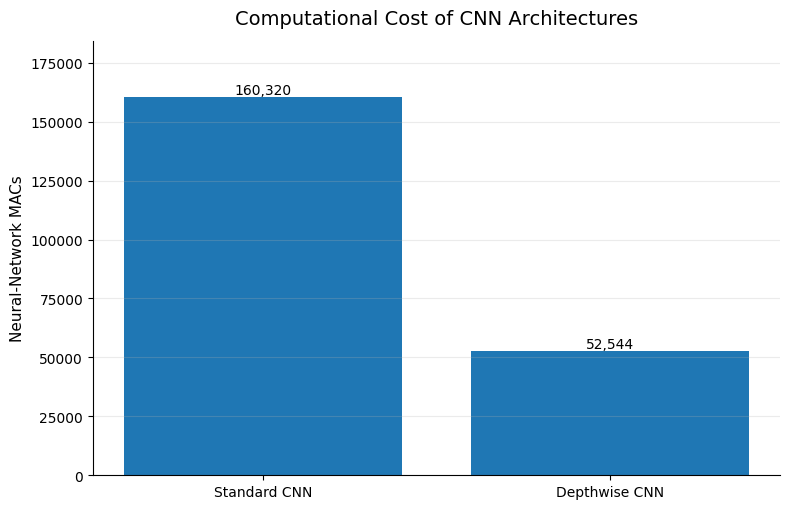


Saved final figure: Figure/study1_mac_count_comparison.png


In [36]:
# ============================================================
# STUDY 1 — NEURAL-NETWORK MAC COUNT COMPARISON
#
# Compare theoretical neural-network computation:
#
#   Standard CNN
#   Depthwise CNN
#
# Notes:
#   - MAC = Multiply-Accumulate operation
#   - Bias, activation, pooling, and softmax operations
#     are not included.
#   - Quantization does not change the number of MACs.
# ============================================================


# ============================================================
# CALCULATE MACs
# ============================================================

standard_cnn_macs = estimate_macs(
    standard_cnn_fp32
)


depthwise_cnn_macs = estimate_macs(
    depthwise_cnn_fp32
)


# ============================================================
# VALIDATION
# ============================================================

assert standard_cnn_macs == 160320, (
    f"Unexpected Standard CNN MAC count: "
    f"{standard_cnn_macs:,}"
)


assert depthwise_cnn_macs == 52544, (
    f"Unexpected Depthwise CNN MAC count: "
    f"{depthwise_cnn_macs:,}"
)


# ============================================================
# COMPUTE REDUCTIONS
# ============================================================

mac_reduction_percent = (
    100.0
    * (
        1.0
        - (
            depthwise_cnn_macs
            / standard_cnn_macs
        )
    )
)


parameter_reduction_percent = (
    100.0
    * (
        1.0
        - (
            depthwise_cnn_fp32.count_params()
            / standard_cnn_fp32.count_params()
        )
    )
)


# ============================================================
# STORE RESULTS
#
# FP32 and INT8 versions of the same architecture have
# identical parameter and MAC counts.
# ============================================================

standard_cnn_fp32_results[
    "macs"
] = int(
    standard_cnn_macs
)


standard_cnn_int8_results[
    "macs"
] = int(
    standard_cnn_macs
)


depthwise_cnn_fp32_results[
    "macs"
] = int(
    depthwise_cnn_macs
)


depthwise_cnn_int8_results[
    "macs"
] = int(
    depthwise_cnn_macs
)


# ============================================================
# CLEAN COMPARISON TABLE
# ============================================================

study1_mac_summary = pd.DataFrame({

    "Model": [
        "Standard CNN",
        "Depthwise CNN"
    ],

    "Parameters": [
        standard_cnn_fp32.count_params(),
        depthwise_cnn_fp32.count_params()
    ],

    "Neural-Network MACs": [
        standard_cnn_macs,
        depthwise_cnn_macs
    ]
})


display(
    study1_mac_summary.style
    .format({
        "Parameters": "{:,}",
        "Neural-Network MACs": "{:,}"
    })
    .hide(axis="index")
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\nDepthwise CNN parameter reduction vs Standard CNN:",
    f"{parameter_reduction_percent:.2f}%"
)


print(
    "Depthwise CNN MAC reduction vs Standard CNN:",
    f"{mac_reduction_percent:.2f}%"
)


# ============================================================
# FINAL STUDY 1 FIGURE
#
# This figure is publication / GitHub ready.
# ============================================================

os.makedirs(
    "Figure",
    exist_ok=True
)


figure_path = (
    "Figure/study1_mac_count_comparison.png"
)


fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)


bars = ax.bar(
    study1_mac_summary[
        "Model"
    ],
    study1_mac_summary[
        "Neural-Network MACs"
    ]
)


# ============================================================
# VALUE LABELS
# ============================================================

for bar in bars:

    value = int(
        bar.get_height()
    )

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )


# ============================================================
# FIGURE FORMATTING
# ============================================================

ax.set_title(
    "Computational Cost of CNN Architectures",
    fontsize=14,
    pad=12
)


ax.set_ylabel(
    "Neural-Network MACs",
    fontsize=11
)


ax.grid(
    axis="y",
    alpha=0.25
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.set_ylim(
    0,
    study1_mac_summary[
        "Neural-Network MACs"
    ].max()
    * 1.15
)


fig.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"\nSaved final figure: {figure_path}"
)

In [37]:
# ============================================================
# HOST TFLITE INFERENCE LATENCY BENCHMARK
#
# Measures ONLY TensorFlow Lite interpreter.invoke() time
# on the host machine.
#
# IMPORTANT:
#   - This is NOT Arduino latency.
#   - Input preprocessing / INT8 quantization is performed
#     BEFORE timing and is NOT included.
#   - num_threads=1 is used for a controlled comparison.
#
# Supports:
#   - FP32 TFLite models
#   - Full INT8 TFLite models
#   - Dense inputs: (features,)
#   - CNN inputs:   (128, 6)
# ============================================================


def benchmark_tflite_latency(
    model_content,
    sample,
    warmup_runs=20,
    benchmark_runs=200
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if not isinstance(
        model_content,
        (bytes, bytearray)
    ):

        raise TypeError(
            "model_content must contain TFLite model bytes."
        )


    if len(
        model_content
    ) == 0:

        raise ValueError(
            "model_content is empty."
        )


    if (
        not isinstance(
            warmup_runs,
            (int, np.integer)
        )
        or warmup_runs < 0
    ):

        raise ValueError(
            "warmup_runs must be a non-negative integer."
        )


    if (
        not isinstance(
            benchmark_runs,
            (int, np.integer)
        )
        or benchmark_runs <= 0
    ):

        raise ValueError(
            "benchmark_runs must be a positive integer."
        )


    # ========================================================
    # LOAD TFLITE MODEL
    # ========================================================

    interpreter = tf.lite.Interpreter(
        model_content=model_content,
        num_threads=1
    )


    interpreter.allocate_tensors()


    # ========================================================
    # INPUT INFORMATION
    # ========================================================

    input_details = (
        interpreter.get_input_details()[0]
    )


    input_index = int(
        input_details[
            "index"
        ]
    )


    input_dtype = (
        input_details[
            "dtype"
        ]
    )


    input_shape = tuple(
        int(x)
        for x in input_details[
            "shape"
        ]
    )


    expected_sample_shape = (
        input_shape[1:]
    )


    # ========================================================
    # PREPARE SAMPLE
    # ========================================================

    sample = np.asarray(
        sample,
        dtype=np.float32
    )


    if not np.isfinite(
        sample
    ).all():

        raise ValueError(
            "Sample contains NaN or infinite values."
        )


    if tuple(
        sample.shape
    ) != expected_sample_shape:

        raise ValueError(
            "Sample shape does not match "
            "TFLite model input shape.\n"
            f"Expected: {expected_sample_shape}\n"
            f"Received: {tuple(sample.shape)}"
        )


    # --------------------------------------------------------
    # Add batch dimension
    #
    # Dense:
    #   (features,) -> (1, features)
    #
    # CNN:
    #   (128, 6) -> (1, 128, 6)
    # --------------------------------------------------------

    sample = sample[
        np.newaxis,
        ...
    ]


    # ========================================================
    # PREPARE MODEL INPUT
    #
    # This happens BEFORE timing.
    # ========================================================

    if input_dtype == np.int8:

        (
            input_scale,
            input_zero_point
        ) = input_details[
            "quantization"
        ]


        if input_scale <= 0:

            raise ValueError(
                "Invalid INT8 input quantization scale."
            )


        input_data = np.round(
            sample / input_scale
            + input_zero_point
        )


        input_data = np.clip(
            input_data,
            -128,
            127
        ).astype(
            np.int8
        )


    else:

        input_data = sample.astype(
            input_dtype
        )


    # ========================================================
    # FINAL INPUT VALIDATION
    # ========================================================

    assert tuple(
        input_data.shape
    ) == input_shape


    interpreter.set_tensor(
        input_index,
        input_data
    )


    # ========================================================
    # WARM-UP
    #
    # Warm-up runs are not included in benchmark statistics.
    # ========================================================

    for _ in range(
        int(warmup_runs)
    ):

        interpreter.invoke()


    # ========================================================
    # BENCHMARK
    #
    # ONLY interpreter.invoke() is timed.
    # ========================================================

    times_ms = []


    for _ in range(
        int(benchmark_runs)
    ):

        start_ns = (
            time.perf_counter_ns()
        )


        interpreter.invoke()


        end_ns = (
            time.perf_counter_ns()
        )


        times_ms.append(
            (
                end_ns
                - start_ns
            )
            / 1_000_000.0
        )


    times_ms = np.asarray(
        times_ms,
        dtype=np.float64
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    assert len(
        times_ms
    ) == benchmark_runs


    assert np.isfinite(
        times_ms
    ).all()


    assert np.all(
        times_ms >= 0
    )


    # ========================================================
    # RETURN STATISTICS
    # ========================================================

    return {

        "mean_ms":
            float(
                np.mean(
                    times_ms
                )
            ),

        "median_ms":
            float(
                np.median(
                    times_ms
                )
            ),

        "std_ms":
            float(
                np.std(
                    times_ms
                )
            ),

        "min_ms":
            float(
                np.min(
                    times_ms
                )
            ),

        "max_ms":
            float(
                np.max(
                    times_ms
                )
            ),

        "p95_ms":
            float(
                np.percentile(
                    times_ms,
                    95
                )
            ),

        "runs":
            int(
                benchmark_runs
            ),

        "warmup_runs":
            int(
                warmup_runs
            ),

        "num_threads":
            1,

        "input_shape":
            input_shape,

        "input_dtype":
            input_dtype
    }

In [38]:
import time

In [39]:
# ============================================================
# STUDY 1 — HOST TFLITE INFERENCE LATENCY
#
# Controlled host-side comparison of:
#   - Standard CNN FP32
#   - Standard CNN INT8
#   - Depthwise CNN FP32
#   - Depthwise CNN INT8
#
# IMPORTANT:
#   - These measurements are HOST latency, not Arduino latency.
#   - Only interpreter.invoke() is timed.
#   - Input preprocessing / INT8 quantization is excluded.
#   - num_threads = 1 for a controlled comparison.
# ============================================================


# ============================================================
# BENCHMARK SAMPLE
#
# Use the same normalized raw-IMU test sample
# for all four CNN TFLite models.
# ============================================================

latency_sample = np.asarray(
    X_raw_test_scaled[0],
    dtype=np.float32
)


# ============================================================
# SAMPLE VALIDATION
# ============================================================

assert latency_sample.shape == (
    WINDOW_SIZE,
    NUM_CHANNELS
)

assert np.isfinite(
    latency_sample
).all()


# ============================================================
# TFLITE MODELS
# ============================================================

models_for_latency = {

    "Standard CNN FP32":
        standard_cnn_fp32_tflite,

    "Standard CNN INT8":
        standard_cnn_int8_tflite,

    "Depthwise CNN FP32":
        depthwise_cnn_fp32_tflite,

    "Depthwise CNN INT8":
        depthwise_cnn_int8_tflite
}


# ============================================================
# RUN BENCHMARK
# ============================================================

host_latency_results = {}


for model_name, model_content in models_for_latency.items():

    print(
        f"Benchmarking {model_name}..."
    )


    result = benchmark_tflite_latency(
        model_content=model_content,
        sample=latency_sample,
        warmup_runs=20,
        benchmark_runs=200
    )


    host_latency_results[
        model_name
    ] = result


# ============================================================
# VALIDATION
# ============================================================

assert set(
    host_latency_results.keys()
) == set(
    models_for_latency.keys()
)


for model_name, result in host_latency_results.items():

    assert result[
        "runs"
    ] == 200

    assert result[
        "warmup_runs"
    ] == 20

    assert result[
        "num_threads"
    ] == 1

    assert result[
        "mean_ms"
    ] >= 0

    assert result[
        "median_ms"
    ] >= 0

    assert result[
        "p95_ms"
    ] >= 0


# ============================================================
# STORE LATENCY IN MODEL RESULT DICTIONARIES
# ============================================================

standard_cnn_fp32_results.update({

    "host_mean_latency_ms":
        host_latency_results[
            "Standard CNN FP32"
        ][
            "mean_ms"
        ],

    "host_median_latency_ms":
        host_latency_results[
            "Standard CNN FP32"
        ][
            "median_ms"
        ]
})


standard_cnn_int8_results.update({

    "host_mean_latency_ms":
        host_latency_results[
            "Standard CNN INT8"
        ][
            "mean_ms"
        ],

    "host_median_latency_ms":
        host_latency_results[
            "Standard CNN INT8"
        ][
            "median_ms"
        ]
})


depthwise_cnn_fp32_results.update({

    "host_mean_latency_ms":
        host_latency_results[
            "Depthwise CNN FP32"
        ][
            "mean_ms"
        ],

    "host_median_latency_ms":
        host_latency_results[
            "Depthwise CNN FP32"
        ][
            "median_ms"
        ]
})


depthwise_cnn_int8_results.update({

    "host_mean_latency_ms":
        host_latency_results[
            "Depthwise CNN INT8"
        ][
            "mean_ms"
        ],

    "host_median_latency_ms":
        host_latency_results[
            "Depthwise CNN INT8"
        ][
            "median_ms"
        ]
})


# ============================================================
# CLEAN RESULTS TABLE
# ============================================================

host_latency_df = pd.DataFrame([

    {
        "Model":
            model_name,

        "Mean (ms)":
            result[
                "mean_ms"
            ],

        "Median (ms)":
            result[
                "median_ms"
            ],

        "Std (ms)":
            result[
                "std_ms"
            ],

        "Min (ms)":
            result[
                "min_ms"
            ],

        "Max (ms)":
            result[
                "max_ms"
            ],

        "P95 (ms)":
            result[
                "p95_ms"
            ]
    }

    for model_name, result
    in host_latency_results.items()
])


# ============================================================
# DISPLAY
# ============================================================

display(
    host_latency_df.style
    .format({
        "Mean (ms)": "{:.5f}",
        "Median (ms)": "{:.5f}",
        "Std (ms)": "{:.5f}",
        "Min (ms)": "{:.5f}",
        "Max (ms)": "{:.5f}",
        "P95 (ms)": "{:.5f}"
    })
    .hide(axis="index")
)


print(
    "\nHost TFLite inference latency benchmark completed."
)

print(
    "NOTE: These values are host-side diagnostics, "
    "not Arduino latency."
)

Benchmarking Standard CNN FP32...
Benchmarking Standard CNN INT8...
Benchmarking Depthwise CNN FP32...
Benchmarking Depthwise CNN INT8...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Model,Mean (ms),Median (ms),Std (ms),Min (ms),Max (ms),P95 (ms)
Standard CNN FP32,0.01446,0.01497,0.00525,0.00974,0.05652,0.02001
Standard CNN INT8,0.01419,0.01327,0.00427,0.01315,0.04126,0.01966
Depthwise CNN FP32,0.00849,0.00827,0.00156,0.00812,0.02488,0.00849
Depthwise CNN INT8,0.01284,0.01118,0.01066,0.01104,0.13312,0.01252



Host TFLite inference latency benchmark completed.
NOTE: These values are host-side diagnostics, not Arduino latency.


In [40]:
# ============================================================
# STUDY 1 — OFFLINE & HOST BENCHMARK SUMMARY
#
# Comparison of:
#   - Standard CNN FP32
#   - Standard CNN INT8
#   - Depthwise CNN FP32
#   - Depthwise CNN INT8
#
# IMPORTANT:
#   - Accuracy is measured on the fixed 32-window test set.
#   - Host latency measures ONLY TFLite interpreter.invoke().
#   - Host latency is NOT Arduino latency.
#   - Neural-network MACs exclude preprocessing and
#     feature-extraction costs.
# ============================================================


# ============================================================
# BUILD BENCHMARK TABLE
# ============================================================

study1_benchmark_results = [

    # --------------------------------------------------------
    # STANDARD CNN FP32
    # --------------------------------------------------------

    {
        "Model":
            "Standard CNN FP32",

        "Architecture":
            "Standard CNN",

        "Precision":
            "FP32",

        "Parameters":
            int(
                standard_cnn_fp32_results[
                    "parameters"
                ]
            ),

        "Neural-Network MACs":
            int(
                standard_cnn_fp32_results[
                    "macs"
                ]
            ),

        "TFLite Size (KB)":
            float(
                standard_cnn_fp32_results[
                    "tflite_size_kb"
                ]
            ),

        "Test Accuracy (%)":
            100.0
            * float(
                standard_cnn_fp32_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                standard_cnn_fp32_results[
                    "macro_f1"
                ]
            ),

        "Host Mean Latency (ms)":
            float(
                standard_cnn_fp32_results[
                    "host_mean_latency_ms"
                ]
            ),

        "Host Median Latency (ms)":
            float(
                standard_cnn_fp32_results[
                    "host_median_latency_ms"
                ]
            ),

        "Host P95 Latency (ms)":
            float(
                host_latency_results[
                    "Standard CNN FP32"
                ][
                    "p95_ms"
                ]
            )
    },


    # --------------------------------------------------------
    # STANDARD CNN INT8
    # --------------------------------------------------------

    {
        "Model":
            "Standard CNN INT8",

        "Architecture":
            "Standard CNN",

        "Precision":
            "INT8",

        "Parameters":
            int(
                standard_cnn_int8_results[
                    "parameters"
                ]
            ),

        "Neural-Network MACs":
            int(
                standard_cnn_int8_results[
                    "macs"
                ]
            ),

        "TFLite Size (KB)":
            float(
                standard_cnn_int8_results[
                    "tflite_size_kb"
                ]
            ),

        "Test Accuracy (%)":
            100.0
            * float(
                standard_cnn_int8_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                standard_cnn_int8_results[
                    "macro_f1"
                ]
            ),

        "Host Mean Latency (ms)":
            float(
                standard_cnn_int8_results[
                    "host_mean_latency_ms"
                ]
            ),

        "Host Median Latency (ms)":
            float(
                standard_cnn_int8_results[
                    "host_median_latency_ms"
                ]
            ),

        "Host P95 Latency (ms)":
            float(
                host_latency_results[
                    "Standard CNN INT8"
                ][
                    "p95_ms"
                ]
            )
    },


    # --------------------------------------------------------
    # DEPTHWISE CNN FP32
    # --------------------------------------------------------

    {
        "Model":
            "Depthwise CNN FP32",

        "Architecture":
            "Depthwise CNN",

        "Precision":
            "FP32",

        "Parameters":
            int(
                depthwise_cnn_fp32_results[
                    "parameters"
                ]
            ),

        "Neural-Network MACs":
            int(
                depthwise_cnn_fp32_results[
                    "macs"
                ]
            ),

        "TFLite Size (KB)":
            float(
                depthwise_cnn_fp32_results[
                    "tflite_size_kb"
                ]
            ),

        "Test Accuracy (%)":
            100.0
            * float(
                depthwise_cnn_fp32_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                depthwise_cnn_fp32_results[
                    "macro_f1"
                ]
            ),

        "Host Mean Latency (ms)":
            float(
                depthwise_cnn_fp32_results[
                    "host_mean_latency_ms"
                ]
            ),

        "Host Median Latency (ms)":
            float(
                depthwise_cnn_fp32_results[
                    "host_median_latency_ms"
                ]
            ),

        "Host P95 Latency (ms)":
            float(
                host_latency_results[
                    "Depthwise CNN FP32"
                ][
                    "p95_ms"
                ]
            )
    },


    # --------------------------------------------------------
    # DEPTHWISE CNN INT8
    # --------------------------------------------------------

    {
        "Model":
            "Depthwise CNN INT8",

        "Architecture":
            "Depthwise CNN",

        "Precision":
            "INT8",

        "Parameters":
            int(
                depthwise_cnn_int8_results[
                    "parameters"
                ]
            ),

        "Neural-Network MACs":
            int(
                depthwise_cnn_int8_results[
                    "macs"
                ]
            ),

        "TFLite Size (KB)":
            float(
                depthwise_cnn_int8_results[
                    "tflite_size_kb"
                ]
            ),

        "Test Accuracy (%)":
            100.0
            * float(
                depthwise_cnn_int8_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                depthwise_cnn_int8_results[
                    "macro_f1"
                ]
            ),

        "Host Mean Latency (ms)":
            float(
                depthwise_cnn_int8_results[
                    "host_mean_latency_ms"
                ]
            ),

        "Host Median Latency (ms)":
            float(
                depthwise_cnn_int8_results[
                    "host_median_latency_ms"
                ]
            ),

        "Host P95 Latency (ms)":
            float(
                host_latency_results[
                    "Depthwise CNN INT8"
                ][
                    "p95_ms"
                ]
            )
    }
]


# ============================================================
# CREATE DATAFRAME
# ============================================================

study1_benchmark_df = pd.DataFrame(
    study1_benchmark_results
)


# ============================================================
# VALIDATION
# ============================================================

assert len(
    study1_benchmark_df
) == 4


assert study1_benchmark_df[
    "Model"
].is_unique


assert np.isfinite(
    study1_benchmark_df[
        [
            "Parameters",
            "Neural-Network MACs",
            "TFLite Size (KB)",
            "Test Accuracy (%)",
            "Macro F1",
            "Host Mean Latency (ms)",
            "Host Median Latency (ms)",
            "Host P95 Latency (ms)"
        ]
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# CLEAN DISPLAY
# ============================================================

display(
    study1_benchmark_df.style
    .format({
        "Parameters": "{:,}",
        "Neural-Network MACs": "{:,}",
        "TFLite Size (KB)": "{:.3f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Host Mean Latency (ms)": "{:.5f}",
        "Host Median Latency (ms)": "{:.5f}",
        "Host P95 Latency (ms)": "{:.5f}"
    })
    .hide(axis="index")
)


print(
    "\nStudy 1 offline and host benchmark summary completed."
)

print(
    "NOTE: Host latency is diagnostic only; "
    "Arduino latency is evaluated separately."
)

Model,Architecture,Precision,Parameters,Neural-Network MACs,TFLite Size (KB),Test Accuracy (%),Macro F1,Host Mean Latency (ms),Host Median Latency (ms),Host P95 Latency (ms)
Standard CNN FP32,Standard CNN,FP32,"2,660","160,320",15.070,100.000,1.0000,0.01446,0.01497,0.02001
Standard CNN INT8,Standard CNN,INT8,"2,660","160,320",9.750,100.000,1.0000,0.01419,0.01327,0.01966
Depthwise CNN FP32,Depthwise CNN,FP32,"1,330","52,544",10.781,100.000,1.0000,0.00849,0.00827,0.00849
Depthwise CNN INT8,Depthwise CNN,INT8,"1,330","52,544",10.086,100.000,1.0000,0.01284,0.01118,0.01252



Study 1 offline and host benchmark summary completed.
NOTE: Host latency is diagnostic only; Arduino latency is evaluated separately.


In [41]:
# ============================================================
# SAVE STUDY 1 OFFLINE / HOST BENCHMARK RESULTS
#
# Output:
#   Results/study1_offline_host_benchmark.csv
# ============================================================


# ============================================================
# VALIDATE RESULT TABLE
# ============================================================

assert isinstance(
    study1_benchmark_df,
    pd.DataFrame
)


assert len(
    study1_benchmark_df
) == 4


assert not study1_benchmark_df.empty


assert study1_benchmark_df[
    "Model"
].is_unique


# ============================================================
# CREATE RESULTS DIRECTORY
# ============================================================

os.makedirs(
    "Results",
    exist_ok=True
)


# ============================================================
# OUTPUT PATH
# ============================================================

study1_benchmark_csv = (
    "Results/study1_offline_host_benchmark.csv"
)


# ============================================================
# SAVE CSV
# ============================================================

study1_benchmark_df.to_csv(
    study1_benchmark_csv,
    index=False
)


# ============================================================
# VERIFY FILE
# ============================================================

assert os.path.exists(
    study1_benchmark_csv
)


assert os.path.getsize(
    study1_benchmark_csv
) > 0


# ============================================================
# SUMMARY
# ============================================================

print(
    f"Saved: {study1_benchmark_csv}"
)

print(
    "Rows:",
    len(
        study1_benchmark_df
    )
)

print(
    "Study 1 benchmark CSV saved successfully."
)

Saved: Results/study1_offline_host_benchmark.csv
Rows: 4
Study 1 benchmark CSV saved successfully.


In [42]:
# ============================================================
# DATA LEAKAGE CHECK — EXACT DUPLICATES ACROSS SPLITS
#
# Verify that no EXACTLY IDENTICAL raw IMU window appears
# in more than one of the Train / Validation / Test subsets.
#
# IMPORTANT:
#   - This check uses raw data BEFORE normalization.
#   - It detects exact duplicate windows only.
#   - It does NOT detect near-duplicates, temporal similarity,
#     recording-session dependence, or subject-level leakage.
# ============================================================


# ============================================================
# WINDOW -> BYTE KEY
# ============================================================

def window_key(
    window
):

    window = np.ascontiguousarray(
        window,
        dtype=np.float32
    )


    assert window.shape == (
        WINDOW_SIZE,
        NUM_CHANNELS
    )


    return window.tobytes()


# ============================================================
# CREATE UNIQUE WINDOW KEYS
# ============================================================

train_keys = {
    window_key(window)
    for window in X_raw_train
}


val_keys = {
    window_key(window)
    for window in X_raw_val
}


test_keys = {
    window_key(window)
    for window in X_raw_test
}


# ============================================================
# WITHIN-SPLIT UNIQUE COUNTS
#
# These checks also confirm that no exact duplicate window
# exists within an individual split.
# ============================================================

train_unique = len(
    train_keys
)

val_unique = len(
    val_keys
)

test_unique = len(
    test_keys
)


# ============================================================
# CHECK CROSS-SPLIT OVERLAP
# ============================================================

train_val_overlap = len(
    train_keys
    & val_keys
)


train_test_overlap = len(
    train_keys
    & test_keys
)


val_test_overlap = len(
    val_keys
    & test_keys
)


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

duplicate_check_df = pd.DataFrame({

    "Split Pair": [
        "Train ↔ Validation",
        "Train ↔ Test",
        "Validation ↔ Test"
    ],

    "Exact Duplicate Windows": [
        train_val_overlap,
        train_test_overlap,
        val_test_overlap
    ]
})


display(
    duplicate_check_df.style
    .hide(axis="index")
)


# ============================================================
# UNIQUE-WINDOW SUMMARY
# ============================================================

duplicate_unique_summary_df = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Total Windows": [
        len(X_raw_train),
        len(X_raw_val),
        len(X_raw_test)
    ],

    "Unique Windows": [
        train_unique,
        val_unique,
        test_unique
    ],

    "Within-Split Exact Duplicates": [
        len(X_raw_train)
        - train_unique,

        len(X_raw_val)
        - val_unique,

        len(X_raw_test)
        - test_unique
    ]
})


display(
    duplicate_unique_summary_df.style
    .hide(axis="index")
)


# ============================================================
# VALIDATION
# ============================================================

assert train_val_overlap == 0, (
    "Exact-window overlap detected "
    "between Train and Validation."
)


assert train_test_overlap == 0, (
    "Exact-window overlap detected "
    "between Train and Test."
)


assert val_test_overlap == 0, (
    "Exact-window overlap detected "
    "between Validation and Test."
)


assert train_unique == len(
    X_raw_train
), (
    "Exact duplicate windows detected "
    "inside the training split."
)


assert val_unique == len(
    X_raw_val
), (
    "Exact duplicate windows detected "
    "inside the validation split."
)


assert test_unique == len(
    X_raw_test
), (
    "Exact duplicate windows detected "
    "inside the test split."
)


print(
    "\nExact-duplicate leakage check passed."
)

print(
    "No identical raw IMU windows were found "
    "within or across the dataset splits."
)

print(
    "NOTE: This does not rule out near-duplicates "
    "or temporal correlation."
)

Split Pair,Exact Duplicate Windows
Train ↔ Validation,0
Train ↔ Test,0
Validation ↔ Test,0


Split,Total Windows,Unique Windows,Within-Split Exact Duplicates
Train,256,256,0
Validation,32,32,0
Test,32,32,0



Exact-duplicate leakage check passed.
No identical raw IMU windows were found within or across the dataset splits.
NOTE: This does not rule out near-duplicates or temporal correlation.


In [43]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    pairwise_distances
)

In [44]:
# ============================================================
# TRAIN–TEST SIMILARITY & 1-NN RAW-SIGNAL SANITY CHECK
#
# For every test window:
#   1. Find the nearest training window using Euclidean
#      distance in normalized raw-signal space.
#   2. Inspect nearest-neighbor distances.
#   3. Use the nearest training label as a simple 1-NN
#      baseline prediction.
#
# IMPORTANT:
#   - This is a similarity / robustness diagnostic.
#   - It is NOT a definitive data-leakage test.
#   - Exact duplicates were checked separately.
# ============================================================


# ============================================================
# FLATTEN NORMALIZED RAW WINDOWS
# ============================================================

train_flat = X_raw_train_scaled.reshape(
    len(X_raw_train_scaled),
    WINDOW_SIZE * NUM_CHANNELS
)


test_flat = X_raw_test_scaled.reshape(
    len(X_raw_test_scaled),
    WINDOW_SIZE * NUM_CHANNELS
)


# ============================================================
# VALIDATION
# ============================================================

assert train_flat.shape == (
    len(train_idx),
    WINDOW_SIZE * NUM_CHANNELS
)


assert test_flat.shape == (
    len(test_idx),
    WINDOW_SIZE * NUM_CHANNELS
)


assert np.isfinite(
    train_flat
).all()


assert np.isfinite(
    test_flat
).all()


# ============================================================
# TEST → TRAIN PAIRWISE DISTANCES
# ============================================================

train_test_distances = pairwise_distances(
    test_flat,
    train_flat,
    metric="euclidean"
)


assert train_test_distances.shape == (
    len(test_idx),
    len(train_idx)
)


assert np.isfinite(
    train_test_distances
).all()


# ============================================================
# NEAREST TRAIN WINDOW FOR EACH TEST WINDOW
# ============================================================

nearest_train_idx = np.argmin(
    train_test_distances,
    axis=1
)


nearest_distances = np.min(
    train_test_distances,
    axis=1
)


nearest_train_labels = y_raw_train[
    nearest_train_idx
].astype(
    np.int32
)


# ============================================================
# SAFETY CHECK
#
# Exact duplicates should already have been ruled out.
# ============================================================

assert np.all(
    nearest_distances > 0
), (
    "At least one test window is identical "
    "to a training window."
)


# ============================================================
# SIMILARITY SUMMARY
# ============================================================

nearest_label_agreement = float(
    accuracy_score(
        y_raw_test,
        nearest_train_labels
    )
)


similarity_summary_df = pd.DataFrame({

    "Metric": [
        "Nearest-label agreement (%)",
        "Minimum nearest distance",
        "Median nearest distance",
        "Mean nearest distance",
        "Maximum nearest distance"
    ],

    "Value": [
        100.0 * nearest_label_agreement,
        float(
            np.min(
                nearest_distances
            )
        ),
        float(
            np.median(
                nearest_distances
            )
        ),
        float(
            np.mean(
                nearest_distances
            )
        ),
        float(
            np.max(
                nearest_distances
            )
        )
    ]
})


display(
    similarity_summary_df.style
    .format({
        "Value": "{:.6f}"
    })
    .hide(axis="index")
)


# ============================================================
# 1-NN RAW-SIGNAL BASELINE
#
# The nearest training label becomes the prediction.
# No separate KNeighborsClassifier is required.
# ============================================================

knn_pred = nearest_train_labels


knn_accuracy = float(
    accuracy_score(
        y_raw_test,
        knn_pred
    )
)


knn_macro_f1 = float(
    f1_score(
        y_raw_test,
        knn_pred,
        average="macro",
        zero_division=0
    )
)


knn_confusion_matrix = confusion_matrix(
    y_raw_test,
    knn_pred,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


# ============================================================
# 1-NN SUMMARY
# ============================================================

knn_summary_df = pd.DataFrame([{

    "Model":
        "1-NN Raw Signal",

    "Test Accuracy (%)":
        100.0
        * knn_accuracy,

    "Macro F1":
        knn_macro_f1
}])


display(
    knn_summary_df.style
    .format({
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}"
    })
    .hide(axis="index")
)


# ============================================================
# 1-NN CLASSIFICATION REPORT
# ============================================================

knn_report_df = pd.DataFrame(
    classification_report(
        y_raw_test,
        knn_pred,
        labels=np.arange(
            len(CLASS_NAMES)
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).T


knn_report_display_df = (
    knn_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    knn_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# 1-NN CONFUSION MATRIX TABLE
# ============================================================

knn_cm_df = pd.DataFrame(
    knn_confusion_matrix,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


knn_cm_df.index.name = "True Class"
knn_cm_df.columns.name = "Predicted Class"


display(
    knn_cm_df
)


print(
    "\nTrain–test similarity and 1-NN "
    "raw-signal sanity check completed."
)

print(
    "NOTE: High nearest-neighbor agreement alone "
    "does not prove data leakage."
)

Metric,Value
Nearest-label agreement (%),100.000000
Minimum nearest distance,0.069244
Median nearest distance,12.500757
Mean nearest distance,10.414181
Maximum nearest distance,21.235821


Model,Test Accuracy (%),Macro F1
1-NN Raw Signal,100.000,1.0000


,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,8
left_right,1.0000,1.0000,1.0000,8
rest,1.0000,1.0000,1.0000,8
up_down,1.0000,1.0000,1.0000,8
macro avg,1.0000,1.0000,1.0000,32
weighted avg,1.0000,1.0000,1.0000,32


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,8,0,0,0
left_right,0,8,0,0
rest,0,0,8,0
up_down,0,0,0,8



Train–test similarity and 1-NN raw-signal sanity check completed.
NOTE: High nearest-neighbor agreement alone does not prove data leakage.


In [45]:
# ============================================================
# TEMPORAL STRUCTURE DIAGNOSTIC
# Adjacent vs Random Same-Class Windows
#
# Purpose:
#   Compare distances between consecutive same-class windows
#   with distances between randomly selected non-adjacent
#   same-class windows.
#
# IMPORTANT:
#   - This is a temporal-dependence diagnostic.
#   - It is NOT proof of data leakage.
#   - Interpretation as "temporal" assumes that the original
#     window order in each CSV reflects recording order.
#   - Normalization uses ONLY the main training statistics.
# ============================================================


RANDOM_PAIRS_PER_CLASS = 200

rng = np.random.default_rng(
    SEED
)


temporal_results = []

all_neighbor_distances = []
all_random_distances = []


# ============================================================
# ANALYZE EACH CLASS
# ============================================================

for label in CLASS_NAMES:

    windows = np.asarray(
        all_data[label],
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    assert windows.ndim == 3

    assert windows.shape[1:] == (
        WINDOW_SIZE,
        NUM_CHANNELS
    )

    assert len(windows) >= 3

    assert np.isfinite(
        windows
    ).all()


    # --------------------------------------------------------
    # Normalize using MAIN TRAIN-ONLY statistics
    # --------------------------------------------------------

    windows_scaled = (
        (
            windows
            - raw_mean
        )
        / raw_std
    ).astype(
        np.float32
    )


    windows_flat = windows_scaled.reshape(
        len(windows_scaled),
        WINDOW_SIZE * NUM_CHANNELS
    )


    # ========================================================
    # ADJACENT-WINDOW DISTANCES
    #
    # (0,1), (1,2), (2,3), ...
    # ========================================================

    neighbor_distances = np.linalg.norm(
        windows_flat[1:]
        - windows_flat[:-1],
        axis=1
    ).astype(
        np.float64
    )


    # ========================================================
    # ALL VALID NON-ADJACENT SAME-CLASS PAIRS
    #
    # Exclude:
    #   - identical index
    #   - directly adjacent windows
    # ========================================================

    valid_pairs = [
        (i, j)

        for i in range(
            len(windows_flat)
        )

        for j in range(
            i + 1,
            len(windows_flat)
        )

        if (
            j - i
        ) > 1
    ]


    assert len(
        valid_pairs
    ) > 0


    # --------------------------------------------------------
    # Select unique random pairs
    # --------------------------------------------------------

    sample_count = min(
        RANDOM_PAIRS_PER_CLASS,
        len(valid_pairs)
    )


    selected_pair_indices = rng.choice(
        len(valid_pairs),
        size=sample_count,
        replace=False
    )


    selected_pairs = [
        valid_pairs[idx]
        for idx in selected_pair_indices
    ]


    # ========================================================
    # RANDOM NON-ADJACENT DISTANCES
    # ========================================================

    random_distances = np.asarray(
        [

            np.linalg.norm(
                windows_flat[i]
                - windows_flat[j]
            )

            for i, j in selected_pairs
        ],
        dtype=np.float64
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    assert len(
        neighbor_distances
    ) == (
        len(windows)
        - 1
    )


    assert len(
        random_distances
    ) == sample_count


    assert np.isfinite(
        neighbor_distances
    ).all()


    assert np.isfinite(
        random_distances
    ).all()


    # ========================================================
    # CLASS-LEVEL STATISTICS
    # ========================================================

    neighbor_median = float(
        np.median(
            neighbor_distances
        )
    )


    random_median = float(
        np.median(
            random_distances
        )
    )


    median_ratio = (
        neighbor_median
        / random_median
        if random_median > 0
        else np.nan
    )


    temporal_results.append({

        "Class":
            label,

        "Windows":
            len(windows),

        "Adjacent Pairs":
            len(
                neighbor_distances
            ),

        "Random Pairs":
            len(
                random_distances
            ),

        "Adjacent Median":
            neighbor_median,

        "Random Median":
            random_median,

        "Median Ratio":
            float(
                median_ratio
            ),

        "Adjacent Mean":
            float(
                np.mean(
                    neighbor_distances
                )
            ),

        "Random Mean":
            float(
                np.mean(
                    random_distances
                )
            )
    })


    all_neighbor_distances.extend(
        neighbor_distances.tolist()
    )


    all_random_distances.extend(
        random_distances.tolist()
    )


# ============================================================
# CREATE CLASS-LEVEL RESULTS TABLE
# ============================================================

temporal_structure_df = pd.DataFrame(
    temporal_results
)


display(
    temporal_structure_df.style
    .format({
        "Windows": "{:,}",
        "Adjacent Pairs": "{:,}",
        "Random Pairs": "{:,}",
        "Adjacent Median": "{:.4f}",
        "Random Median": "{:.4f}",
        "Median Ratio": "{:.4f}",
        "Adjacent Mean": "{:.4f}",
        "Random Mean": "{:.4f}"
    })
    .hide(axis="index")
)


# ============================================================
# OVERALL SUMMARY
# ============================================================

all_neighbor_distances = np.asarray(
    all_neighbor_distances,
    dtype=np.float64
)


all_random_distances = np.asarray(
    all_random_distances,
    dtype=np.float64
)


overall_neighbor_median = float(
    np.median(
        all_neighbor_distances
    )
)


overall_random_median = float(
    np.median(
        all_random_distances
    )
)


overall_temporal_ratio = (
    overall_neighbor_median
    / overall_random_median
)


# ============================================================
# CLEAN OVERALL TABLE
# ============================================================

temporal_overall_df = pd.DataFrame([{

    "Adjacent Median Distance":
        overall_neighbor_median,

    "Random Median Distance":
        overall_random_median,

    "Adjacent / Random Ratio":
        overall_temporal_ratio
}])


display(
    temporal_overall_df.style
    .format({
        "Adjacent Median Distance": "{:.4f}",
        "Random Median Distance": "{:.4f}",
        "Adjacent / Random Ratio": "{:.4f}"
    })
    .hide(axis="index")
)


print(
    "\nTemporal structure diagnostic completed."
)

print(
    "Interpretation:"
)

print(
    "  Ratio < 1  → adjacent windows tend to be more similar."
)

print(
    "  Ratio ≈ 1  → adjacent windows are not especially "
    "more similar than random same-class windows."
)

print(
    "\nNOTE: This diagnostic assumes the original CSV window "
    "order reflects recording order."
)

Class,Windows,Adjacent Pairs,Random Pairs,Adjacent Median,Random Median,Median Ratio,Adjacent Mean,Random Mean
circle,80,79,200,43.1123,43.8364,0.9835,43.8739,42.2380
left_right,80,79,200,18.1546,16.5554,1.0966,18.5498,16.5046
rest,80,79,200,0.1351,0.1401,0.9647,0.1549,0.1497
up_down,80,79,200,43.1665,43.8710,0.9839,40.0881,40.4591


Adjacent Median Distance,Random Median Distance,Adjacent / Random Ratio
24.0753,21.1188,1.1400



Temporal structure diagnostic completed.
Interpretation:
  Ratio < 1  → adjacent windows tend to be more similar.
  Ratio ≈ 1  → adjacent windows are not especially more similar than random same-class windows.

NOTE: This diagnostic assumes the original CSV window order reflects recording order.


In [46]:
# ============================================================
# SUPPLEMENTARY ROBUSTNESS CHECK — BLOCKED SPLIT
#
# 60% Train | 20% Validation | 20% Test
#
# Within each class:
#
#   first 60%  -> Train
#   next 20%   -> Validation
#   final 20%  -> Test
#
# IMPORTANT:
#   - This is a supplementary robustness experiment.
#   - It does NOT replace the main random 80/10/10 split.
#   - Interpretation as a temporal split assumes that the
#     original CSV window order reflects recording order.
#   - Compared with the main split, this experiment also uses
#     fewer training samples (60% vs 80%). Therefore any
#     performance difference cannot be attributed solely
#     to temporal blocking.
# ============================================================


# ============================================================
# BLOCKED SPLIT CONFIGURATION
# ============================================================

BLOCK_TRAIN_RATIO = 0.60
BLOCK_VAL_RATIO = 0.20
BLOCK_TEST_RATIO = 0.20


assert np.isclose(
    BLOCK_TRAIN_RATIO
    + BLOCK_VAL_RATIO
    + BLOCK_TEST_RATIO,
    1.0
)


# ============================================================
# STORAGE
# ============================================================

X_block_train_parts = []
X_block_val_parts = []
X_block_test_parts = []

y_block_train_parts = []
y_block_val_parts = []
y_block_test_parts = []


# ============================================================
# CREATE CONTIGUOUS SPLITS WITHIN EACH CLASS
# ============================================================

for class_idx, label in enumerate(
    CLASS_NAMES
):

    windows = np.asarray(
        all_data[label],
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    assert windows.ndim == 3

    assert windows.shape[1:] == (
        WINDOW_SIZE,
        NUM_CHANNELS
    )

    assert np.isfinite(
        windows
    ).all()


    n_windows = len(
        windows
    )


    # --------------------------------------------------------
    # Split boundaries
    # --------------------------------------------------------

    train_end = int(
        BLOCK_TRAIN_RATIO
        * n_windows
    )


    val_end = int(
        (
            BLOCK_TRAIN_RATIO
            + BLOCK_VAL_RATIO
        )
        * n_windows
    )


    # --------------------------------------------------------
    # Contiguous subsets
    # --------------------------------------------------------

    train_windows = windows[
        :train_end
    ]

    val_windows = windows[
        train_end:val_end
    ]

    test_windows = windows[
        val_end:
    ]


    # --------------------------------------------------------
    # Store X
    # --------------------------------------------------------

    X_block_train_parts.append(
        train_windows
    )

    X_block_val_parts.append(
        val_windows
    )

    X_block_test_parts.append(
        test_windows
    )


    # --------------------------------------------------------
    # Store y
    # --------------------------------------------------------

    y_block_train_parts.append(
        np.full(
            len(train_windows),
            class_idx,
            dtype=np.int32
        )
    )


    y_block_val_parts.append(
        np.full(
            len(val_windows),
            class_idx,
            dtype=np.int32
        )
    )


    y_block_test_parts.append(
        np.full(
            len(test_windows),
            class_idx,
            dtype=np.int32
        )
    )


# ============================================================
# CONCATENATE CLASSES
# ============================================================

X_block_train = np.concatenate(
    X_block_train_parts,
    axis=0
).astype(
    np.float32
)


X_block_val = np.concatenate(
    X_block_val_parts,
    axis=0
).astype(
    np.float32
)


X_block_test = np.concatenate(
    X_block_test_parts,
    axis=0
).astype(
    np.float32
)


y_block_train = np.concatenate(
    y_block_train_parts
).astype(
    np.int32
)


y_block_val = np.concatenate(
    y_block_val_parts
).astype(
    np.int32
)


y_block_test = np.concatenate(
    y_block_test_parts
).astype(
    np.int32
)


# ============================================================
# EXPECTED SIZES
#
# Current dataset:
#   80 windows per class
#
# Per class:
#   Train = 48
#   Val   = 16
#   Test  = 16
#
# Overall:
#   Train = 192
#   Val   = 64
#   Test  = 64
# ============================================================

expected_block_train = sum(
    int(
        BLOCK_TRAIN_RATIO
        * len(all_data[label])
    )
    for label in CLASS_NAMES
)


expected_block_val = sum(
    int(
        (
            BLOCK_TRAIN_RATIO
            + BLOCK_VAL_RATIO
        )
        * len(all_data[label])
    )
    - int(
        BLOCK_TRAIN_RATIO
        * len(all_data[label])
    )
    for label in CLASS_NAMES
)


expected_block_test = (
    len(X_raw)
    - expected_block_train
    - expected_block_val
)


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert X_block_train.shape == (
    expected_block_train,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_block_val.shape == (
    expected_block_val,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_block_test.shape == (
    expected_block_test,
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert y_block_train.shape == (
    expected_block_train,
)


assert y_block_val.shape == (
    expected_block_val,
)


assert y_block_test.shape == (
    expected_block_test,
)


# ============================================================
# NUMERICAL VALIDATION
# ============================================================

assert np.isfinite(
    X_block_train
).all()

assert np.isfinite(
    X_block_val
).all()

assert np.isfinite(
    X_block_test
).all()


# ============================================================
# FULL DATASET COVERAGE
# ============================================================

total_blocked = (
    len(y_block_train)
    + len(y_block_val)
    + len(y_block_test)
)


assert total_blocked == len(
    X_raw
)


# ============================================================
# SPLIT SUMMARY
# ============================================================

blocked_split_summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Windows": [
        len(y_block_train),
        len(y_block_val),
        len(y_block_test)
    ],

    "Percentage": [
        100.0
        * len(y_block_train)
        / total_blocked,

        100.0
        * len(y_block_val)
        / total_blocked,

        100.0
        * len(y_block_test)
        / total_blocked
    ]
})


display(
    blocked_split_summary.style
    .format({
        "Windows": "{:,}",
        "Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

blocked_class_distribution = pd.DataFrame({

    "Class":
        CLASS_NAMES,

    "Train":
        np.bincount(
            y_block_train,
            minlength=len(CLASS_NAMES)
        ),

    "Validation":
        np.bincount(
            y_block_val,
            minlength=len(CLASS_NAMES)
        ),

    "Test":
        np.bincount(
            y_block_test,
            minlength=len(CLASS_NAMES)
        )
})


# ============================================================
# CLASS-BALANCE VALIDATION
# ============================================================

assert np.all(
    blocked_class_distribution[
        "Train"
    ].to_numpy()
    == 48
)


assert np.all(
    blocked_class_distribution[
        "Validation"
    ].to_numpy()
    == 16
)


assert np.all(
    blocked_class_distribution[
        "Test"
    ].to_numpy()
    == 16
)


display(
    blocked_class_distribution.style
    .hide(axis="index")
)


print(
    "\nBlocked 60/20/20 split created successfully."
)

print(
    "NOTE: This is a supplementary robustness split, "
    "not a replacement for the main 80/10/10 split."
)

Split,Windows,Percentage
Train,192,60.0%
Validation,64,20.0%
Test,64,20.0%


Class,Train,Validation,Test
circle,48,16,16
left_right,48,16,16
rest,48,16,16
up_down,48,16,16



Blocked 60/20/20 split created successfully.
NOTE: This is a supplementary robustness split, not a replacement for the main 80/10/10 split.


In [47]:
# ============================================================
# BLOCKED SPLIT — TRAIN-ONLY RAW NORMALIZATION
#
# Normalization statistics are estimated ONLY from the
# blocked training subset and then applied unchanged to
# blocked validation and test data.
#
# IMPORTANT:
#   These statistics belong ONLY to the supplementary
#   blocked robustness experiment.
#
#   They are NOT used for final Arduino deployment.
# ============================================================


# ============================================================
# BLOCKED TRAINING STATISTICS
# ============================================================

block_mean = np.asarray(
    X_block_train.mean(
        axis=(0, 1),
        keepdims=True
    ),
    dtype=np.float32
)


block_std = np.asarray(
    X_block_train.std(
        axis=(0, 1),
        keepdims=True
    ),
    dtype=np.float32
)


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert block_mean.shape == (
    1,
    1,
    NUM_CHANNELS
)


assert block_std.shape == (
    1,
    1,
    NUM_CHANNELS
)


# ============================================================
# NUMERICAL SAFETY
# ============================================================

block_std = np.where(
    block_std < 1e-8,
    1.0,
    block_std
).astype(
    np.float32
)


assert np.isfinite(
    block_mean
).all()


assert np.isfinite(
    block_std
).all()


assert np.all(
    block_std > 0
)


# ============================================================
# APPLY BLOCKED TRAIN-ONLY NORMALIZATION
# ============================================================

X_block_train_scaled = (
    (
        X_block_train
        - block_mean
    )
    / block_std
).astype(
    np.float32
)


X_block_val_scaled = (
    (
        X_block_val
        - block_mean
    )
    / block_std
).astype(
    np.float32
)


X_block_test_scaled = (
    (
        X_block_test
        - block_mean
    )
    / block_std
).astype(
    np.float32
)


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert X_block_train_scaled.shape == (
    len(y_block_train),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_block_val_scaled.shape == (
    len(y_block_val),
    WINDOW_SIZE,
    NUM_CHANNELS
)


assert X_block_test_scaled.shape == (
    len(y_block_test),
    WINDOW_SIZE,
    NUM_CHANNELS
)


# ============================================================
# NUMERICAL VALIDATION
# ============================================================

assert np.isfinite(
    X_block_train_scaled
).all()


assert np.isfinite(
    X_block_val_scaled
).all()


assert np.isfinite(
    X_block_test_scaled
).all()


# ============================================================
# TRAIN NORMALIZATION SANITY CHECK
# ============================================================

block_train_mean_check = (
    X_block_train_scaled.mean(
        axis=(0, 1)
    )
)


block_train_std_check = (
    X_block_train_scaled.std(
        axis=(0, 1)
    )
)


assert np.allclose(
    block_train_mean_check,
    0.0,
    atol=1e-5
)


assert np.allclose(
    block_train_std_check,
    1.0,
    atol=1e-5
)


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

blocked_normalization_df = pd.DataFrame({

    "Channel":
        imu_channels,

    "Training Mean":
        block_mean.reshape(-1),

    "Training Std":
        block_std.reshape(-1),

    "Normalized Train Mean":
        block_train_mean_check,

    "Normalized Train Std":
        block_train_std_check
})


display(
    blocked_normalization_df.style
    .format({
        "Training Mean": "{:.8f}",
        "Training Std": "{:.8f}",
        "Normalized Train Mean": "{:.8f}",
        "Normalized Train Std": "{:.8f}"
    })
    .hide(axis="index")
)


print(
    "\nBlocked-split train-only raw normalization completed."
)

print(
    "NOTE: These normalization statistics are used only "
    "for the blocked robustness experiment."
)

Channel,Training Mean,Training Std,Normalized Train Mean,Normalized Train Std
aX,-0.00824100,0.26416057,0.00000002,0.99999988
aY,-0.12242203,0.56248444,0.00000000,1.00000000
aZ,-0.17882569,0.76600504,-0.00000002,0.99999994
gX,-1.55834341,18.92404938,-0.00000001,1.00000000
gY,0.27501342,18.03788376,0.00000000,1.00000000
gZ,0.61348063,56.83000565,0.00000000,0.99999994



Blocked-split train-only raw normalization completed.
NOTE: These normalization statistics are used only for the blocked robustness experiment.


In [48]:
# ============================================================
# BLOCKED SPLIT — 1-NN RAW-SIGNAL BASELINE
#
# Evaluate a simple 1-Nearest-Neighbor baseline on the
# blocked 60/20/20 split using normalized raw IMU windows.
#
# This provides a non-neural reference for the supplementary
# robustness experiment.
#
# IMPORTANT:
#   Interpretation as a temporal robustness experiment assumes
#   that the original CSV window order reflects recording order.
# ============================================================


# ============================================================
# FLATTEN NORMALIZED WINDOWS
# ============================================================

X_block_train_flat = X_block_train_scaled.reshape(
    len(X_block_train_scaled),
    WINDOW_SIZE * NUM_CHANNELS
)


X_block_test_flat = X_block_test_scaled.reshape(
    len(X_block_test_scaled),
    WINDOW_SIZE * NUM_CHANNELS
)


# ============================================================
# VALIDATION
# ============================================================

assert X_block_train_flat.shape == (
    len(y_block_train),
    WINDOW_SIZE * NUM_CHANNELS
)


assert X_block_test_flat.shape == (
    len(y_block_test),
    WINDOW_SIZE * NUM_CHANNELS
)


assert np.isfinite(
    X_block_train_flat
).all()


assert np.isfinite(
    X_block_test_flat
).all()


# ============================================================
# TEST → TRAIN EUCLIDEAN DISTANCES
# ============================================================

block_distances = pairwise_distances(
    X_block_test_flat,
    X_block_train_flat,
    metric="euclidean"
)


assert block_distances.shape == (
    len(y_block_test),
    len(y_block_train)
)


assert np.isfinite(
    block_distances
).all()


# ============================================================
# 1-NEAREST-NEIGHBOR PREDICTIONS
# ============================================================

block_nearest_train_idx = np.argmin(
    block_distances,
    axis=1
)


block_nearest_distances = np.min(
    block_distances,
    axis=1
)


knn_block_pred = y_block_train[
    block_nearest_train_idx
].astype(
    np.int32
)


# ============================================================
# METRICS
# ============================================================

knn_block_accuracy = float(
    accuracy_score(
        y_block_test,
        knn_block_pred
    )
)


knn_block_macro_f1 = float(
    f1_score(
        y_block_test,
        knn_block_pred,
        average="macro",
        zero_division=0
    )
)


knn_block_cm = confusion_matrix(
    y_block_test,
    knn_block_pred,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


# ============================================================
# VALIDATION
# ============================================================

assert knn_block_pred.shape == (
    len(y_block_test),
)


assert block_nearest_distances.shape == (
    len(y_block_test),
)


assert np.all(
    block_nearest_distances >= 0
)


assert knn_block_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert knn_block_cm.sum() == len(
    y_block_test
)


# ============================================================
# STORE RESULTS
# ============================================================

blocked_1nn_results = {

    "accuracy":
        knn_block_accuracy,

    "macro_f1":
        knn_block_macro_f1,

    "predictions":
        knn_block_pred,

    "confusion_matrix":
        knn_block_cm,

    "nearest_distances":
        block_nearest_distances
}


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

blocked_1nn_summary_df = pd.DataFrame([{

    "Model":
        "1-NN Raw Signal",

    "Split":
        "Blocked 60/20/20",

    "Input Values":
        WINDOW_SIZE
        * NUM_CHANNELS,

    "Test Samples":
        len(
            y_block_test
        ),

    "Test Accuracy (%)":
        100.0
        * knn_block_accuracy,

    "Macro F1":
        knn_block_macro_f1,

    "Median Nearest Distance":
        float(
            np.median(
                block_nearest_distances
            )
        )
}])


display(
    blocked_1nn_summary_df.style
    .format({
        "Input Values": "{:,}",
        "Test Samples": "{:,}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Median Nearest Distance": "{:.4f}"
    })
    .hide(axis="index")
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

blocked_1nn_report_df = pd.DataFrame(
    classification_report(
        y_block_test,
        knn_block_pred,

        labels=np.arange(
            len(CLASS_NAMES)
        ),

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0
    )
).T


blocked_1nn_report_display_df = (
    blocked_1nn_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    blocked_1nn_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# CONFUSION MATRIX TABLE
# ============================================================

blocked_1nn_cm_df = pd.DataFrame(
    knn_block_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


blocked_1nn_cm_df.index.name = (
    "True Class"
)

blocked_1nn_cm_df.columns.name = (
    "Predicted Class"
)


display(
    blocked_1nn_cm_df
)


print(
    "\n1-NN blocked-split baseline completed."
)

Model,Split,Input Values,Test Samples,Test Accuracy (%),Macro F1,Median Nearest Distance
1-NN Raw Signal,Blocked 60/20/20,768,64,100.000,1.0000,12.7288


,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,16
left_right,1.0000,1.0000,1.0000,16
rest,1.0000,1.0000,1.0000,16
up_down,1.0000,1.0000,1.0000,16
macro avg,1.0000,1.0000,1.0000,64
weighted avg,1.0000,1.0000,1.0000,64


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,16,0,0,0
left_right,0,16,0,0
rest,0,0,16,0
up_down,0,0,0,16



1-NN blocked-split baseline completed.


In [49]:
# ============================================================
# BLOCKED SPLIT — RMS FEATURE EXTRACTION
#
# Extract the selected RMS representation from the blocked
# Train / Validation / Test subsets.
#
# Each raw 128 × 6 IMU window becomes:
#
#   6 RMS features
#
# IMPORTANT:
#   - RMS is extracted from the ORIGINAL raw IMU windows.
#   - Raw CNN normalization is NOT applied before RMS.
#   - RMS feature scaling is performed in the NEXT step.
#   - The RMS scaler will be fitted ONLY on blocked training
#     features.
# ============================================================


# ============================================================
# FEATURE-MATRIX HELPER
# ============================================================

def extract_feature_matrix(
    windows,
    mode
):

    windows = np.asarray(
        windows,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Input validation
    # --------------------------------------------------------

    if windows.ndim != 3:

        raise ValueError(
            f"Expected 3D window tensor, "
            f"got shape {windows.shape}"
        )


    if windows.shape[1:] != (
        WINDOW_SIZE,
        NUM_CHANNELS
    ):

        raise ValueError(
            "Unexpected window shape: "
            f"{windows.shape[1:]}"
        )


    if not np.isfinite(
        windows
    ).all():

        raise ValueError(
            "Input windows contain NaN or infinite values."
        )


    # --------------------------------------------------------
    # Feature extraction
    # --------------------------------------------------------

    features = np.asarray(
        [
            extract_features(
                window=window,
                mode=mode,
                fs=SAMPLE_RATE,
                fft_bins=FFT_BINS
            )

            for window in windows
        ],
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Output validation
    # --------------------------------------------------------

    if not np.isfinite(
        features
    ).all():

        raise ValueError(
            f"{mode}: extracted feature matrix "
            "contains NaN or infinite values."
        )


    return features


# ============================================================
# EXTRACT RMS FEATURES
# ============================================================

X_rms_block_train = extract_feature_matrix(
    X_block_train,
    mode="rms"
)


X_rms_block_val = extract_feature_matrix(
    X_block_val,
    mode="rms"
)


X_rms_block_test = extract_feature_matrix(
    X_block_test,
    mode="rms"
)


# ============================================================
# VALIDATION
# ============================================================

assert X_rms_block_train.shape == (
    len(y_block_train),
    NUM_CHANNELS
)


assert X_rms_block_val.shape == (
    len(y_block_val),
    NUM_CHANNELS
)


assert X_rms_block_test.shape == (
    len(y_block_test),
    NUM_CHANNELS
)


assert X_rms_block_train.dtype == np.float32
assert X_rms_block_val.dtype == np.float32
assert X_rms_block_test.dtype == np.float32


assert np.isfinite(
    X_rms_block_train
).all()


assert np.isfinite(
    X_rms_block_val
).all()


assert np.isfinite(
    X_rms_block_test
).all()


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

blocked_rms_feature_summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Windows": [
        len(X_rms_block_train),
        len(X_rms_block_val),
        len(X_rms_block_test)
    ],

    "Features per Window": [
        X_rms_block_train.shape[1],
        X_rms_block_val.shape[1],
        X_rms_block_test.shape[1]
    ],

    "Feature Matrix Shape": [
        str(X_rms_block_train.shape),
        str(X_rms_block_val.shape),
        str(X_rms_block_test.shape)
    ]
})


display(
    blocked_rms_feature_summary.style
    .format({
        "Windows": "{:,}",
        "Features per Window": "{:,}"
    })
    .hide(axis="index")
)


print(
    "\nBlocked-split RMS feature extraction completed."
)

Split,Windows,Features per Window,Feature Matrix Shape
Train,192,6,"(192, 6)"
Validation,64,6,"(64, 6)"
Test,64,6,"(64, 6)"



Blocked-split RMS feature extraction completed.


In [50]:
# ============================================================
# BLOCKED SPLIT — SCALE RMS FEATURES
#
# Fit StandardScaler ONLY on blocked training RMS features.
# Apply the same scaler unchanged to validation and test.
#
# IMPORTANT:
#   This scaler belongs ONLY to the blocked robustness
#   experiment and is NOT used for final Arduino deployment.
# ============================================================


# ============================================================
# CREATE TRAIN-ONLY SCALER
# ============================================================

rms_block_scaler = StandardScaler()


# ============================================================
# FIT ON TRAIN / TRANSFORM ALL SPLITS
# ============================================================

X_rms_block_train_scaled = np.asarray(
    rms_block_scaler.fit_transform(
        X_rms_block_train
    ),
    dtype=np.float32
)


X_rms_block_val_scaled = np.asarray(
    rms_block_scaler.transform(
        X_rms_block_val
    ),
    dtype=np.float32
)


X_rms_block_test_scaled = np.asarray(
    rms_block_scaler.transform(
        X_rms_block_test
    ),
    dtype=np.float32
)


# ============================================================
# SHAPE VALIDATION
# ============================================================

assert X_rms_block_train_scaled.shape == (
    len(y_block_train),
    NUM_CHANNELS
)


assert X_rms_block_val_scaled.shape == (
    len(y_block_val),
    NUM_CHANNELS
)


assert X_rms_block_test_scaled.shape == (
    len(y_block_test),
    NUM_CHANNELS
)


# ============================================================
# NUMERICAL VALIDATION
# ============================================================

assert np.isfinite(
    X_rms_block_train_scaled
).all()


assert np.isfinite(
    X_rms_block_val_scaled
).all()


assert np.isfinite(
    X_rms_block_test_scaled
).all()


assert np.isfinite(
    rms_block_scaler.mean_
).all()


assert np.isfinite(
    rms_block_scaler.scale_
).all()


assert np.all(
    rms_block_scaler.scale_ > 0
)


# ============================================================
# TRAIN NORMALIZATION SANITY CHECK
# ============================================================

train_feature_mean = (
    X_rms_block_train_scaled.mean(
        axis=0
    )
)


train_feature_std = (
    X_rms_block_train_scaled.std(
        axis=0
    )
)


assert np.allclose(
    train_feature_mean,
    0.0,
    atol=1e-5
)


assert np.allclose(
    train_feature_std,
    1.0,
    atol=1e-5
)


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

blocked_rms_scaling_df = pd.DataFrame({

    "RMS Feature":
        imu_channels,

    "Training Mean":
        rms_block_scaler.mean_,

    "Scaler Scale":
        rms_block_scaler.scale_,

    "Normalized Train Mean":
        train_feature_mean,

    "Normalized Train Std":
        train_feature_std
})


display(
    blocked_rms_scaling_df.style
    .format({
        "Training Mean": "{:.8f}",
        "Scaler Scale": "{:.8f}",
        "Normalized Train Mean": "{:.8f}",
        "Normalized Train Std": "{:.8f}"
    })
    .hide(axis="index")
)


print(
    "\nBlocked-split RMS feature scaling completed."
)

print(
    "NOTE: rms_block_scaler is used only for the "
    "blocked robustness experiment."
)

RMS Feature,Training Mean,Scaler Scale,Normalized Train Mean,Normalized Train Std
aX,0.21324870,0.15612080,0.00000001,1.00000000
aY,0.44368610,0.36676775,-0.00000003,1.00000000
aZ,0.69578257,0.36691815,0.00000011,1.00000012
gX,15.75571018,10.59743661,0.00000001,0.99999982
gY,12.97479455,12.53377799,0.00000010,0.99999964
gZ,42.43557386,37.80539257,-0.00000001,1.00000000



Blocked-split RMS feature scaling completed.
NOTE: rms_block_scaler is used only for the blocked robustness experiment.


In [51]:
# ============================================================
# RMS TINY MODEL BUILDER
#
# Final optimized architecture for the selected RMS
# representation.
#
# Architecture:
#
#   6 RMS features
#        ↓
#   Dense(16, ReLU)
#        ↓
#   Dense(8, ReLU)
#        ↓
#   Dense(4, Softmax)
#
# Total parameters:
#   284
#
# Neural-network MACs:
#   256
#
# NOTE:
#   RMS feature-extraction cost is NOT included in the
#   neural-network MAC count.
# ============================================================


def build_rms_tiny_model(
    num_classes=len(CLASS_NAMES)
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    if (
        not isinstance(
            num_classes,
            (int, np.integer)
        )
        or num_classes <= 1
    ):

        raise ValueError(
            "num_classes must be an integer greater than 1"
        )


    # ========================================================
    # REPRODUCIBLE INITIALIZATION
    # ========================================================

    tf.keras.utils.set_random_seed(
        SEED
    )


    # ========================================================
    # MODEL DEFINITION
    # ========================================================

    model = tf.keras.Sequential([

        tf.keras.Input(
            shape=(
                NUM_CHANNELS,
            )
        ),


        tf.keras.layers.Dense(
            16,
            activation="relu"
        ),


        tf.keras.layers.Dense(
            8,
            activation="relu"
        ),


        tf.keras.layers.Dense(
            int(num_classes),
            activation="softmax"
        )
    ])


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=
            tf.keras.optimizers.Adam(),

        loss=
            "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model


# ============================================================
# ARCHITECTURE SANITY CHECK
# ============================================================

_rms_tiny_check = build_rms_tiny_model(
    num_classes=len(CLASS_NAMES)
)


assert _rms_tiny_check.input_shape == (
    None,
    NUM_CHANNELS
)


assert _rms_tiny_check.output_shape == (
    None,
    len(CLASS_NAMES)
)


assert (
    _rms_tiny_check.count_params()
    == 284
), (
    "Unexpected RMS Tiny parameter count: "
    f"{_rms_tiny_check.count_params():,}"
)


# ============================================================
# EXACT NN MAC SANITY CHECK
#
# Dense 6→16 = 96
# Dense 16→8 = 128
# Dense 8→4  = 32
#
# Total = 256 MACs
# ============================================================

_rms_tiny_macs_check = estimate_macs(
    _rms_tiny_check
)


assert (
    _rms_tiny_macs_check
    == 256
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "RMS Tiny architecture validated successfully."
)

print(
    "Input features:",
    NUM_CHANNELS
)

print(
    "Parameters:",
    f"{_rms_tiny_check.count_params():,}"
)

print(
    "Neural-network MACs:",
    f"{_rms_tiny_macs_check:,}"
)


# ============================================================
# REMOVE TEMPORARY VALIDATION MODEL
# ============================================================

del _rms_tiny_check
del _rms_tiny_macs_check

RMS Tiny architecture validated successfully.
Input features: 6
Parameters: 284
Neural-network MACs: 256


In [52]:
# ============================================================
# SUPPLEMENTARY ROBUSTNESS — RMS TINY ON BLOCKED SPLIT
#
# Train a fresh RMS Tiny FP32 model using the blocked
# 60/20/20 split.
#
# Architecture:
#   6 RMS features
#       ↓
#   Dense(16, ReLU)
#       ↓
#   Dense(8, ReLU)
#       ↓
#   Dense(4, Softmax)
#
# IMPORTANT:
#   - This is a supplementary robustness experiment.
#   - It does NOT replace the main random 80/10/10 evaluation.
#   - Interpretation as temporal robustness assumes that the
#     original CSV order reflects recording order.
#   - The blocked experiment also has less training data
#     (60% vs 80%), so any performance difference cannot be
#     attributed solely to temporal blocking.
# ============================================================


# ============================================================
# REPRODUCIBILITY
# ============================================================

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# INPUT VALIDATION
# ============================================================

assert X_rms_block_train_scaled.shape == (
    len(y_block_train),
    NUM_CHANNELS
)


assert X_rms_block_val_scaled.shape == (
    len(y_block_val),
    NUM_CHANNELS
)


assert X_rms_block_test_scaled.shape == (
    len(y_block_test),
    NUM_CHANNELS
)


assert np.isfinite(
    X_rms_block_train_scaled
).all()


assert np.isfinite(
    X_rms_block_val_scaled
).all()


assert np.isfinite(
    X_rms_block_test_scaled
).all()


# ============================================================
# BUILD FRESH RMS TINY MODEL
# ============================================================

rms_tiny_block_model = build_rms_tiny_model(
    num_classes=len(CLASS_NAMES)
)


# ============================================================
# ARCHITECTURE VALIDATION
# ============================================================

assert rms_tiny_block_model.input_shape == (
    None,
    NUM_CHANNELS
)


assert rms_tiny_block_model.output_shape == (
    None,
    len(CLASS_NAMES)
)


assert (
    rms_tiny_block_model.count_params()
    == 284
)


rms_tiny_block_macs = estimate_macs(
    rms_tiny_block_model
)


assert (
    rms_tiny_block_macs
    == 256
)


# ============================================================
# EARLY STOPPING
# ============================================================

rms_tiny_block_early_stop = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
)


# ============================================================
# TRAIN
# ============================================================

rms_tiny_block_history = rms_tiny_block_model.fit(

    X_rms_block_train_scaled,
    y_block_train,

    validation_data=(
        X_rms_block_val_scaled,
        y_block_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        rms_tiny_block_early_stop
    ],

    verbose=0
)


# ============================================================
# TRAINING INFORMATION
# ============================================================

rms_tiny_block_epochs = int(
    len(
        rms_tiny_block_history.history[
            "loss"
        ]
    )
)


rms_tiny_block_best_epoch = int(
    np.argmin(
        rms_tiny_block_history.history[
            "val_loss"
        ]
    )
    + 1
)


rms_tiny_block_best_val_loss = float(
    np.min(
        rms_tiny_block_history.history[
            "val_loss"
        ]
    )
)


# ============================================================
# TEST EVALUATION
# ============================================================

(
    rms_tiny_block_loss,
    rms_tiny_block_accuracy
) = rms_tiny_block_model.evaluate(

    X_rms_block_test_scaled,
    y_block_test,

    verbose=0
)


# ============================================================
# TEST PREDICTIONS
# ============================================================

rms_tiny_block_probabilities = (
    rms_tiny_block_model.predict(
        X_rms_block_test_scaled,
        verbose=0
    )
)


rms_tiny_block_pred = np.argmax(
    rms_tiny_block_probabilities,
    axis=1
).astype(
    np.int32
)


# ============================================================
# PREDICTION VALIDATION
# ============================================================

assert rms_tiny_block_probabilities.shape == (
    len(y_block_test),
    len(CLASS_NAMES)
)


assert rms_tiny_block_pred.shape == (
    len(y_block_test),
)


assert np.isfinite(
    rms_tiny_block_probabilities
).all()


# ============================================================
# METRICS
# ============================================================

rms_tiny_block_accuracy = float(
    rms_tiny_block_accuracy
)


rms_tiny_block_macro_f1 = float(
    f1_score(
        y_block_test,
        rms_tiny_block_pred,
        average="macro",
        zero_division=0
    )
)


rms_tiny_block_mean_confidence = float(
    np.mean(
        np.max(
            rms_tiny_block_probabilities,
            axis=1
        )
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

rms_tiny_block_cm = confusion_matrix(
    y_block_test,
    rms_tiny_block_pred,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


assert rms_tiny_block_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert rms_tiny_block_cm.sum() == len(
    y_block_test
)


# ============================================================
# STORE RESULTS
# ============================================================

rms_tiny_block_results = {

    "parameters":
        int(
            rms_tiny_block_model.count_params()
        ),

    "macs":
        int(
            rms_tiny_block_macs
        ),

    "epochs":
        rms_tiny_block_epochs,

    "best_epoch":
        rms_tiny_block_best_epoch,

    "best_val_loss":
        rms_tiny_block_best_val_loss,

    "test_loss":
        float(
            rms_tiny_block_loss
        ),

    "test_accuracy":
        rms_tiny_block_accuracy,

    "macro_f1":
        rms_tiny_block_macro_f1,

    "mean_confidence":
        rms_tiny_block_mean_confidence,

    "predictions":
        rms_tiny_block_pred,

    "confusion_matrix":
        rms_tiny_block_cm
}


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

rms_tiny_block_summary_df = pd.DataFrame([{

    "Model":
        "RMS Tiny FP32",

    "Split":
        "Blocked 60/20/20",

    "Input Features":
        NUM_CHANNELS,

    "Parameters":
        rms_tiny_block_results[
            "parameters"
        ],

    "NN MACs":
        rms_tiny_block_results[
            "macs"
        ],

    "Epochs Trained":
        rms_tiny_block_results[
            "epochs"
        ],

    "Best Epoch":
        rms_tiny_block_results[
            "best_epoch"
        ],

    "Test Loss":
        rms_tiny_block_results[
            "test_loss"
        ],

    "Test Accuracy (%)":
        100.0
        * rms_tiny_block_results[
            "test_accuracy"
        ],

    "Macro F1":
        rms_tiny_block_results[
            "macro_f1"
        ],

    "Mean Confidence":
        rms_tiny_block_results[
            "mean_confidence"
        ]
}])


display(
    rms_tiny_block_summary_df.style
    .format({
        "Input Features": "{:,}",
        "Parameters": "{:,}",
        "NN MACs": "{:,}",
        "Epochs Trained": "{:,}",
        "Best Epoch": "{:,}",
        "Test Loss": "{:.6f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}"
    })
    .hide(axis="index")
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

rms_tiny_block_report_df = pd.DataFrame(
    classification_report(
        y_block_test,
        rms_tiny_block_pred,

        labels=np.arange(
            len(CLASS_NAMES)
        ),

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0
    )
).T


rms_tiny_block_report_display_df = (
    rms_tiny_block_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    rms_tiny_block_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# CONFUSION MATRIX TABLE
# ============================================================

rms_tiny_block_cm_df = pd.DataFrame(
    rms_tiny_block_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


rms_tiny_block_cm_df.index.name = (
    "True Class"
)

rms_tiny_block_cm_df.columns.name = (
    "Predicted Class"
)


display(
    rms_tiny_block_cm_df
)


print(
    "\nRMS Tiny blocked-split evaluation completed."
)

print(
    "NOTE: Results are supplementary and should not be "
    "interpreted as a pure temporal-split effect because "
    "the training fraction also differs from the main split."
)

Model,Split,Input Features,Parameters,NN MACs,Epochs Trained,Best Epoch,Test Loss,Test Accuracy (%),Macro F1,Mean Confidence
RMS Tiny FP32,Blocked 60/20/20,6,284,256,150,150,0.009823,100.000,1.0000,0.9905


,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,16
left_right,1.0000,1.0000,1.0000,16
rest,1.0000,1.0000,1.0000,16
up_down,1.0000,1.0000,1.0000,16
macro avg,1.0000,1.0000,1.0000,64
weighted avg,1.0000,1.0000,1.0000,64


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,16,0,0,0
left_right,0,16,0,0
rest,0,0,16,0
up_down,0,0,0,16



RMS Tiny blocked-split evaluation completed.
NOTE: Results are supplementary and should not be interpreted as a pure temporal-split effect because the training fraction also differs from the main split.


In [53]:
# ============================================================
# STUDY 2 — RMS TINY FP32
# MAIN 80/10/10 TRAINING & EVALUATION
#
# Final optimized classifier for the selected RMS
# representation.
#
# Input:
#   6 standardized RMS features
#
# Architecture:
#   6 -> Dense(16) -> Dense(8) -> Dense(4)
#
# Main experimental split:
#   Train      = 80%
#   Validation = 10%
#   Test       = 10%
# ============================================================


# ============================================================
# MAIN RMS DATA
# ============================================================

rms_data = prepared_data[
    "rms"
]


# ============================================================
# INPUT VALIDATION
# ============================================================

assert rms_data[
    "X_train"
].shape == (
    len(train_idx),
    NUM_CHANNELS
)


assert rms_data[
    "X_val"
].shape == (
    len(val_idx),
    NUM_CHANNELS
)


assert rms_data[
    "X_test"
].shape == (
    len(test_idx),
    NUM_CHANNELS
)


assert np.isfinite(
    rms_data["X_train"]
).all()


assert np.isfinite(
    rms_data["X_val"]
).all()


assert np.isfinite(
    rms_data["X_test"]
).all()


# ============================================================
# REPRODUCIBILITY
# ============================================================

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# BUILD FRESH RMS TINY FP32 MODEL
# ============================================================

rms_tiny_fp32 = build_rms_tiny_model(
    num_classes=len(CLASS_NAMES)
)


# ============================================================
# ARCHITECTURE VALIDATION
# ============================================================

assert rms_tiny_fp32.input_shape == (
    None,
    NUM_CHANNELS
)


assert rms_tiny_fp32.output_shape == (
    None,
    len(CLASS_NAMES)
)


assert (
    rms_tiny_fp32.count_params()
    == 284
)


rms_tiny_fp32_macs = estimate_macs(
    rms_tiny_fp32
)


assert (
    rms_tiny_fp32_macs
    == 256
)


# ============================================================
# EARLY STOPPING
# ============================================================

rms_tiny_fp32_early_stop = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
)


# ============================================================
# TRAIN MODEL
# ============================================================

rms_tiny_fp32_history = rms_tiny_fp32.fit(

    rms_data["X_train"],
    rms_data["y_train"],

    validation_data=(
        rms_data["X_val"],
        rms_data["y_val"]
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        rms_tiny_fp32_early_stop
    ],

    verbose=0
)


# ============================================================
# TRAINING INFORMATION
# ============================================================

rms_tiny_fp32_epochs = int(
    len(
        rms_tiny_fp32_history.history[
            "loss"
        ]
    )
)


rms_tiny_fp32_best_epoch = int(
    np.argmin(
        rms_tiny_fp32_history.history[
            "val_loss"
        ]
    )
    + 1
)


rms_tiny_fp32_best_val_loss = float(
    np.min(
        rms_tiny_fp32_history.history[
            "val_loss"
        ]
    )
)


# ============================================================
# TEST EVALUATION
# ============================================================

(
    rms_tiny_fp32_test_loss,
    rms_tiny_fp32_test_accuracy
) = rms_tiny_fp32.evaluate(

    rms_data["X_test"],
    rms_data["y_test"],

    verbose=0
)


# ============================================================
# TEST PREDICTIONS
# ============================================================

rms_tiny_fp32_probabilities = (
    rms_tiny_fp32.predict(
        rms_data["X_test"],
        verbose=0
    )
)


rms_tiny_fp32_predictions = np.argmax(
    rms_tiny_fp32_probabilities,
    axis=1
).astype(
    np.int32
)


# ============================================================
# PREDICTION VALIDATION
# ============================================================

assert rms_tiny_fp32_probabilities.shape == (
    len(test_idx),
    len(CLASS_NAMES)
)


assert rms_tiny_fp32_predictions.shape == (
    len(test_idx),
)


assert np.isfinite(
    rms_tiny_fp32_probabilities
).all()


# ============================================================
# METRICS
# ============================================================

rms_tiny_fp32_macro_f1 = float(
    f1_score(
        rms_data["y_test"],
        rms_tiny_fp32_predictions,
        average="macro",
        zero_division=0
    )
)


rms_tiny_fp32_mean_confidence = float(
    np.mean(
        np.max(
            rms_tiny_fp32_probabilities,
            axis=1
        )
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

rms_tiny_fp32_cm = confusion_matrix(
    rms_data["y_test"],
    rms_tiny_fp32_predictions,
    labels=np.arange(
        len(CLASS_NAMES)
    )
)


assert rms_tiny_fp32_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert rms_tiny_fp32_cm.sum() == len(
    rms_data["y_test"]
)


# ============================================================
# STORE MAIN RMS TINY RESULTS
# ============================================================

rms_tiny_fp32_results = {

    "parameters":
        int(
            rms_tiny_fp32.count_params()
        ),

    "macs":
        int(
            rms_tiny_fp32_macs
        ),

    "epochs":
        rms_tiny_fp32_epochs,

    "best_epoch":
        rms_tiny_fp32_best_epoch,

    "best_val_loss":
        rms_tiny_fp32_best_val_loss,

    "test_loss":
        float(
            rms_tiny_fp32_test_loss
        ),

    "test_accuracy":
        float(
            rms_tiny_fp32_test_accuracy
        ),

    "macro_f1":
        rms_tiny_fp32_macro_f1,

    "mean_confidence":
        rms_tiny_fp32_mean_confidence,

    "predictions":
        rms_tiny_fp32_predictions,

    "confusion_matrix":
        rms_tiny_fp32_cm
}


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

rms_tiny_fp32_summary_df = pd.DataFrame([{

    "Model":
        "RMS Tiny FP32",

    "Split":
        "Random 80/10/10",

    "Input Features":
        NUM_CHANNELS,

    "Parameters":
        rms_tiny_fp32_results[
            "parameters"
        ],

    "NN MACs":
        rms_tiny_fp32_results[
            "macs"
        ],

    "Epochs Trained":
        rms_tiny_fp32_results[
            "epochs"
        ],

    "Best Epoch":
        rms_tiny_fp32_results[
            "best_epoch"
        ],

    "Test Loss":
        rms_tiny_fp32_results[
            "test_loss"
        ],

    "Test Accuracy (%)":
        100.0
        * rms_tiny_fp32_results[
            "test_accuracy"
        ],

    "Macro F1":
        rms_tiny_fp32_results[
            "macro_f1"
        ],

    "Mean Confidence":
        rms_tiny_fp32_results[
            "mean_confidence"
        ]
}])


display(
    rms_tiny_fp32_summary_df.style
    .format({
        "Input Features": "{:,}",
        "Parameters": "{:,}",
        "NN MACs": "{:,}",
        "Epochs Trained": "{:,}",
        "Best Epoch": "{:,}",
        "Test Loss": "{:.6f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}"
    })
    .hide(axis="index")
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

rms_tiny_fp32_report_df = pd.DataFrame(
    classification_report(
        rms_data["y_test"],
        rms_tiny_fp32_predictions,

        labels=np.arange(
            len(CLASS_NAMES)
        ),

        target_names=CLASS_NAMES,

        output_dict=True,

        zero_division=0
    )
).T


rms_tiny_fp32_report_display_df = (
    rms_tiny_fp32_report_df.loc[
        CLASS_NAMES
        + [
            "macro avg",
            "weighted avg"
        ]
    ]
)


display(
    rms_tiny_fp32_report_display_df.style
    .format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)


# ============================================================
# CONFUSION MATRIX TABLE
# ============================================================

rms_tiny_fp32_cm_df = pd.DataFrame(
    rms_tiny_fp32_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


rms_tiny_fp32_cm_df.index.name = (
    "True Class"
)

rms_tiny_fp32_cm_df.columns.name = (
    "Predicted Class"
)


display(
    rms_tiny_fp32_cm_df
)


print(
    "\nMain RMS Tiny FP32 training and evaluation completed."
)

Model,Split,Input Features,Parameters,NN MACs,Epochs Trained,Best Epoch,Test Loss,Test Accuracy (%),Macro F1,Mean Confidence
RMS Tiny FP32,Random 80/10/10,6,284,256,150,150,0.000785,100.000,1.0000,0.9992


,precision,recall,f1-score,support
circle,1.0000,1.0000,1.0000,8
left_right,1.0000,1.0000,1.0000,8
rest,1.0000,1.0000,1.0000,8
up_down,1.0000,1.0000,1.0000,8
macro avg,1.0000,1.0000,1.0000,32
weighted avg,1.0000,1.0000,1.0000,32


Predicted Class,circle,left_right,rest,up_down
True Class,,,,
circle,8,0,0,0
left_right,0,8,0,0
rest,0,0,8,0
up_down,0,0,0,8



Main RMS Tiny FP32 training and evaluation completed.


In [54]:
# ============================================================
# ROBUSTNESS SUMMARY
# Main Random Split vs Supplementary Blocked Split
#
# Main experiment:
#   Random stratified 80/10/10
#
# Supplementary robustness experiment:
#   Blocked 60/20/20
#
# IMPORTANT:
#   The experiments differ in BOTH:
#     1. Split structure
#     2. Training-set size
#
# Therefore, performance differences are descriptive and
# cannot be attributed solely to temporal blocking.
# ============================================================


# ============================================================
# REQUIRED-RESULT VALIDATION
# ============================================================

required_result_objects = [
    "rms_tiny_fp32_results",
    "rms_tiny_block_results",
    "blocked_1nn_results"
]


for result_name in required_result_objects:

    if result_name not in globals():

        raise RuntimeError(
            f"{result_name} is not available. "
            "Run all required main and blocked "
            "robustness experiments first."
        )


# ============================================================
# BUILD ROBUSTNESS RESULTS
# ============================================================

robustness_results = [

    # --------------------------------------------------------
    # 1-NN RAW-SIGNAL BASELINE
    # --------------------------------------------------------

    {
        "Model":
            "1-NN Raw Signal",

        "Random Split":
            "80/10/10",

        "Random Accuracy (%)":
            100.0
            * float(
                knn_accuracy
            ),

        "Random Macro F1":
            float(
                knn_macro_f1
            ),

        "Blocked Split":
            "60/20/20",

        "Blocked Accuracy (%)":
            100.0
            * float(
                knn_block_accuracy
            ),

        "Blocked Macro F1":
            float(
                knn_block_macro_f1
            )
    },


    # --------------------------------------------------------
    # RMS TINY FP32
    # --------------------------------------------------------

    {
        "Model":
            "RMS Tiny FP32",

        "Random Split":
            "80/10/10",

        "Random Accuracy (%)":
            100.0
            * float(
                rms_tiny_fp32_results[
                    "test_accuracy"
                ]
            ),

        "Random Macro F1":
            float(
                rms_tiny_fp32_results[
                    "macro_f1"
                ]
            ),

        "Blocked Split":
            "60/20/20",

        "Blocked Accuracy (%)":
            100.0
            * float(
                rms_tiny_block_results[
                    "test_accuracy"
                ]
            ),

        "Blocked Macro F1":
            float(
                rms_tiny_block_results[
                    "macro_f1"
                ]
            )
    }
]


# ============================================================
# CREATE DATAFRAME
# ============================================================

robustness_df = pd.DataFrame(
    robustness_results
)


# ============================================================
# DESCRIPTIVE DIFFERENCES
#
# Positive:
#   blocked result is higher
#
# Negative:
#   blocked result is lower
# ============================================================

robustness_df[
    "Accuracy Difference (pp)"
] = (
    robustness_df[
        "Blocked Accuracy (%)"
    ]
    - robustness_df[
        "Random Accuracy (%)"
    ]
)


robustness_df[
    "Macro F1 Difference"
] = (
    robustness_df[
        "Blocked Macro F1"
    ]
    - robustness_df[
        "Random Macro F1"
    ]
)


# ============================================================
# VALIDATION
# ============================================================

assert len(
    robustness_df
) == 2


assert robustness_df[
    "Model"
].is_unique


assert np.isfinite(
    robustness_df[
        [
            "Random Accuracy (%)",
            "Random Macro F1",
            "Blocked Accuracy (%)",
            "Blocked Macro F1",
            "Accuracy Difference (pp)",
            "Macro F1 Difference"
        ]
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# CLEAN DISPLAY
# ============================================================

display(
    robustness_df.style
    .format({
        "Random Accuracy (%)": "{:.3f}",
        "Random Macro F1": "{:.4f}",
        "Blocked Accuracy (%)": "{:.3f}",
        "Blocked Macro F1": "{:.4f}",
        "Accuracy Difference (pp)": "{:+.3f}",
        "Macro F1 Difference": "{:+.4f}"
    })
    .hide(axis="index")
)


print(
    "\nRobustness comparison completed."
)


print(
    "NOTE: The blocked experiment uses 60% training data "
    "instead of 80%, so differences are descriptive and "
    "are not a pure temporal-blocking effect."
)

Model,Random Split,Random Accuracy (%),Random Macro F1,Blocked Split,Blocked Accuracy (%),Blocked Macro F1,Accuracy Difference (pp),Macro F1 Difference
1-NN Raw Signal,80/10/10,100.000,1.0000,60/20/20,100.000,1.0000,+0.000,+0.0000
RMS Tiny FP32,80/10/10,100.000,1.0000,60/20/20,100.000,1.0000,+0.000,+0.0000



Robustness comparison completed.
NOTE: The blocked experiment uses 60% training data instead of 80%, so differences are descriptive and are not a pure temporal-blocking effect.


In [55]:
# ============================================================
# SAVE ROBUSTNESS COMPARISON RESULTS
# ============================================================

os.makedirs(
    "Results",
    exist_ok=True
)

robustness_csv_path = (
    "Results/robustness_random_vs_blocked.csv"
)

robustness_df.to_csv(
    robustness_csv_path,
    index=False
)

print(
    f"Saved: {robustness_csv_path}"
)

Saved: Results/robustness_random_vs_blocked.csv


In [56]:
# ============================================================
# STUDY 2 — RMS TINY FP32 / INT8 TFLITE PIPELINE
#
# Steps:
#   1. Convert trained RMS Tiny FP32 model to TFLite
#   2. Perform full INT8 post-training quantization
#   3. Validate INT8 input/output tensors
#   4. Evaluate INT8 model on the fixed main test set
#   5. Build rms_tiny_int8_results
#
# Main experimental split:
#   Random stratified 80/10/10
#
# IMPORTANT:
#   Representative calibration samples come ONLY from
#   the main RMS training set.
# ============================================================


# ============================================================
# PART 1 — RMS TINY FP32 → TFLITE
# ============================================================

rms_tiny_fp32_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        rms_tiny_fp32
    )
)


rms_tiny_fp32_tflite = (
    rms_tiny_fp32_converter.convert()
)


# ============================================================
# VALIDATE FP32 TFLITE
# ============================================================

assert isinstance(
    rms_tiny_fp32_tflite,
    (bytes, bytearray)
)


assert len(
    rms_tiny_fp32_tflite
) > 0


assert (
    rms_tiny_fp32_tflite[4:8]
    == b"TFL3"
)


# ============================================================
# SAVE FP32 TFLITE MODEL
# ============================================================

rms_tiny_fp32_filename = (
    "rms_tiny_fp32.tflite"
)


with open(
    rms_tiny_fp32_filename,
    "wb"
) as f:

    f.write(
        rms_tiny_fp32_tflite
    )


# ============================================================
# FP32 MODEL SIZE
# ============================================================

rms_tiny_fp32_size_bytes = int(
    len(
        rms_tiny_fp32_tflite
    )
)


rms_tiny_fp32_size_kb = (
    rms_tiny_fp32_size_bytes
    / 1024.0
)


# ============================================================
# UPDATE FP32 RESULTS
# ============================================================

rms_tiny_fp32_results.update({

    "tflite_size_bytes":
        rms_tiny_fp32_size_bytes,

    "tflite_size_kb":
        float(
            rms_tiny_fp32_size_kb
        )
})


# ============================================================
# PART 2 — FULL INT8 QUANTIZATION
# ============================================================

rms_tiny_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        rms_tiny_fp32
    )
)


# ------------------------------------------------------------
# Enable post-training quantization
# ------------------------------------------------------------

rms_tiny_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]


# ------------------------------------------------------------
# Train-only representative calibration dataset
# ------------------------------------------------------------

rms_tiny_int8_converter.representative_dataset = (
    rms_representative_dataset
)


# ------------------------------------------------------------
# Force full INT8 operators
# ------------------------------------------------------------

rms_tiny_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]


# ------------------------------------------------------------
# Force INT8 model input / output
# ------------------------------------------------------------

rms_tiny_int8_converter.inference_input_type = (
    tf.int8
)


rms_tiny_int8_converter.inference_output_type = (
    tf.int8
)


# ============================================================
# CONVERT TO FULL INT8
# ============================================================

rms_tiny_int8_tflite = (
    rms_tiny_int8_converter.convert()
)


# ============================================================
# BASIC INT8 TFLITE VALIDATION
# ============================================================

assert isinstance(
    rms_tiny_int8_tflite,
    (bytes, bytearray)
)


assert len(
    rms_tiny_int8_tflite
) > 0


assert (
    rms_tiny_int8_tflite[4:8]
    == b"TFL3"
)


# ============================================================
# INSPECT INT8 MODEL
# ============================================================

rms_tiny_int8_interpreter = tf.lite.Interpreter(
    model_content=rms_tiny_int8_tflite
)


rms_tiny_int8_interpreter.allocate_tensors()


rms_tiny_int8_input_details = (
    rms_tiny_int8_interpreter
    .get_input_details()[0]
)


rms_tiny_int8_output_details = (
    rms_tiny_int8_interpreter
    .get_output_details()[0]
)


# ============================================================
# CLEAN TENSOR SHAPES
# ============================================================

rms_tiny_int8_input_shape = tuple(
    int(x)
    for x in rms_tiny_int8_input_details[
        "shape"
    ]
)


rms_tiny_int8_output_shape = tuple(
    int(x)
    for x in rms_tiny_int8_output_details[
        "shape"
    ]
)


# ============================================================
# VERIFY FULL INT8 MODEL
# ============================================================

assert (
    rms_tiny_int8_input_details[
        "dtype"
    ]
    == np.int8
)


assert (
    rms_tiny_int8_output_details[
        "dtype"
    ]
    == np.int8
)


assert rms_tiny_int8_input_shape == (
    1,
    NUM_CHANNELS
)


assert rms_tiny_int8_output_shape == (
    1,
    len(CLASS_NAMES)
)


# ============================================================
# QUANTIZATION PARAMETERS
# ============================================================

(
    rms_tiny_input_scale,
    rms_tiny_input_zero_point
) = rms_tiny_int8_input_details[
    "quantization"
]


(
    rms_tiny_output_scale,
    rms_tiny_output_zero_point
) = rms_tiny_int8_output_details[
    "quantization"
]


assert rms_tiny_input_scale > 0
assert rms_tiny_output_scale > 0


# ============================================================
# SAVE INT8 TFLITE MODEL
# ============================================================

rms_tiny_int8_filename = (
    "rms_tiny_int8.tflite"
)


with open(
    rms_tiny_int8_filename,
    "wb"
) as f:

    f.write(
        rms_tiny_int8_tflite
    )


# ============================================================
# INT8 MODEL SIZE
# ============================================================

rms_tiny_int8_size_bytes = int(
    len(
        rms_tiny_int8_tflite
    )
)


rms_tiny_int8_size_kb = (
    rms_tiny_int8_size_bytes
    / 1024.0
)


# ============================================================
# SIZE CHANGE VS FP32
#
# Positive reduction:
#   INT8 model is smaller
#
# Negative reduction:
#   INT8 model is larger
#
# Small models may become slightly larger after quantization
# because TFLite metadata overhead becomes significant.
# ============================================================

rms_tiny_size_reduction = (
    100.0
    * (
        1.0
        - (
            rms_tiny_int8_size_bytes
            / rms_tiny_fp32_size_bytes
        )
    )
)


# ============================================================
# PART 3 — INT8 TEST EVALUATION
# ============================================================

rms_tiny_int8_eval = evaluate_int8_tflite(

    model_content=
        rms_tiny_int8_tflite,

    X_test=
        rms_data[
            "X_test"
        ],

    y_test=
        rms_data[
            "y_test"
        ]
)


# ============================================================
# ACCURACY CHANGE VS FP32
# ============================================================

rms_tiny_accuracy_change_pp = (
    100.0
    * (
        rms_tiny_int8_eval[
            "accuracy"
        ]
        - rms_tiny_fp32_results[
            "test_accuracy"
        ]
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

rms_tiny_int8_cm = confusion_matrix(

    rms_data[
        "y_test"
    ],

    rms_tiny_int8_eval[
        "predictions"
    ],

    labels=np.arange(
        len(CLASS_NAMES)
    )
)


assert rms_tiny_int8_cm.shape == (
    len(CLASS_NAMES),
    len(CLASS_NAMES)
)


assert rms_tiny_int8_cm.sum() == len(
    rms_data[
        "y_test"
    ]
)


# ============================================================
# PART 4 — FINAL RMS TINY INT8 RESULTS
# ============================================================

rms_tiny_int8_results = {

    "parameters":
        int(
            rms_tiny_fp32.count_params()
        ),

    "macs":
        int(
            rms_tiny_fp32_results[
                "macs"
            ]
        ),

    "tflite_size_bytes":
        rms_tiny_int8_size_bytes,

    "tflite_size_kb":
        float(
            rms_tiny_int8_size_kb
        ),

    "size_reduction_vs_fp32_percent":
        float(
            rms_tiny_size_reduction
        ),

    "test_accuracy":
        float(
            rms_tiny_int8_eval[
                "accuracy"
            ]
        ),

    "macro_f1":
        float(
            rms_tiny_int8_eval[
                "macro_f1"
            ]
        ),

    "mean_confidence":
        float(
            rms_tiny_int8_eval[
                "mean_confidence"
            ]
        ),

    "accuracy_change_vs_fp32_pp":
        float(
            rms_tiny_accuracy_change_pp
        ),

    "predictions":
        rms_tiny_int8_eval[
            "predictions"
        ],

    "confusion_matrix":
        rms_tiny_int8_cm,

    "input_shape":
        rms_tiny_int8_input_shape,

    "output_shape":
        rms_tiny_int8_output_shape,

    "input_dtype":
        rms_tiny_int8_input_details[
            "dtype"
        ],

    "output_dtype":
        rms_tiny_int8_output_details[
            "dtype"
        ],

    "input_scale":
        float(
            rms_tiny_input_scale
        ),

    "input_zero_point":
        int(
            rms_tiny_input_zero_point
        ),

    "output_scale":
        float(
            rms_tiny_output_scale
        ),

    "output_zero_point":
        int(
            rms_tiny_output_zero_point
        )
}


# ============================================================
# FINAL VALIDATION
# ============================================================

assert rms_tiny_int8_results[
    "parameters"
] == 284


assert rms_tiny_int8_results[
    "macs"
] == 256


assert rms_tiny_int8_results[
    "input_shape"
] == (
    1,
    NUM_CHANNELS
)


assert rms_tiny_int8_results[
    "output_shape"
] == (
    1,
    len(CLASS_NAMES)
)


assert np.dtype(
    rms_tiny_int8_results[
        "input_dtype"
    ]
) == np.dtype(
    np.int8
)


assert np.dtype(
    rms_tiny_int8_results[
        "output_dtype"
    ]
) == np.dtype(
    np.int8
)


# ============================================================
# FP32 VS INT8 MODEL-SIZE TABLE
# ============================================================

rms_tiny_quantization_summary_df = pd.DataFrame({

    "Model": [
        "RMS Tiny FP32",
        "RMS Tiny INT8"
    ],

    "Precision": [
        "FP32",
        "INT8"
    ],

    "Parameters": [
        rms_tiny_fp32_results[
            "parameters"
        ],

        rms_tiny_int8_results[
            "parameters"
        ]
    ],

    "NN MACs": [
        rms_tiny_fp32_results[
            "macs"
        ],

        rms_tiny_int8_results[
            "macs"
        ]
    ],

    "TFLite Size (Bytes)": [
        rms_tiny_fp32_results[
            "tflite_size_bytes"
        ],

        rms_tiny_int8_results[
            "tflite_size_bytes"
        ]
    ],

    "TFLite Size (KB)": [
        rms_tiny_fp32_results[
            "tflite_size_kb"
        ],

        rms_tiny_int8_results[
            "tflite_size_kb"
        ]
    ]
})


display(
    rms_tiny_quantization_summary_df.style
    .format({
        "Parameters": "{:,}",
        "NN MACs": "{:,}",
        "TFLite Size (Bytes)": "{:,}",
        "TFLite Size (KB)": "{:.3f}"
    })
    .hide(axis="index")
)


# ============================================================
# INT8 PERFORMANCE SUMMARY
# ============================================================

rms_tiny_int8_summary_df = pd.DataFrame([{

    "Model":
        "RMS Tiny INT8",

    "Parameters":
        rms_tiny_int8_results[
            "parameters"
        ],

    "NN MACs":
        rms_tiny_int8_results[
            "macs"
        ],

    "TFLite Size (KB)":
        rms_tiny_int8_results[
            "tflite_size_kb"
        ],

    "Test Accuracy (%)":
        100.0
        * rms_tiny_int8_results[
            "test_accuracy"
        ],

    "Macro F1":
        rms_tiny_int8_results[
            "macro_f1"
        ],

    "Mean Confidence":
        rms_tiny_int8_results[
            "mean_confidence"
        ],

    "Accuracy Change vs FP32 (pp)":
        rms_tiny_int8_results[
            "accuracy_change_vs_fp32_pp"
        ]
}])


display(
    rms_tiny_int8_summary_df.style
    .format({
        "Parameters": "{:,}",
        "NN MACs": "{:,}",
        "TFLite Size (KB)": "{:.3f}",
        "Test Accuracy (%)": "{:.3f}",
        "Macro F1": "{:.4f}",
        "Mean Confidence": "{:.4f}",
        "Accuracy Change vs FP32 (pp)": "{:+.3f}"
    })
    .hide(axis="index")
)


# ============================================================
# QUANTIZATION DETAILS
# ============================================================

rms_tiny_quantization_details_df = pd.DataFrame({

    "Tensor": [
        "Input",
        "Output"
    ],

    "Shape": [
        str(
            rms_tiny_int8_results[
                "input_shape"
            ]
        ),

        str(
            rms_tiny_int8_results[
                "output_shape"
            ]
        )
    ],

    "Data Type": [
        np.dtype(
            rms_tiny_int8_results[
                "input_dtype"
            ]
        ).name,

        np.dtype(
            rms_tiny_int8_results[
                "output_dtype"
            ]
        ).name
    ],

    "Scale": [
        rms_tiny_int8_results[
            "input_scale"
        ],

        rms_tiny_int8_results[
            "output_scale"
        ]
    ],

    "Zero Point": [
        rms_tiny_int8_results[
            "input_zero_point"
        ],

        rms_tiny_int8_results[
            "output_zero_point"
        ]
    ]
})


display(
    rms_tiny_quantization_details_df.style
    .format({
        "Scale": "{:.10f}"
    })
    .hide(axis="index")
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\nRMS Tiny FP32 TFLite size:",
    f"{rms_tiny_fp32_size_bytes:,}",
    "bytes",
    f"({rms_tiny_fp32_size_kb:.3f} KB)"
)


print(
    "RMS Tiny INT8 TFLite size:",
    f"{rms_tiny_int8_size_bytes:,}",
    "bytes",
    f"({rms_tiny_int8_size_kb:.3f} KB)"
)


print(
    "INT8 size reduction vs FP32:",
    f"{rms_tiny_size_reduction:+.2f}%"
)


print(
    f"Saved: {rms_tiny_fp32_filename}"
)


print(
    f"Saved: {rms_tiny_int8_filename}"
)


print(
    "\nRMS Tiny INT8 quantization and evaluation completed."
)

Saved artifact at '/tmp/tmpwop2pk5q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_38')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137929661281680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929661281104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929661282448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929656944400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929656945552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137929656945360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp9teed76b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_38')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137929661281680: TensorS

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Model,Precision,Parameters,NN MACs,TFLite Size (Bytes),TFLite Size (KB)
RMS Tiny FP32,FP32,284,256,"3,288",3.211
RMS Tiny INT8,INT8,284,256,"3,464",3.383


Model,Parameters,NN MACs,TFLite Size (KB),Test Accuracy (%),Macro F1,Mean Confidence,Accuracy Change vs FP32 (pp)
RMS Tiny INT8,284,256,3.383,100.000,1.0000,0.9961,+0.000


Tensor,Shape,Data Type,Scale,Zero Point
Input,"(1, 6)",int8,0.0145258568,-24
Output,"(1, 4)",int8,0.0039062500,-128



RMS Tiny FP32 TFLite size: 3,288 bytes (3.211 KB)
RMS Tiny INT8 TFLite size: 3,464 bytes (3.383 KB)
INT8 size reduction vs FP32: -5.35%
Saved: rms_tiny_fp32.tflite
Saved: rms_tiny_int8.tflite

RMS Tiny INT8 quantization and evaluation completed.


In [57]:
# ============================================================
# FINAL CROSS-STUDY COMPARISON
#
# Combine the final deployable INT8 models from:
#
#   Study 1:
#       - Standard CNN INT8
#       - Depthwise CNN INT8
#
#   Study 2:
#       - RMS Tiny INT8
#
# Offline/TFLite metrics come from the CURRENT notebook run.
#
# Arduino metrics come from the previously completed
# physical deployment measurements on Arduino Nano 33 BLE.
#
# IMPORTANT:
#   - NN MACs include neural-network computation only.
#   - RMS feature extraction is NOT included in NN MACs.
#   - End-to-end embedded cost is represented by
#     Total Processing Time.
#   - Live-gesture accuracy is intentionally excluded because
#     the live protocols were not identical across all models.
# ============================================================


# ============================================================
# VERIFY REQUIRED OFFLINE RESULTS
# ============================================================

required_objects = [

    "standard_cnn_int8_results",
    "depthwise_cnn_int8_results",
    "rms_tiny_int8_results"
]


for object_name in required_objects:

    if object_name not in globals():

        raise RuntimeError(
            f"{object_name} is not available. "
            "Run the corresponding model pipeline first."
        )


# ============================================================
# PHYSICAL ARDUINO MEASUREMENTS
#
# Previously measured on Arduino Nano 33 BLE.
# These values are NOT Colab estimates.
# ============================================================

arduino_metrics = {

    "Standard CNN INT8": {

        "flash_bytes":
            194408,

        "compile_ram_bytes":
            115832,

        "tensor_arena_bytes":
            6644,

        "preprocess_feature_ms":
            1.390,

        "inference_ms":
            25.370,

        "total_processing_ms":
            26.760
    },


    "Depthwise CNN INT8": {

        "flash_bytes":
            205424,

        "compile_ram_bytes":
            115872,

        "tensor_arena_bytes":
            7156,

        "preprocess_feature_ms":
            1.450,

        "inference_ms":
            16.880,

        "total_processing_ms":
            18.330
    },


    "RMS Tiny INT8": {

        "flash_bytes":
            165960,

        "compile_ram_bytes":
            115640,

        "tensor_arena_bytes":
            948,

        # RMS extraction + feature standardization
        "preprocess_feature_ms":
            0.181,

        "inference_ms":
            0.165,

        "total_processing_ms":
            0.346
    }
}


# ============================================================
# FINAL MODEL SPECIFICATIONS
# ============================================================

final_cross_study_results = [

    # --------------------------------------------------------
    # STANDARD CNN INT8
    # --------------------------------------------------------

    {

        "Model":
            "Standard CNN INT8",

        "Study":
            "Study 1",

        "Input Representation":
            "Raw Signal",

        "Input Values":
            WINDOW_SIZE
            * NUM_CHANNELS,

        "Parameters":
            int(
                standard_cnn_int8_results[
                    "parameters"
                ]
            ),

        "NN MACs":
            int(
                standard_cnn_int8_results[
                    "macs"
                ]
            ),

        "TFLite Size (Bytes)":
            int(
                standard_cnn_int8_results[
                    "tflite_size_bytes"
                ]
            ),

        "TFLite Size (KB)":
            float(
                standard_cnn_int8_results[
                    "tflite_size_kb"
                ]
            ),

        "Offline Accuracy (%)":
            100.0
            * float(
                standard_cnn_int8_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                standard_cnn_int8_results[
                    "macro_f1"
                ]
            ),

        "Arduino Flash (Bytes)":
            arduino_metrics[
                "Standard CNN INT8"
            ][
                "flash_bytes"
            ],

        "Arduino Compile RAM (Bytes)":
            arduino_metrics[
                "Standard CNN INT8"
            ][
                "compile_ram_bytes"
            ],

        "Tensor Arena (Bytes)":
            arduino_metrics[
                "Standard CNN INT8"
            ][
                "tensor_arena_bytes"
            ],

        "Preprocess / Feature (ms)":
            arduino_metrics[
                "Standard CNN INT8"
            ][
                "preprocess_feature_ms"
            ],

        "Arduino Inference (ms)":
            arduino_metrics[
                "Standard CNN INT8"
            ][
                "inference_ms"
            ],

        "Total Processing (ms)":
            arduino_metrics[
                "Standard CNN INT8"
            ][
                "total_processing_ms"
            ]
    },


    # --------------------------------------------------------
    # DEPTHWISE CNN INT8
    # --------------------------------------------------------

    {

        "Model":
            "Depthwise CNN INT8",

        "Study":
            "Study 1",

        "Input Representation":
            "Raw Signal",

        "Input Values":
            WINDOW_SIZE
            * NUM_CHANNELS,

        "Parameters":
            int(
                depthwise_cnn_int8_results[
                    "parameters"
                ]
            ),

        "NN MACs":
            int(
                depthwise_cnn_int8_results[
                    "macs"
                ]
            ),

        "TFLite Size (Bytes)":
            int(
                depthwise_cnn_int8_results[
                    "tflite_size_bytes"
                ]
            ),

        "TFLite Size (KB)":
            float(
                depthwise_cnn_int8_results[
                    "tflite_size_kb"
                ]
            ),

        "Offline Accuracy (%)":
            100.0
            * float(
                depthwise_cnn_int8_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                depthwise_cnn_int8_results[
                    "macro_f1"
                ]
            ),

        "Arduino Flash (Bytes)":
            arduino_metrics[
                "Depthwise CNN INT8"
            ][
                "flash_bytes"
            ],

        "Arduino Compile RAM (Bytes)":
            arduino_metrics[
                "Depthwise CNN INT8"
            ][
                "compile_ram_bytes"
            ],

        "Tensor Arena (Bytes)":
            arduino_metrics[
                "Depthwise CNN INT8"
            ][
                "tensor_arena_bytes"
            ],

        "Preprocess / Feature (ms)":
            arduino_metrics[
                "Depthwise CNN INT8"
            ][
                "preprocess_feature_ms"
            ],

        "Arduino Inference (ms)":
            arduino_metrics[
                "Depthwise CNN INT8"
            ][
                "inference_ms"
            ],

        "Total Processing (ms)":
            arduino_metrics[
                "Depthwise CNN INT8"
            ][
                "total_processing_ms"
            ]
    },


    # --------------------------------------------------------
    # RMS TINY INT8
    # --------------------------------------------------------

    {

        "Model":
            "RMS Tiny INT8",

        "Study":
            "Study 2",

        "Input Representation":
            "RMS",

        "Input Values":
            NUM_CHANNELS,

        "Parameters":
            int(
                rms_tiny_int8_results[
                    "parameters"
                ]
            ),

        "NN MACs":
            int(
                rms_tiny_int8_results[
                    "macs"
                ]
            ),

        "TFLite Size (Bytes)":
            int(
                rms_tiny_int8_results[
                    "tflite_size_bytes"
                ]
            ),

        "TFLite Size (KB)":
            float(
                rms_tiny_int8_results[
                    "tflite_size_kb"
                ]
            ),

        "Offline Accuracy (%)":
            100.0
            * float(
                rms_tiny_int8_results[
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                rms_tiny_int8_results[
                    "macro_f1"
                ]
            ),

        "Arduino Flash (Bytes)":
            arduino_metrics[
                "RMS Tiny INT8"
            ][
                "flash_bytes"
            ],

        "Arduino Compile RAM (Bytes)":
            arduino_metrics[
                "RMS Tiny INT8"
            ][
                "compile_ram_bytes"
            ],

        "Tensor Arena (Bytes)":
            arduino_metrics[
                "RMS Tiny INT8"
            ][
                "tensor_arena_bytes"
            ],

        "Preprocess / Feature (ms)":
            arduino_metrics[
                "RMS Tiny INT8"
            ][
                "preprocess_feature_ms"
            ],

        "Arduino Inference (ms)":
            arduino_metrics[
                "RMS Tiny INT8"
            ][
                "inference_ms"
            ],

        "Total Processing (ms)":
            arduino_metrics[
                "RMS Tiny INT8"
            ][
                "total_processing_ms"
            ]
    }
]


# ============================================================
# CREATE FINAL CROSS-STUDY DATAFRAME
# ============================================================

final_cross_study_df = pd.DataFrame(
    final_cross_study_results
)


# ============================================================
# MODEL ORDER
# ============================================================

final_model_order = [

    "Standard CNN INT8",
    "Depthwise CNN INT8",
    "RMS Tiny INT8"
]


final_cross_study_df = (
    final_cross_study_df
    .set_index(
        "Model"
    )
    .loc[
        final_model_order
    ]
    .reset_index()
)


# ============================================================
# VALIDATION
# ============================================================

assert len(
    final_cross_study_df
) == 3


assert final_cross_study_df[
    "Model"
].tolist() == final_model_order


assert final_cross_study_df[
    "Model"
].is_unique


# Expected architecture metrics
assert final_cross_study_df[
    "Parameters"
].tolist() == [
    2660,
    1330,
    284
]


assert final_cross_study_df[
    "NN MACs"
].tolist() == [
    160320,
    52544,
    256
]


# All final offline models currently achieve 100% test accuracy
assert np.allclose(
    final_cross_study_df[
        "Offline Accuracy (%)"
    ],
    100.0
)


# ============================================================
# NUMERICAL VALIDATION
# ============================================================

numeric_columns = [

    "Input Values",
    "Parameters",
    "NN MACs",
    "TFLite Size (Bytes)",
    "TFLite Size (KB)",
    "Offline Accuracy (%)",
    "Macro F1",
    "Arduino Flash (Bytes)",
    "Arduino Compile RAM (Bytes)",
    "Tensor Arena (Bytes)",
    "Preprocess / Feature (ms)",
    "Arduino Inference (ms)",
    "Total Processing (ms)"
]


assert np.isfinite(
    final_cross_study_df[
        numeric_columns
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# CLEAN DISPLAY
# ============================================================

display(
    final_cross_study_df.style
    .format({

        "Input Values":
            "{:,}",

        "Parameters":
            "{:,}",

        "NN MACs":
            "{:,}",

        "TFLite Size (Bytes)":
            "{:,}",

        "TFLite Size (KB)":
            "{:.3f}",

        "Offline Accuracy (%)":
            "{:.3f}",

        "Macro F1":
            "{:.4f}",

        "Arduino Flash (Bytes)":
            "{:,}",

        "Arduino Compile RAM (Bytes)":
            "{:,}",

        "Tensor Arena (Bytes)":
            "{:,}",

        "Preprocess / Feature (ms)":
            "{:.3f}",

        "Arduino Inference (ms)":
            "{:.3f}",

        "Total Processing (ms)":
            "{:.3f}"
    })
    .hide(
        axis="index"
    )
)


print(
    "\nFinal cross-study comparison created successfully."
)

print(
    "Offline metrics use the current notebook run; "
    "Arduino metrics use the completed physical deployment tests."
)

Model,Study,Input Representation,Input Values,Parameters,NN MACs,TFLite Size (Bytes),TFLite Size (KB),Offline Accuracy (%),Macro F1,Arduino Flash (Bytes),Arduino Compile RAM (Bytes),Tensor Arena (Bytes),Preprocess / Feature (ms),Arduino Inference (ms),Total Processing (ms)
Standard CNN INT8,Study 1,Raw Signal,768,"2,660","160,320","9,984",9.750,100.000,1.0000,"194,408","115,832","6,644",1.390,25.370,26.760
Depthwise CNN INT8,Study 1,Raw Signal,768,"1,330","52,544","10,328",10.086,100.000,1.0000,"205,424","115,872","7,156",1.450,16.880,18.330
RMS Tiny INT8,Study 2,RMS,6,284,256,"3,464",3.383,100.000,1.0000,"165,960","115,640",948,0.181,0.165,0.346



Final cross-study comparison created successfully.
Offline metrics use the current notebook run; Arduino metrics use the completed physical deployment tests.


In [58]:
# ============================================================
# FINAL REPORT TABLE
#
# Final comparison of the three deployable INT8 TinyML models:
#
#   - Standard CNN INT8
#   - Depthwise CNN INT8
#   - RMS Tiny INT8
#
# Combines:
#   - Current reproducible notebook results
#   - Physical Arduino deployment measurements
#
# IMPORTANT:
#   NN MACs include only neural-network computation.
#   RMS feature-extraction cost is reflected in the
#   embedded total-processing measurement instead.
# ============================================================


# ============================================================
# REQUIRED DATA VALIDATION
# ============================================================

if "final_cross_study_df" not in globals():

    raise RuntimeError(
        "final_cross_study_df is not available. "
        "Build the final cross-study comparison first."
    )


# ============================================================
# FINAL MODEL ORDER
# ============================================================

final_report_models = [
    "Standard CNN INT8",
    "Depthwise CNN INT8",
    "RMS Tiny INT8"
]


# ============================================================
# SELECT FINAL MODELS
# ============================================================

final_report_df = (
    final_cross_study_df
    .set_index("Model")
    .loc[final_report_models]
    .reset_index()
    .copy()
)


# ============================================================
# SELECT FINAL REPORT COLUMNS
# ============================================================

final_report_columns = [

    "Model",
    "Input Representation",
    "Input Values",
    "Parameters",
    "NN MACs",
    "TFLite Size (KB)",
    "Offline Accuracy (%)",
    "Macro F1",
    "Arduino Flash (Bytes)",
    "Tensor Arena (Bytes)",
    "Arduino Inference (ms)",
    "Total Processing (ms)"
]


missing_columns = [

    column

    for column in final_report_columns

    if column not in final_report_df.columns
]


if missing_columns:

    raise ValueError(
        "Missing final report columns: "
        f"{missing_columns}"
    )


final_report_df = final_report_df[
    final_report_columns
]


# ============================================================
# VALIDATION
# ============================================================

assert len(
    final_report_df
) == 3


assert final_report_df[
    "Model"
].tolist() == final_report_models


assert final_report_df[
    "Model"
].is_unique


numeric_columns = [

    "Input Values",
    "Parameters",
    "NN MACs",
    "TFLite Size (KB)",
    "Offline Accuracy (%)",
    "Macro F1",
    "Arduino Flash (Bytes)",
    "Tensor Arena (Bytes)",
    "Arduino Inference (ms)",
    "Total Processing (ms)"
]


assert np.isfinite(
    final_report_df[
        numeric_columns
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# CLEAN DISPLAY
# ============================================================

display(
    final_report_df.style
    .format({

        "Input Values":
            "{:,}",

        "Parameters":
            "{:,}",

        "NN MACs":
            "{:,}",

        "TFLite Size (KB)":
            "{:.3f}",

        "Offline Accuracy (%)":
            "{:.3f}",

        "Macro F1":
            "{:.4f}",

        "Arduino Flash (Bytes)":
            "{:,}",

        "Tensor Arena (Bytes)":
            "{:,}",

        "Arduino Inference (ms)":
            "{:.3f}",

        "Total Processing (ms)":
            "{:.3f}"
    })
    .hide(axis="index")
)


# ============================================================
# SAVE FINAL REPORT TABLE
# ============================================================

os.makedirs(
    "Results",
    exist_ok=True
)


final_report_csv_path = (
    "Results/final_report_table.csv"
)


final_report_df.to_csv(
    final_report_csv_path,
    index=False
)


# ============================================================
# VERIFY SAVED FILE
# ============================================================

assert os.path.exists(
    final_report_csv_path
)


assert os.path.getsize(
    final_report_csv_path
) > 0


print(
    f"\nSaved: {final_report_csv_path}"
)

print(
    "Final deployable-model report table created successfully."
)

Model,Input Representation,Input Values,Parameters,NN MACs,TFLite Size (KB),Offline Accuracy (%),Macro F1,Arduino Flash (Bytes),Tensor Arena (Bytes),Arduino Inference (ms),Total Processing (ms)
Standard CNN INT8,Raw Signal,768,"2,660","160,320",9.750,100.000,1.0000,"194,408","6,644",25.370,26.760
Depthwise CNN INT8,Raw Signal,768,"1,330","52,544",10.086,100.000,1.0000,"205,424","7,156",16.880,18.330
RMS Tiny INT8,RMS,6,284,256,3.383,100.000,1.0000,"165,960",948,0.165,0.346



Saved: Results/final_report_table.csv
Final deployable-model report table created successfully.


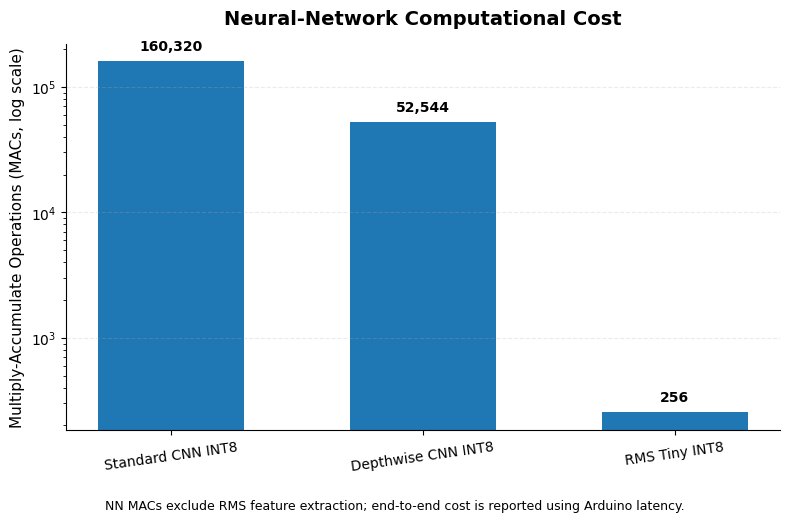

Saved: Figure/final_nn_mac_comparison.png

RMS Tiny NN MAC reduction vs Standard CNN: 99.84%
RMS Tiny NN MAC reduction vs Depthwise CNN: 99.51%


In [59]:
# ============================================================
# FINAL FIGURE — NEURAL-NETWORK COMPUTATIONAL COST
#
# Compare NN MAC counts of the three final INT8 architectures:
#
#   - Standard CNN INT8
#   - Depthwise CNN INT8
#   - RMS Tiny INT8
#
# IMPORTANT:
#   - NN MACs include neural-network computation only.
#   - RMS feature-extraction cost is NOT included.
#   - End-to-end embedded computation is evaluated separately
#     using Arduino total processing latency.
# ============================================================


# ============================================================
# FINAL MODEL ORDER
# ============================================================

final_model_order = [
    "Standard CNN INT8",
    "Depthwise CNN INT8",
    "RMS Tiny INT8"
]


# ============================================================
# PREPARE DATA
# ============================================================

final_mac_df = (
    final_report_df
    .set_index("Model")
    .loc[
        final_model_order,
        ["NN MACs"]
    ]
    .reset_index()
    .copy()
)


# ============================================================
# VALIDATION
# ============================================================

assert final_mac_df["Model"].tolist() == (
    final_model_order
)


assert final_mac_df[
    "NN MACs"
].tolist() == [
    160320,
    52544,
    256
]


assert np.all(
    final_mac_df[
        "NN MACs"
    ] > 0
)


# ============================================================
# COMPUTE REDUCTIONS
# ============================================================

standard_macs = int(
    final_mac_df.loc[
        final_mac_df["Model"]
        == "Standard CNN INT8",
        "NN MACs"
    ].iloc[0]
)


depthwise_macs = int(
    final_mac_df.loc[
        final_mac_df["Model"]
        == "Depthwise CNN INT8",
        "NN MACs"
    ].iloc[0]
)


rms_macs = int(
    final_mac_df.loc[
        final_mac_df["Model"]
        == "RMS Tiny INT8",
        "NN MACs"
    ].iloc[0]
)


rms_mac_reduction_vs_standard = (
    100.0
    * (
        1.0
        - rms_macs
        / standard_macs
    )
)


rms_mac_reduction_vs_depthwise = (
    100.0
    * (
        1.0
        - rms_macs
        / depthwise_macs
    )
)


# ============================================================
# CREATE FIGURE DIRECTORY
# ============================================================

os.makedirs(
    "Figure",
    exist_ok=True
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)


bars = ax.bar(
    final_mac_df["Model"],
    final_mac_df["NN MACs"],
    width=0.58
)


# ============================================================
# LOG SCALE
#
# Required because RMS Tiny is several orders of magnitude
# smaller than the CNN architectures.
# ============================================================

ax.set_yscale(
    "log"
)


# ============================================================
# VALUE LABELS
# ============================================================

for bar, value in zip(
    bars,
    final_mac_df["NN MACs"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        float(value) * 1.15,

        f"{int(value):,}",

        ha="center",
        va="bottom",

        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# STYLE
# ============================================================

ax.set_title(
    "Neural-Network Computational Cost",
    fontsize=14,
    fontweight="bold",
    pad=14
)


ax.set_ylabel(
    "Multiply-Accumulate Operations (MACs, log scale)",
    fontsize=11
)


ax.set_xlabel(
    ""
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


ax.tick_params(
    axis="x",
    labelrotation=8
)


# ============================================================
# FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.01,
    "NN MACs exclude RMS feature extraction; "
    "end-to-end cost is reported using Arduino latency.",
    ha="center",
    fontsize=9
)


fig.tight_layout(
    rect=[
        0,
        0.05,
        1,
        1
    ]
)


# ============================================================
# SAVE FINAL FIGURE
# ============================================================

figure_path = (
    "Figure/final_nn_mac_comparison.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# SUMMARY
# ============================================================

print(
    f"Saved: {figure_path}"
)


print(
    "\nRMS Tiny NN MAC reduction vs Standard CNN:",
    f"{rms_mac_reduction_vs_standard:.2f}%"
)


print(
    "RMS Tiny NN MAC reduction vs Depthwise CNN:",
    f"{rms_mac_reduction_vs_depthwise:.2f}%"
)

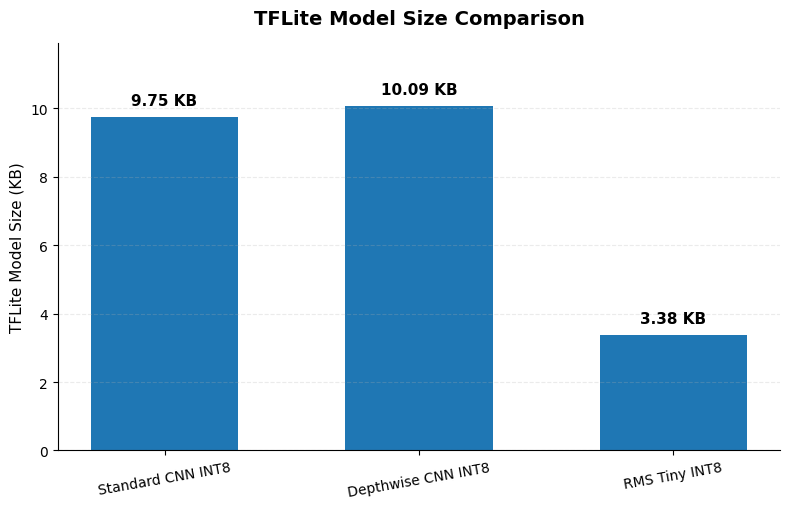

Saved: Figure/final_tflite_model_size.png


In [60]:
# ============================================================
# FINAL FIGURE — TFLITE MODEL SIZE
#
# Compare deployment model size for the three final
# INT8 TinyML architectures.
# ============================================================


# ============================================================
# PREPARE DATA
# ============================================================

final_size_df = final_report_df[
    [
        "Model",
        "TFLite Size (KB)"
    ]
].copy()


# ============================================================
# CREATE FIGURE DIRECTORY
# ============================================================

os.makedirs(
    "Figure",
    exist_ok=True
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)


bars = ax.bar(
    final_size_df["Model"],
    final_size_df["TFLite Size (KB)"],
    width=0.58
)


# ============================================================
# VALUE LABELS
# ============================================================

max_size = final_size_df[
    "TFLite Size (KB)"
].max()


for bar, value in zip(
    bars,
    final_size_df["TFLite Size (KB)"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + max_size * 0.025,

        f"{value:.2f} KB",

        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# STYLE
# ============================================================

ax.set_title(
    "TFLite Model Size Comparison",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_ylabel(
    "TFLite Model Size (KB)",
    fontsize=11
)

ax.set_xlabel(
    ""
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_ylim(
    0,
    max_size * 1.18
)

plt.xticks(
    rotation=10
)


plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

figure_path = (
    "Figure/final_tflite_model_size.png"
)


plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved: {figure_path}"
)

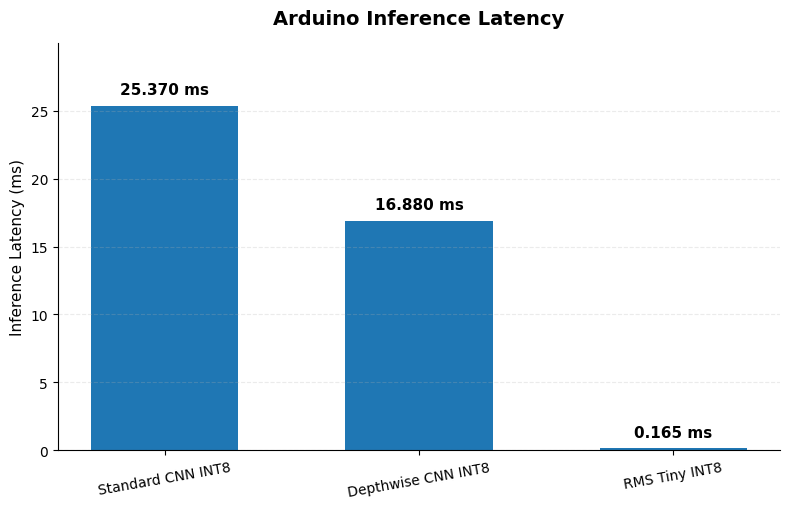

Saved: Figure/final_arduino_inference_latency.png


In [61]:
# ============================================================
# FINAL FIGURE — ARDUINO INFERENCE LATENCY
#
# Compare measured neural-network inference latency
# on the Arduino Nano 33 BLE.
#
# Models:
#   - Standard CNN INT8
#   - Depthwise CNN INT8
#   - RMS Tiny INT8
# ============================================================


# ============================================================
# PREPARE DATA
# ============================================================

arduino_inference_df = final_report_df[
    [
        "Model",
        "Arduino Inference (ms)"
    ]
].copy()


# ============================================================
# CREATE FIGURE DIRECTORY
# ============================================================

os.makedirs(
    "Figure",
    exist_ok=True
)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)


bars = ax.bar(
    arduino_inference_df["Model"],
    arduino_inference_df["Arduino Inference (ms)"],
    width=0.58
)


# ============================================================
# VALUE LABELS
# ============================================================

max_latency = arduino_inference_df[
    "Arduino Inference (ms)"
].max()


for bar, value in zip(
    bars,
    arduino_inference_df[
        "Arduino Inference (ms)"
    ]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + max_latency * 0.025,

        f"{value:.3f} ms",

        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# STYLE
# ============================================================

ax.set_title(
    "Arduino Inference Latency",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.set_ylabel(
    "Inference Latency (ms)",
    fontsize=11
)

ax.set_xlabel(
    ""
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_ylim(
    0,
    max_latency * 1.18
)

plt.xticks(
    rotation=10
)


plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

figure_path = (
    "Figure/final_arduino_inference_latency.png"
)


plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved: {figure_path}"
)

In [62]:
# ============================================================
# STUDY 2 — CONTROLLED FEATURE ENGINEERING COMPARISON
#
# Research question:
#   Does feature extraction still provide value in TinyML?
#
# Controlled representations:
#   - Raw Signal
#   - RMS
#   - FFT
#   - Spectral
#
# IMPORTANT:
#   All representations use the SAME hidden classifier:
#
#   Input → Dense(64) → Dense(32) → Dense(4)
#
# The input dimensionality changes across representations,
# therefore the total parameter count also changes.
# ============================================================


# ============================================================
# DISPLAY NAMES
# ============================================================

study2_display_names = {

    "raw":
        "Raw Signal",

    "rms":
        "RMS",

    "fft":
        "FFT",

    "spectral":
        "Spectral"
}


# ============================================================
# BUILD CONTROLLED COMPARISON TABLE
# ============================================================

study2_feature_rows = []


for mode in REPRESENTATION_MODES:

    # --------------------------------------------------------
    # Actual feature count from prepared dataset
    # --------------------------------------------------------

    input_features = int(
        prepared_data[
            mode
        ][
            "X_train"
        ].shape[1]
    )


    # --------------------------------------------------------
    # Build result row
    # --------------------------------------------------------

    study2_feature_rows.append({

        "Representation":
            study2_display_names[
                mode
            ],

        "Input Features":
            input_features,

        "Classifier":
            "Dense 64-32",

        "Parameters":
            int(
                models[
                    mode
                ].count_params()
            ),

        "Test Accuracy (%)":
            100.0
            * float(
                test_results[
                    mode
                ][
                    "test_accuracy"
                ]
            ),

        "Macro F1":
            float(
                test_results[
                    mode
                ][
                    "macro_f1"
                ]
            )
    })


# ============================================================
# CREATE DATAFRAME
# ============================================================

study2_feature_comparison_df = pd.DataFrame(
    study2_feature_rows
)


# ============================================================
# EXPECTED FEATURE COUNTS
# ============================================================

expected_feature_counts = {

    "Raw Signal":
        WINDOW_SIZE
        * NUM_CHANNELS,

    "RMS":
        NUM_CHANNELS,

    "FFT":
        NUM_CHANNELS
        * 8,

    "Spectral":
        NUM_CHANNELS
        * 2
}


# ============================================================
# VALIDATE FEATURE COUNTS
# ============================================================

for (
    representation,
    expected_count
) in expected_feature_counts.items():

    actual_count = int(
        study2_feature_comparison_df.loc[
            study2_feature_comparison_df[
                "Representation"
            ] == representation,
            "Input Features"
        ].iloc[0]
    )


    assert actual_count == expected_count, (
        f"{representation}: "
        f"expected {expected_count} features, "
        f"got {actual_count}"
    )


# ============================================================
# EXPECTED PARAMETER COUNTS
# ============================================================

expected_parameter_counts = {

    "Raw Signal":
        51428,

    "RMS":
        2660,

    "FFT":
        5348,

    "Spectral":
        3044
}


# ============================================================
# VALIDATE PARAMETER COUNTS
# ============================================================

for (
    representation,
    expected_params
) in expected_parameter_counts.items():

    actual_params = int(
        study2_feature_comparison_df.loc[
            study2_feature_comparison_df[
                "Representation"
            ] == representation,
            "Parameters"
        ].iloc[0]
    )


    assert actual_params == expected_params, (
        f"{representation}: "
        f"expected {expected_params:,} parameters, "
        f"got {actual_params:,}"
    )


# ============================================================
# GENERAL VALIDATION
# ============================================================

assert len(
    study2_feature_comparison_df
) == 4


assert study2_feature_comparison_df[
    "Representation"
].is_unique


assert np.isfinite(
    study2_feature_comparison_df[
        [
            "Input Features",
            "Parameters",
            "Test Accuracy (%)",
            "Macro F1"
        ]
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# CLEAN DISPLAY
# ============================================================

display(
    study2_feature_comparison_df.style
    .format({

        "Input Features":
            "{:,}",

        "Parameters":
            "{:,}",

        "Test Accuracy (%)":
            "{:.3f}",

        "Macro F1":
            "{:.4f}"
    })
    .hide(
        axis="index"
    )
)


print(
    "\nStudy 2 controlled feature-engineering "
    "comparison completed."
)

Representation,Input Features,Classifier,Parameters,Test Accuracy (%),Macro F1
Raw Signal,768,Dense 64-32,"51,428",100.000,1.0000
RMS,6,Dense 64-32,"2,660",100.000,1.0000
FFT,48,Dense 64-32,"5,348",100.000,1.0000
Spectral,12,Dense 64-32,"3,044",96.875,0.9686



Study 2 controlled feature-engineering comparison completed.


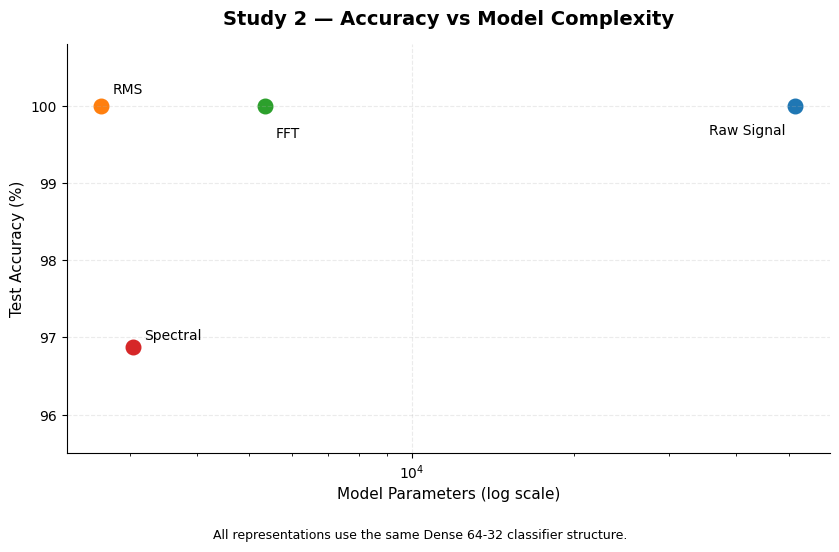

Saved: Figure/study2_accuracy_vs_parameters.png


In [63]:
# ============================================================
# STUDY 2 — ACCURACY VS MODEL COMPLEXITY
#
# Controlled feature-engineering comparison:
#
#   Raw Signal
#   RMS
#   FFT
#   Spectral
#
# All representations use the SAME hidden classifier:
#
#   Input -> Dense(64) -> Dense(32) -> Dense(4)
#
# The x-axis is logarithmic because parameter counts differ
# substantially across representations.
# ============================================================


# ============================================================
# PREPARE DATA
# ============================================================

study2_accuracy_params_df = (
    study2_feature_comparison_df[
        [
            "Representation",
            "Parameters",
            "Test Accuracy (%)"
        ]
    ]
    .copy()
)


# ============================================================
# VALIDATION
# ============================================================

expected_representations = [
    "Raw Signal",
    "RMS",
    "FFT",
    "Spectral"
]


assert study2_accuracy_params_df[
    "Representation"
].tolist() == expected_representations


assert np.all(
    study2_accuracy_params_df[
        "Parameters"
    ] > 0
)


assert np.isfinite(
    study2_accuracy_params_df[
        [
            "Parameters",
            "Test Accuracy (%)"
        ]
    ].to_numpy(
        dtype=np.float64
    )
).all()


# ============================================================
# CREATE FIGURE DIRECTORY
# ============================================================

os.makedirs(
    "Figure",
    exist_ok=True
)


# ============================================================
# LABEL OFFSETS
#
# Three representations achieve 100% accuracy, so custom
# offsets prevent annotation overlap.
# ============================================================

label_offsets = {

    "Raw Signal":
        (-62, -18),

    "RMS":
        (8, 12),

    "FFT":
        (8, -20),

    "Spectral":
        (8, 8)
}


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


# ============================================================
# SCATTER POINTS
# ============================================================

for _, row in study2_accuracy_params_df.iterrows():

    representation = row[
        "Representation"
    ]

    parameters = row[
        "Parameters"
    ]

    accuracy = row[
        "Test Accuracy (%)"
    ]


    ax.scatter(
        parameters,
        accuracy,
        s=110
    )


    ax.annotate(

        representation,

        (
            parameters,
            accuracy
        ),

        xytext=label_offsets[
            representation
        ],

        textcoords="offset points",

        fontsize=10,

        va="center"
    )


# ============================================================
# LOGARITHMIC PARAMETER AXIS
# ============================================================

ax.set_xscale(
    "log"
)


# ============================================================
# STYLE
# ============================================================

ax.set_title(
    "Study 2 — Accuracy vs Model Complexity",
    fontsize=14,
    fontweight="bold",
    pad=14
)


ax.set_xlabel(
    "Model Parameters (log scale)",
    fontsize=11
)


ax.set_ylabel(
    "Test Accuracy (%)",
    fontsize=11
)


ax.set_ylim(
    95.5,
    100.8
)


ax.grid(
    alpha=0.25,
    linestyle="--"
)


ax.spines[
    "top"
].set_visible(
    False
)


ax.spines[
    "right"
].set_visible(
    False
)


# ============================================================
# FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.01,
    "All representations use the same Dense 64-32 classifier structure.",
    ha="center",
    fontsize=9
)


fig.tight_layout(
    rect=[
        0,
        0.05,
        1,
        1
    ]
)


# ============================================================
# SAVE FIGURE
# ============================================================

figure_path = (
    "Figure/study2_accuracy_vs_parameters.png"
)


fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Saved: {figure_path}"
)

In [64]:
# ============================================================
# EXPORT RMS TINY INT8 MODEL AS C/C++ HEADER
#
# Output:
#   rms_tiny_model.h
#
# This header contains the final fully quantized INT8
# TensorFlow Lite model for Arduino Nano 33 BLE deployment.
# ============================================================


# ============================================================
# MODEL BYTES
# ============================================================

model_bytes = rms_tiny_int8_tflite


# ============================================================
# VALIDATION
# ============================================================

assert isinstance(
    model_bytes,
    (bytes, bytearray)
)


assert len(
    model_bytes
) > 0


# TensorFlow Lite FlatBuffer identifier
assert model_bytes[4:8] == b"TFL3", (
    "The model does not appear to be a valid "
    "TensorFlow Lite FlatBuffer."
)


# Must match the previously measured INT8 model size
assert len(
    model_bytes
) == rms_tiny_int8_results[
    "tflite_size_bytes"
]


# ============================================================
# OUTPUT FILE
# ============================================================

model_header_path = (
    "rms_tiny_model.h"
)


# ============================================================
# WRITE C/C++ HEADER
# ============================================================

with open(
    model_header_path,
    "w"
) as f:

    # --------------------------------------------------------
    # Header guard
    # --------------------------------------------------------

    f.write(
        "#ifndef RMS_TINY_MODEL_H\n"
    )

    f.write(
        "#define RMS_TINY_MODEL_H\n\n"
    )


    # --------------------------------------------------------
    # 16-byte aligned TFLite model array
    #
    # Alignment is useful for TensorFlow Lite Micro.
    # --------------------------------------------------------

    f.write(
        "alignas(16) const unsigned char "
        "rms_tiny_model[] = {\n"
    )


    # --------------------------------------------------------
    # Model bytes
    # --------------------------------------------------------

    for i, byte in enumerate(
        model_bytes
    ):

        if i % 12 == 0:

            f.write(
                "    "
            )


        f.write(
            f"0x{byte:02x}"
        )


        if i != len(
            model_bytes
        ) - 1:

            f.write(
                ", "
            )


        if (
            i + 1
        ) % 12 == 0:

            f.write(
                "\n"
            )


    # Final newline if last row has fewer than 12 bytes
    if len(
        model_bytes
    ) % 12 != 0:

        f.write(
            "\n"
        )


    f.write(
        "};\n\n"
    )


    # --------------------------------------------------------
    # Model length
    # --------------------------------------------------------

    f.write(
        "const unsigned int "
        "rms_tiny_model_len = "
        f"{len(model_bytes)};\n\n"
    )


    # --------------------------------------------------------
    # End header guard
    # --------------------------------------------------------

    f.write(
        "#endif  // RMS_TINY_MODEL_H\n"
    )


# ============================================================
# VERIFY EXPORTED FILE
# ============================================================

assert os.path.exists(
    model_header_path
)


assert os.path.getsize(
    model_header_path
) > 0


# ============================================================
# SUMMARY
# ============================================================

print(
    f"Created: {model_header_path}"
)


print(
    "TFLite model bytes:",
    f"{len(model_bytes):,}"
)


print(
    "TFLite model size:",
    f"{len(model_bytes) / 1024.0:.3f} KB"
)


print(
    "RMS Tiny INT8 model header exported successfully."
)

Created: rms_tiny_model.h
TFLite model bytes: 3,464
TFLite model size: 3.383 KB
RMS Tiny INT8 model header exported successfully.


In [66]:
# ============================================================
# EXPORT DEPTHWISE CNN INT8 MODEL AS C/C++ HEADER
#
# Output:
#   depthwise_cnn_model.h
#
# Target:
#   Arduino Nano 33 BLE / TensorFlow Lite Micro
# ============================================================


# ============================================================
# MODEL BYTES
# ============================================================

depthwise_cnn_model_bytes = (
    depthwise_cnn_int8_tflite
)


# ============================================================
# VALIDATION
# ============================================================

assert isinstance(
    depthwise_cnn_model_bytes,
    (bytes, bytearray)
)


assert len(
    depthwise_cnn_model_bytes
) > 0


# TensorFlow Lite FlatBuffer validation
assert depthwise_cnn_model_bytes[4:8] == b"TFL3", (
    "The model does not appear to be a valid "
    "TensorFlow Lite FlatBuffer."
)


# ============================================================
# OUTPUT FILE
# ============================================================

depthwise_model_header_path = (
    "depthwise_cnn_model.h"
)


# ============================================================
# WRITE C/C++ HEADER
# ============================================================

with open(
    depthwise_model_header_path,
    "w"
) as f:

    # --------------------------------------------------------
    # Header guard
    # --------------------------------------------------------

    f.write(
        "#ifndef DEPTHWISE_CNN_MODEL_H\n"
    )

    f.write(
        "#define DEPTHWISE_CNN_MODEL_H\n\n"
    )


    # --------------------------------------------------------
    # 16-byte aligned model array
    #
    # Required for TensorFlow Lite Micro deployment
    # --------------------------------------------------------

    f.write(
        "alignas(16) const unsigned char "
        "depthwise_cnn_model[] = {\n"
    )


    # --------------------------------------------------------
    # Write model bytes
    # --------------------------------------------------------

    for i, byte in enumerate(
        depthwise_cnn_model_bytes
    ):

        if i % 12 == 0:

            f.write(
                "    "
            )


        f.write(
            f"0x{byte:02x}"
        )


        if i != (
            len(
                depthwise_cnn_model_bytes
            ) - 1
        ):

            f.write(
                ", "
            )


        if (i + 1) % 12 == 0:

            f.write(
                "\n"
            )


    # Final newline
    if (
        len(
            depthwise_cnn_model_bytes
        ) % 12
        != 0
    ):

        f.write(
            "\n"
        )


    f.write(
        "};\n\n"
    )


    # --------------------------------------------------------
    # Model length
    # --------------------------------------------------------

    f.write(
        "const unsigned int "
        "depthwise_cnn_model_len = "
        f"{len(depthwise_cnn_model_bytes)};\n\n"
    )


    # --------------------------------------------------------
    # End header guard
    # --------------------------------------------------------

    f.write(
        "#endif  // DEPTHWISE_CNN_MODEL_H\n"
    )


# ============================================================
# VERIFY EXPORTED FILE
# ============================================================

assert os.path.exists(
    depthwise_model_header_path
)


assert os.path.getsize(
    depthwise_model_header_path
) > 0


# ============================================================
# SUMMARY
# ============================================================

print(
    f"Created: {depthwise_model_header_path}"
)


print(
    "Model size:",
    f"{len(depthwise_cnn_model_bytes):,}",
    "bytes"
)


print(
    "Model size:",
    f"{len(depthwise_cnn_model_bytes) / 1024:.3f}",
    "KB"
)


print(
    "Depthwise CNN INT8 model header exported successfully."
)

Created: depthwise_cnn_model.h
Model size: 10,328 bytes
Model size: 10.086 KB
Depthwise CNN INT8 model header exported successfully.


In [67]:
# ============================================================
# DEPTHWISE CNN INT8 — TFLITE OPERATOR INSPECTION
#
# Purpose:
#   Inspect the operators used by the final INT8 TFLite model.
#
# This information is useful when configuring the
# TensorFlow Lite Micro operator resolver on Arduino.
# ============================================================


# ============================================================
# MODEL VALIDATION
# ============================================================

assert isinstance(
    depthwise_cnn_int8_tflite,
    (bytes, bytearray)
)


assert len(
    depthwise_cnn_int8_tflite
) > 0


# TensorFlow Lite FlatBuffer validation
assert depthwise_cnn_int8_tflite[4:8] == b"TFL3", (
    "The model does not appear to be a valid "
    "TensorFlow Lite FlatBuffer."
)


# ============================================================
# CREATE INTERPRETER
# ============================================================

depthwise_ops_interpreter = tf.lite.Interpreter(
    model_content=depthwise_cnn_int8_tflite
)


depthwise_ops_interpreter.allocate_tensors()


# ============================================================
# EXTRACT OPERATOR DETAILS
#
# NOTE:
#   _get_ops_details() is an internal TensorFlow Lite
#   diagnostic API. It is used here only for model inspection.
# ============================================================

depthwise_ops_details = (
    depthwise_ops_interpreter._get_ops_details()
)


# ============================================================
# VALIDATE OPERATOR EXTRACTION
# ============================================================

assert len(
    depthwise_ops_details
) > 0


# ============================================================
# BUILD CLEAN OPERATOR TABLE
# ============================================================

depthwise_operator_rows = []


for node_index, op in enumerate(
    depthwise_ops_details
):

    depthwise_operator_rows.append({

        "Node":
            node_index,

        "Operator":
            op["op_name"]
    })


depthwise_operators_df = pd.DataFrame(
    depthwise_operator_rows
)


# ============================================================
# UNIQUE OPERATORS
# ============================================================

depthwise_unique_operators = list(
    dict.fromkeys(
        depthwise_operators_df[
            "Operator"
        ].tolist()
    )
)


depthwise_unique_operators_df = pd.DataFrame({

    "Operator":
        depthwise_unique_operators
})


# ============================================================
# DISPLAY ALL OPERATOR NODES
# ============================================================

print(
    "DEPTHWISE CNN INT8 — TFLITE OPERATOR NODES"
)


display(
    depthwise_operators_df.style
    .hide(axis="index")
)


# ============================================================
# DISPLAY UNIQUE OPERATOR TYPES
# ============================================================

print(
    "\nUNIQUE TFLITE OPERATORS"
)


display(
    depthwise_unique_operators_df.style
    .hide(axis="index")
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\nTotal operator nodes:",
    len(depthwise_ops_details)
)


print(
    "Unique operator types:",
    len(depthwise_unique_operators)
)


print(
    "\nDepthwise CNN INT8 operator inspection completed."
)

DEPTHWISE CNN INT8 — TFLITE OPERATOR NODES


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Node,Operator
0,EXPAND_DIMS
1,DEPTHWISE_CONV_2D
2,CONV_2D
3,RESHAPE
4,EXPAND_DIMS
5,MAX_POOL_2D
6,RESHAPE
7,EXPAND_DIMS
8,DEPTHWISE_CONV_2D
9,CONV_2D



UNIQUE TFLITE OPERATORS


Operator
EXPAND_DIMS
DEPTHWISE_CONV_2D
CONV_2D
RESHAPE
MAX_POOL_2D
MEAN
FULLY_CONNECTED
SOFTMAX
DELEGATE



Total operator nodes: 18
Unique operator types: 9

Depthwise CNN INT8 operator inspection completed.


In [68]:
# ============================================================
# EXPORT DEPTHWISE CNN RAW-INPUT NORMALIZATION
# AS C/C++ HEADER
#
# Output:
#   depthwise_cnn_scaler.h
#
# Python preprocessing:
#
#   x_normalized = (x - raw_mean) / raw_std
#
# IMPORTANT:
#   raw_mean and raw_std were computed ONLY from the
#   main 80/10/10 training split.
# ============================================================


# ============================================================
# USE THE EXACT TRAINING NORMALIZATION PARAMETERS
# ============================================================

depthwise_raw_mean = np.asarray(
    raw_mean,
    dtype=np.float32
).reshape(-1)


depthwise_raw_std = np.asarray(
    raw_std,
    dtype=np.float32
).reshape(-1)


# ============================================================
# VALIDATION
# ============================================================

assert depthwise_raw_mean.shape == (
    NUM_CHANNELS,
)

assert depthwise_raw_std.shape == (
    NUM_CHANNELS,
)

assert NUM_CHANNELS == 6

assert np.isfinite(
    depthwise_raw_mean
).all()

assert np.isfinite(
    depthwise_raw_std
).all()

assert np.all(
    depthwise_raw_std > 0
)


# ============================================================
# OUTPUT FILE
# ============================================================

depthwise_scaler_header_path = (
    "depthwise_cnn_scaler.h"
)


# ============================================================
# WRITE C/C++ HEADER
# ============================================================

with open(
    depthwise_scaler_header_path,
    "w"
) as f:

    # --------------------------------------------------------
    # Header guard
    # --------------------------------------------------------

    f.write(
        "#ifndef DEPTHWISE_CNN_SCALER_H\n"
    )

    f.write(
        "#define DEPTHWISE_CNN_SCALER_H\n\n"
    )


    # --------------------------------------------------------
    # Documentation
    # --------------------------------------------------------

    f.write(
        "// Raw IMU normalization parameters\n"
    )

    f.write(
        "// Channel order: aX, aY, aZ, gX, gY, gZ\n"
    )

    f.write(
        "// x_normalized = (x - mean) / std\n\n"
    )


    # --------------------------------------------------------
    # Number of channels
    # --------------------------------------------------------

    f.write(
        "const unsigned int "
        "depthwise_input_channels = "
        f"{NUM_CHANNELS};\n\n"
    )


    # --------------------------------------------------------
    # Mean
    # --------------------------------------------------------

    f.write(
        "const float "
        f"depthwise_raw_mean[{NUM_CHANNELS}] = {{\n"
    )


    for i, value in enumerate(
        depthwise_raw_mean
    ):

        comma = (
            ","
            if i < NUM_CHANNELS - 1
            else ""
        )

        f.write(
            f"    {value:.10e}f{comma}\n"
        )


    f.write(
        "};\n\n"
    )


    # --------------------------------------------------------
    # Standard deviation
    # --------------------------------------------------------

    f.write(
        "const float "
        f"depthwise_raw_std[{NUM_CHANNELS}] = {{\n"
    )


    for i, value in enumerate(
        depthwise_raw_std
    ):

        comma = (
            ","
            if i < NUM_CHANNELS - 1
            else ""
        )

        f.write(
            f"    {value:.10e}f{comma}\n"
        )


    f.write(
        "};\n\n"
    )


    # --------------------------------------------------------
    # End header guard
    # --------------------------------------------------------

    f.write(
        "#endif  // DEPTHWISE_CNN_SCALER_H\n"
    )


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

depthwise_scaler_export_df = pd.DataFrame({

    "Channel": [
        "aX",
        "aY",
        "aZ",
        "gX",
        "gY",
        "gZ"
    ],

    "Training Mean":
        depthwise_raw_mean,

    "Training Std":
        depthwise_raw_std
})


display(
    depthwise_scaler_export_df.style
    .format({
        "Training Mean": "{:.8f}",
        "Training Std": "{:.8f}"
    })
    .hide(axis="index")
)


print(
    f"\nCreated: {depthwise_scaler_header_path}"
)

print(
    f"Channels: {NUM_CHANNELS}"
)

Channel,Training Mean,Training Std
aX,0.00112080,0.26098123
aY,-0.08265268,0.60880870
aZ,-0.12643255,0.74689877
gX,-1.57340860,19.05392456
gY,0.15375391,17.84091949
gZ,0.29320991,56.50803757



Created: depthwise_cnn_scaler.h
Channels: 6


In [69]:
# ============================================================
# FINAL PROJECT SUMMARY
#
# Compact summary of the final selected TinyML model
# ============================================================


# ============================================================
# ENSURE MAC COUNT EXISTS
# ============================================================

rms_tiny_final_macs = estimate_macs(
    rms_tiny_fp32
)


# ============================================================
# BUILD SUMMARY DICTIONARY
# ============================================================

final_project_summary = {

    "Project":
        "TinyML IMU Classification",

    "Selected Model":
        "RMS Tiny INT8",

    "Input Representation":
        "6 RMS IMU Features",

    "Input Features":
        6,

    "Classes":
        len(CLASS_NAMES),

    "Architecture":
        "Dense(16) → Dense(8) → Softmax(4)",

    "Parameters":
        int(
            rms_tiny_fp32.count_params()
        ),

    "NN MACs":
        int(
            rms_tiny_final_macs
        ),

    "TFLite Size (KB)":
        float(
            rms_tiny_int8_results[
                "tflite_size_kb"
            ]
        ),

    "Offline Accuracy (%)":
        100 * float(
            rms_tiny_int8_results[
                "test_accuracy"
            ]
        ),

    "Macro F1":
        float(
            rms_tiny_int8_results[
                "macro_f1"
            ]
        ),

    "Arduino Inference (ms)":
        float(
            final_report_df.loc[
                final_report_df["Model"]
                ==
                "RMS Tiny INT8",
                "Arduino Inference (ms)"
            ].iloc[0]
        ),

    "Total Processing (ms)":
        float(
            final_report_df.loc[
                final_report_df["Model"]
                ==
                "RMS Tiny INT8",
                "Total Processing (ms)"
            ].iloc[0]
        )
}


# ============================================================
# DISPLAY SUMMARY
# ============================================================

final_project_summary_df = pd.DataFrame({

    "Metric":
        list(
            final_project_summary.keys()
        ),

    "Value":
        list(
            final_project_summary.values()
        )
})


display(
    final_project_summary_df.style
    .hide(axis="index")
)


print(
    "\nFinal project summary generated successfully."
)

Metric,Value
Project,TinyML IMU Classification
Selected Model,RMS Tiny INT8
Input Representation,6 RMS IMU Features
Input Features,6
Classes,4
Architecture,Dense(16) → Dense(8) → Softmax(4)
Parameters,284
NN MACs,256
TFLite Size (KB),3.382812
Offline Accuracy (%),100.000000



Final project summary generated successfully.


In [70]:
# ============================================================
# SAVE FINAL SUMMARY RESULTS
#
# Output:
#   Results/final_summary.csv
# ============================================================


# ============================================================
# CREATE RESULTS DIRECTORY
# ============================================================

os.makedirs(
    "Results",
    exist_ok=True
)


# ============================================================
# SAVE CSV
# ============================================================

final_summary_csv_path = (
    "Results/final_summary.csv"
)


final_project_summary_df.to_csv(
    final_summary_csv_path,
    index=False
)


print(
    f"Saved: {final_summary_csv_path}"
)


# ============================================================
# SAVE FINAL REPORT TABLE ALSO
# ============================================================

final_report_copy_path = (
    "Results/final_report_table.csv"
)


final_report_df.to_csv(
    final_report_copy_path,
    index=False
)


print(
    f"Saved: {final_report_copy_path}"
)

Saved: Results/final_summary.csv
Saved: Results/final_report_table.csv
